In [2]:
# 画素数を指定して、CLS / AVG / mixed を選択して特徴ベクトルを抽出
# 原本の2セル目は変更せず、抽出モードを切り替えられる版

import os
from pathlib import Path

import torch
from PIL import Image
import timm
from timm.data import resolve_data_config, create_transform

# =========================
# 設定
# =========================
MODEL_NAMES = [
    #"eva02_large_patch14_448.mim_in22k_ft_in22k_in1k",
    #"eva02_large_patch14_448.mim_in22k_ft_in22k",
    "vit_large_patch16_384.augreg_in21k_ft_in1k",
    #"vit_intern300m_patch14_448.ogvl_2pt5",
]

INPUT_FOLDER = Path("/home/tatsushi/デスクトップ/sensitivity_data7/image_aug")
OUTPUT_ROOT = Path("/home/tatsushi/デスクトップ/sensitivity_data7/image_feature")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VALID_EXT = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".webp"}

# =========================
# 画像パス列挙（1回だけ）
# =========================
def list_images_once(input_dir: Path):
    image_paths = []
    for root, _, files in os.walk(input_dir):
        root = Path(root)
        for fname in files:
            if Path(fname).suffix.lower() in VALID_EXT:
                image_paths.append(root / fname)
    image_paths.sort()
    return image_paths

# =========================
# ユーティリティ
# =========================
def clean_model_name(name: str) -> str:
    return name.strip().rstrip("#").strip()

def normalize_feature_mode(mode: str) -> str:
    mode = mode.strip().lower()
    aliases = {
        "c": "cls",
        "class": "cls",
        "gap": "avg",
        "average": "avg",
        "mean": "avg",
        "mix": "mixed",
        "concat": "mixed",
        "cls+avg": "mixed",
    }
    mode = aliases.get(mode, mode)
    if mode not in {"cls", "avg", "mixed"}:
        raise ValueError("feature_mode は cls / avg / mixed のいずれかを指定してください")
    return mode

def unpack_features(feats):
    if isinstance(feats, (tuple, list)):
        feats = feats[-1]
    if isinstance(feats, dict):
        for key in ("x", "features", "last_hidden_state"):
            if key in feats:
                return feats[key]
        return next(reversed(feats.values()))
    return feats

def extract_cls_avg(model, x):
    if hasattr(model, "forward_features"):
        feats = unpack_features(model.forward_features(x))
    else:
        feats = model(x)

    if feats.ndim == 3:
        cls_feat = feats[:, 0]
        avg_feat = feats[:, 1:].mean(dim=1) if feats.shape[1] > 1 else feats.mean(dim=1)
    elif feats.ndim == 4:
        avg_feat = feats.mean(dim=(2, 3))
        cls_feat = avg_feat
    elif feats.ndim == 2:
        cls_feat = feats
        avg_feat = feats
    else:
        flat = feats.flatten(1)
        cls_feat = flat
        avg_feat = flat

    return cls_feat, avg_feat

def extract_feature(model, x, feature_mode: str):
    cls_feat, avg_feat = extract_cls_avg(model, x)
    if feature_mode == "cls":
        return cls_feat
    if feature_mode == "avg":
        return avg_feat
    return torch.cat([cls_feat, avg_feat], dim=1)

# =========================
# main
# =========================
def main():
    s = input("img_size を入力してください（例: 384 / 448 / 600 / 1200）> ").strip()
    img_size = int(s) if s else 616

    mode_s = input("feature_mode を入力してください（cls / avg / mixed）> ").strip()
    feature_mode = normalize_feature_mode(mode_s or "mixed")

    print(f"Using img_size = {img_size}")
    print(f"Using feature_mode = {feature_mode}")

    image_paths = list_images_once(INPUT_FOLDER)
    print(f"Found {len(image_paths)} images under: {INPUT_FOLDER}")

    out_root = OUTPUT_ROOT / f"{feature_mode}_{img_size}px"
    out_root.mkdir(parents=True, exist_ok=True)

    for raw_name in MODEL_NAMES:
        model_name = clean_model_name(raw_name)
        print(f"\n=== Model: {model_name} ===")

        model = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            img_size=img_size,
        )
        model.to(DEVICE).eval()
        for p in model.parameters():
            p.requires_grad = False

        data_cfg = resolve_data_config(
            {"input_size": (3, img_size, img_size)},
            model=model,
        )
        transform = create_transform(**data_cfg)

        out_model_root = out_root / model_name
        out_model_root.mkdir(parents=True, exist_ok=True)

        with torch.inference_mode():
            for in_path in image_paths:
                rel_dir = in_path.parent.relative_to(INPUT_FOLDER)
                out_dir = out_model_root / rel_dir
                out_dir.mkdir(parents=True, exist_ok=True)
                out_path = out_dir / f"{in_path.stem}_feature.pt"
                if out_path.exists():
                    continue

                try:
                    img = Image.open(in_path).convert("RGB")
                except Exception as e:
                    print(f"[SKIP] Failed to open: {in_path} ({e})")
                    continue

                x = transform(img).unsqueeze(0).to(DEVICE)
                feat = extract_feature(model, x, feature_mode).squeeze(0).contiguous().cpu()
                torch.save(feat, out_path)

        print(f"Saved features to: {out_model_root}")

    print("\nDone.")

if __name__ == "__main__":
    main()


Using img_size = 560
Using feature_mode = cls
Found 16556 images under: /home/tatsushi/デスクトップ/sensitivity_data7/image_aug

=== Model: vit_large_patch16_384.augreg_in21k_ft_in1k ===
Saved features to: /home/tatsushi/デスクトップ/sensitivity_data7/image_feature/cls_560px/vit_large_patch16_384.augreg_in21k_ft_in1k

Done.


In [2]:
# 画素数を指定して、CLS / AVG / mixed を選択して特徴ベクトルを抽出
# 原本の2セル目は変更せず、抽出モードを切り替えられる版

import os
from pathlib import Path

import torch
from PIL import Image
import timm
from timm.data import resolve_data_config, create_transform

# =========================
# 設定
# =========================
MODEL_NAMES = [
    #"eva02_large_patch14_448.mim_in22k_ft_in22k_in1k",
    #"eva02_large_patch14_448.mim_in22k_ft_in22k",
    "vit_large_patch16_384.augreg_in21k_ft_in1k",
    #"vit_intern300m_patch14_448.ogvl_2pt5",
]

INPUT_FOLDER = Path("/home/tatsushi/デスクトップ/2026_kakuho_加工/image_aug")
OUTPUT_ROOT = Path("/home/tatsushi/デスクトップ/2026_kakuho_加工/image_feature")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VALID_EXT = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".webp"}

# =========================
# 画像パス列挙（1回だけ）
# =========================
def list_images_once(input_dir: Path):
    image_paths = []
    for root, _, files in os.walk(input_dir):
        root = Path(root)
        for fname in files:
            if Path(fname).suffix.lower() in VALID_EXT:
                image_paths.append(root / fname)
    image_paths.sort()
    return image_paths

# =========================
# ユーティリティ
# =========================
def clean_model_name(name: str) -> str:
    return name.strip().rstrip("#").strip()

def normalize_feature_mode(mode: str) -> str:
    mode = mode.strip().lower()
    aliases = {
        "c": "cls",
        "class": "cls",
        "gap": "avg",
        "average": "avg",
        "mean": "avg",
        "mix": "mixed",
        "concat": "mixed",
        "cls+avg": "mixed",
    }
    mode = aliases.get(mode, mode)
    if mode not in {"cls", "avg", "mixed"}:
        raise ValueError("feature_mode は cls / avg / mixed のいずれかを指定してください")
    return mode

def unpack_features(feats):
    if isinstance(feats, (tuple, list)):
        feats = feats[-1]
    if isinstance(feats, dict):
        for key in ("x", "features", "last_hidden_state"):
            if key in feats:
                return feats[key]
        return next(reversed(feats.values()))
    return feats

def extract_cls_avg(model, x):
    if hasattr(model, "forward_features"):
        feats = unpack_features(model.forward_features(x))
    else:
        feats = model(x)

    if feats.ndim == 3:
        cls_feat = feats[:, 0]
        avg_feat = feats[:, 1:].mean(dim=1) if feats.shape[1] > 1 else feats.mean(dim=1)
    elif feats.ndim == 4:
        avg_feat = feats.mean(dim=(2, 3))
        cls_feat = avg_feat
    elif feats.ndim == 2:
        cls_feat = feats
        avg_feat = feats
    else:
        flat = feats.flatten(1)
        cls_feat = flat
        avg_feat = flat

    return cls_feat, avg_feat

def extract_feature(model, x, feature_mode: str):
    cls_feat, avg_feat = extract_cls_avg(model, x)
    if feature_mode == "cls":
        return cls_feat
    if feature_mode == "avg":
        return avg_feat
    return torch.cat([cls_feat, avg_feat], dim=1)

# =========================
# main
# =========================
def main():
    s = 384 ################################input("img_size を入力してください（例: 384 / 448 / 600 / 1200）> ").strip()
    img_size = int(s) if s else 616

    mode_s = "cls" ###############input("feature_mode を入力してください（cls / avg / mixed）> ").strip()
    feature_mode = normalize_feature_mode(mode_s or "mixed")

    print(f"Using img_size = {img_size}")
    print(f"Using feature_mode = {feature_mode}")

    image_paths = list_images_once(INPUT_FOLDER)
    print(f"Found {len(image_paths)} images under: {INPUT_FOLDER}")

    out_root = OUTPUT_ROOT / f"{feature_mode}_{img_size}px"
    out_root.mkdir(parents=True, exist_ok=True)

    for raw_name in MODEL_NAMES:
        model_name = clean_model_name(raw_name)
        print(f"\n=== Model: {model_name} ===")

        model = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            img_size=img_size,
        )
        model.to(DEVICE).eval()
        for p in model.parameters():
            p.requires_grad = False

        data_cfg = resolve_data_config(
            {"input_size": (3, img_size, img_size)},
            model=model,
        )
        transform = create_transform(**data_cfg)

        out_model_root = out_root / model_name
        out_model_root.mkdir(parents=True, exist_ok=True)

        with torch.inference_mode():
            for in_path in image_paths:
                rel_dir = in_path.parent.relative_to(INPUT_FOLDER)
                out_dir = out_model_root / rel_dir
                out_dir.mkdir(parents=True, exist_ok=True)
                out_path = out_dir / f"{in_path.stem}_feature.pt"
                if out_path.exists():
                    continue

                try:
                    img = Image.open(in_path).convert("RGB")
                except Exception as e:
                    print(f"[SKIP] Failed to open: {in_path} ({e})")
                    continue

                x = transform(img).unsqueeze(0).to(DEVICE)
                feat = extract_feature(model, x, feature_mode).squeeze(0).contiguous().cpu()
                torch.save(feat, out_path)

        print(f"Saved features to: {out_model_root}")

    print("\nDone.")

if __name__ == "__main__":
    main()


Using img_size = 384
Using feature_mode = cls
Found 200 images under: /home/tatsushi/デスクトップ/2026_kakuho_加工/image_aug

=== Model: vit_large_patch16_384.augreg_in21k_ft_in1k ===
Saved features to: /home/tatsushi/デスクトップ/2026_kakuho_加工/image_feature/cls_384px/vit_large_patch16_384.augreg_in21k_ft_in1k

Done.


In [4]:
# ファイル形式を確認

import torch
#Architecture = ["ViT", "EffNetV2", "ConvNeXtV2", "SwinV2", "CHIEF_docker", "300"]
# ([1, 1024]),([1, 1280]),([1, 1536]),([1, 1536]),([1, 768]),([1, 1024])
# 特徴ベクトルのファイルパス
feature_path = f"/home/tatsushi/デスクトップ/somekawa/aug-feature-test/cls_616px/vit_large_patch16_384.augreg_in21k_ft_in1k/559_1-2-somekawa-9/559_1-2-somekawa-9001_aug_001_feature.pt"

# 特徴ベクトルを読み込む
feature_vector = torch.load(feature_path)

# 内容を確認
print("データタイプ:", type(feature_vector))  # Tensorかどうか確認
print("形状:", feature_vector.shape)  # テンソルの形状
print("値の一部:", feature_vector[:5])  # 最初の5つの値を表示

データタイプ: <class 'torch.Tensor'>
形状: torch.Size([1024])
値の一部: tensor([-2.0437, -3.6607, -1.1638, -3.9558,  1.3913])


val .pt files          : 960
val case_ids           : 18
train candidate .pt    : 11964
train candidate cases  : 257
overlap case_ids       : 0
filtered train .pt     : 11964
filtered train case_ids: 257
SEED   1: best_epoch= 3, best_val_loss(epoch)=0.2682, best_val_acc(epoch)=0.9010, best_cutoff=0.40, val_acc=0.9083, recall_0_sens=0.8625, specificity_0_sens=0.9542, precision_0_sens=0.9495, f1_0_sens=0.9039, score=0.9039
SEED   2: best_epoch= 1, best_val_loss(epoch)=0.2515, best_val_acc(epoch)=0.8750, best_cutoff=0.75, val_acc=0.9240, recall_0_sens=0.8688, specificity_0_sens=0.9792, precision_0_sens=0.9766, f1_0_sens=0.9195, score=0.9195
SEED   3: best_epoch= 1, best_val_loss(epoch)=0.2636, best_val_acc(epoch)=0.8719, best_cutoff=0.80, val_acc=0.9229, recall_0_sens=0.9229, specificity_0_sens=0.9229, precision_0_sens=0.9229, f1_0_sens=0.9229, score=0.9229
SEED   4: best_epoch= 3, best_val_loss(epoch)=0.2574, best_val_acc(epoch)=0.9229, best_cutoff=0.40, val_acc=0.9260, recall_0_sens=0.9

,root,class_name,subfolder,case_id,n_images,true_label,true_class,mean_prob_0_sens,median_prob_0_sens,min_prob_0_sens,...,pred_label,pred_class,is_correct,n_tiles,n_pred_2_resis,n_pred_0_sens,ratio_pred_2_resis,ratio_pred_0_sens,tile_matrix_str,abs_margin
0,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,0_sens,202_1-0-Sato-0,0_sens/202_1-0-Sato-0,80,1,0_sens,0.582294,0.686169,1.217258e-02,...,1,0_sens,1,80,33,47,0.4125,0.5875,"[[0, 0], [33, 47]]",0.236169
1,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,309_1-2-Mitsui_bio-0,2_resis/309_1-2-Mitsui_bio-0,40,0,2_resis,0.292230,0.204169,6.122535e-04,...,0,2_resis,1,40,27,13,0.6750,0.3250,"[[27, 13], [0, 0]]",0.245831
2,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,440_1-2-Yotsui-0,2_resis/440_1-2-Yotsui-0,40,0,2_resis,0.229606,0.174259,9.942557e-05,...,0,2_resis,1,40,32,8,0.8000,0.2000,"[[32, 8], [0, 0]]",0.275741
3,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,0_sens,566_1-0-ootani-0,0_sens/566_1-0-ootani-0,80,1,0_sens,0.676608,0.732617,9.100841e-02,...,1,0_sens,1,80,19,61,0.2375,0.7625,"[[0, 0], [19, 61]]",0.282617
4,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,0_sens,566_2-0-ootani_CLS-0,0_sens/566_2-0-ootani_CLS-0,80,1,0_sens,0.662171,0.742630,2.575023e-02,...,1,0_sens,1,80,20,60,0.2500,0.7500,"[[0, 0], [20, 60]]",0.292630
5,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,560_1-2-tamura-0,2_resis/560_1-2-tamura-0,40,0,2_resis,0.209460,0.143804,1.797622e-03,...,0,2_resis,1,40,35,5,0.8750,0.1250,"[[35, 5], [0, 0]]",0.306196
6,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,309_1-2-Mitsui-0,2_resis/309_1-2-Mitsui-0,40,0,2_resis,0.193267,0.139943,5.315050e-03,...,0,2_resis,1,40,37,3,0.9250,0.0750,"[[37, 3], [0, 0]]",0.310057
7,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,0_sens,201_1-0-Fujikawa-0,0_sens/201_1-0-Fujikawa-0,80,1,0_sens,0.640403,0.777065,6.682105e-03,...,1,0_sens,1,80,25,55,0.3125,0.6875,"[[0, 0], [25, 55]]",0.327065
8,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,115_1-2-Shimizu-0,2_resis/115_1-2-Shimizu-0,40,0,2_resis,0.142632,0.100199,3.411707e-04,...,0,2_resis,1,40,40,0,1.0000,0.0000,"[[40, 0], [0, 0]]",0.349801
9,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,0_sens,329_1-0-Yamamoto-0,0_sens/329_1-0-Yamamoto-0,80,1,0_sens,0.745897,0.851292,4.595612e-02,...,1,0_sens,1,80,17,63,0.2125,0.7875,"[[0, 0], [17, 63]]",0.401292



===== tile distribution summary =====


,case_id,true_class,pred_class,n_tiles,n_pred_2_resis,n_pred_0_sens,used_prob_0_sens,cutoff,margin_from_cutoff,tile_matrix_str
0,0_sens/202_1-0-Sato-0,0_sens,0_sens,80,33,47,0.686169,0.45,0.236169,"[[0, 0], [33, 47]]"
1,2_resis/309_1-2-Mitsui_bio-0,2_resis,2_resis,40,27,13,0.204169,0.45,-0.245831,"[[27, 13], [0, 0]]"
2,2_resis/440_1-2-Yotsui-0,2_resis,2_resis,40,32,8,0.174259,0.45,-0.275741,"[[32, 8], [0, 0]]"
3,0_sens/566_1-0-ootani-0,0_sens,0_sens,80,19,61,0.732617,0.45,0.282617,"[[0, 0], [19, 61]]"
4,0_sens/566_2-0-ootani_CLS-0,0_sens,0_sens,80,20,60,0.742630,0.45,0.292630,"[[0, 0], [20, 60]]"
5,2_resis/560_1-2-tamura-0,2_resis,2_resis,40,35,5,0.143804,0.45,-0.306196,"[[35, 5], [0, 0]]"
6,2_resis/309_1-2-Mitsui-0,2_resis,2_resis,40,37,3,0.139943,0.45,-0.310057,"[[37, 3], [0, 0]]"
7,0_sens/201_1-0-Fujikawa-0,0_sens,0_sens,80,25,55,0.777065,0.45,0.327065,"[[0, 0], [25, 55]]"
8,2_resis/115_1-2-Shimizu-0,2_resis,2_resis,40,40,0,0.100199,0.45,-0.349801,"[[40, 0], [0, 0]]"
9,0_sens/329_1-0-Yamamoto-0,0_sens,0_sens,80,17,63,0.851292,0.45,0.401292,"[[0, 0], [17, 63]]"



===== lesion-level confusion matrix =====


,pred_2_resis,pred_0_sens
true_2_resis,17,0
true_0_sens,0,6


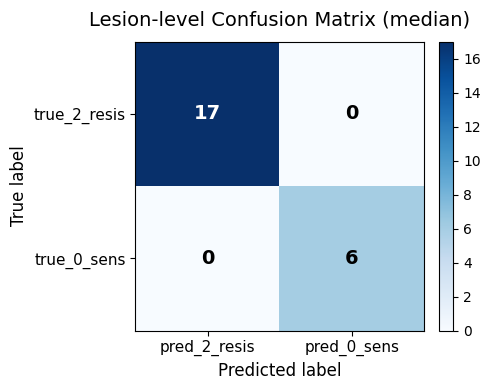

Lesion-level accuracy = 1.0000

===== classification report =====
              precision    recall  f1-score   support

     2_resis     1.0000    1.0000    1.0000        17
      0_sens     1.0000    1.0000    1.0000         6

    accuracy                         1.0000        23
   macro avg     1.0000    1.0000    1.0000        23
weighted avg     1.0000    1.0000    1.0000        23


===== wrong lesions =====


,root,class_name,subfolder,case_id,n_images,true_label,true_class,mean_prob_0_sens,median_prob_0_sens,min_prob_0_sens,...,pred_label,pred_class,is_correct,n_tiles,n_pred_2_resis,n_pred_0_sens,ratio_pred_2_resis,ratio_pred_0_sens,tile_matrix_str,abs_margin



===== borderline lesions =====


,case_id,true_class,pred_class,n_tiles,n_pred_2_resis,n_pred_0_sens,used_prob_0_sens,cutoff,margin_from_cutoff,tile_matrix_str
0,0_sens/202_1-0-Sato-0,0_sens,0_sens,80,33,47,0.686169,0.45,0.236169,"[[0, 0], [33, 47]]"
1,2_resis/309_1-2-Mitsui_bio-0,2_resis,2_resis,40,27,13,0.204169,0.45,-0.245831,"[[27, 13], [0, 0]]"
2,2_resis/440_1-2-Yotsui-0,2_resis,2_resis,40,32,8,0.174259,0.45,-0.275741,"[[32, 8], [0, 0]]"
3,0_sens/566_1-0-ootani-0,0_sens,0_sens,80,19,61,0.732617,0.45,0.282617,"[[0, 0], [19, 61]]"
4,0_sens/566_2-0-ootani_CLS-0,0_sens,0_sens,80,20,60,0.742630,0.45,0.292630,"[[0, 0], [20, 60]]"
5,2_resis/560_1-2-tamura-0,2_resis,2_resis,40,35,5,0.143804,0.45,-0.306196,"[[35, 5], [0, 0]]"
6,2_resis/309_1-2-Mitsui-0,2_resis,2_resis,40,37,3,0.139943,0.45,-0.310057,"[[37, 3], [0, 0]]"
7,0_sens/201_1-0-Fujikawa-0,0_sens,0_sens,80,25,55,0.777065,0.45,0.327065,"[[0, 0], [25, 55]]"
8,2_resis/115_1-2-Shimizu-0,2_resis,2_resis,40,40,0,0.100199,0.45,-0.349801,"[[40, 0], [0, 0]]"
9,0_sens/329_1-0-Yamamoto-0,0_sens,0_sens,80,17,63,0.851292,0.45,0.401292,"[[0, 0], [17, 63]]"



===== auto display lesions: up to 23 =====


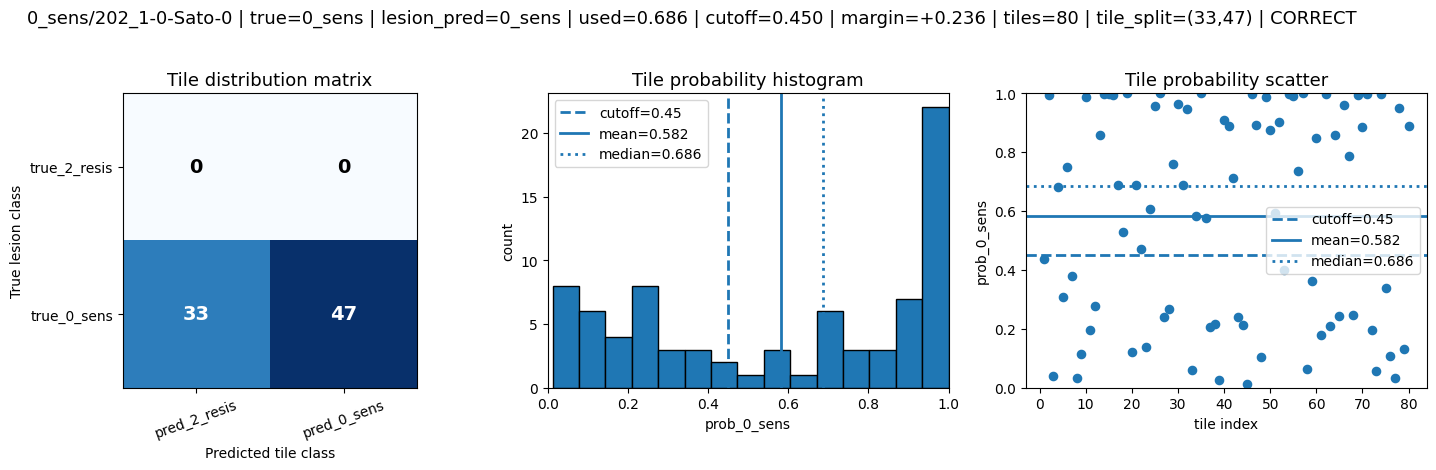

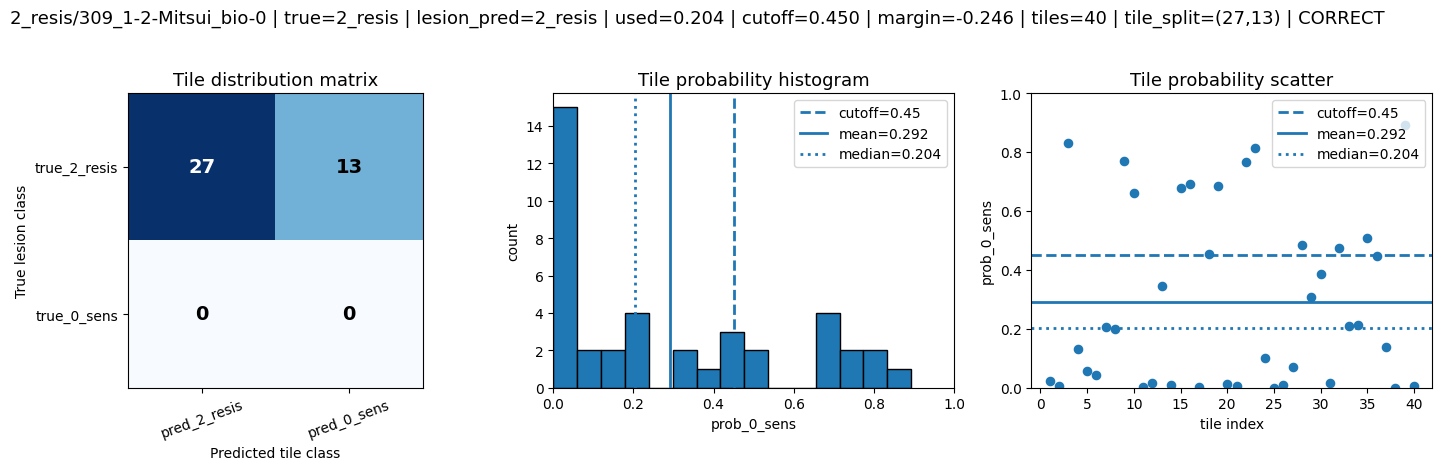

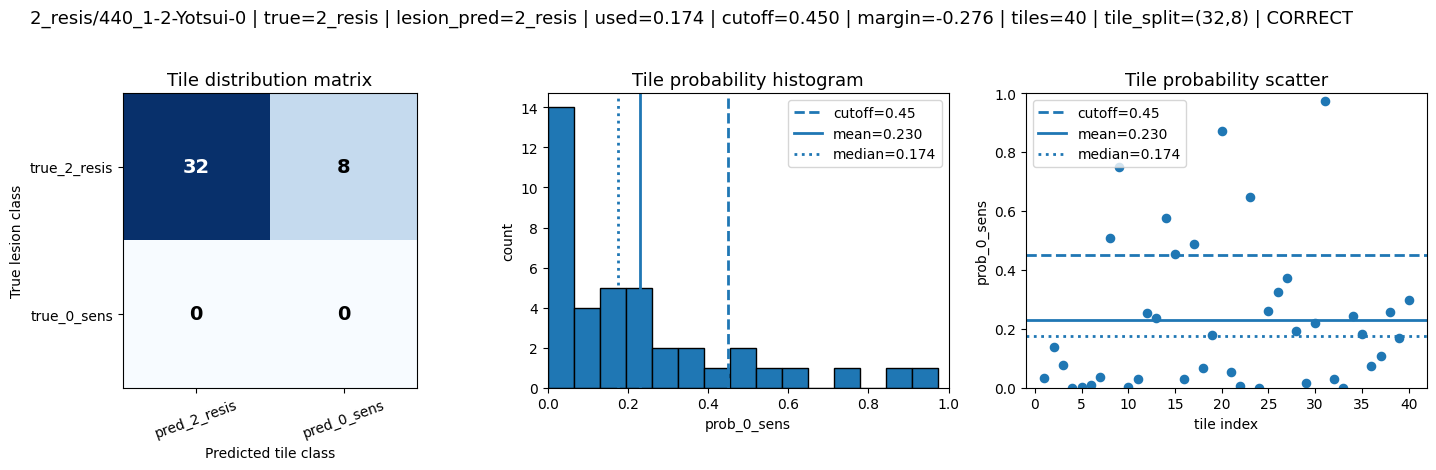

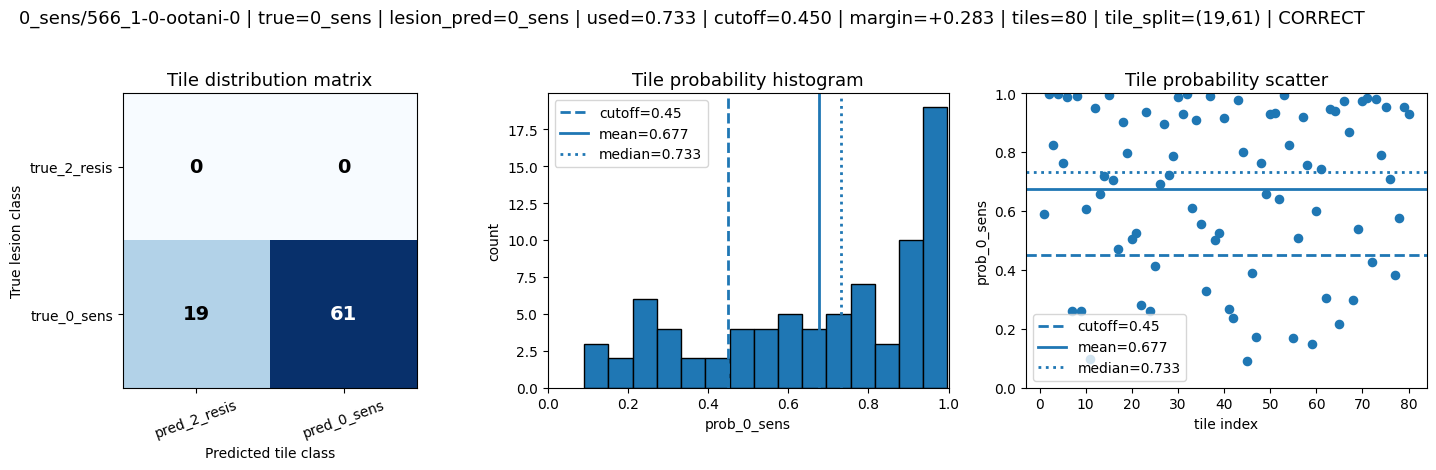

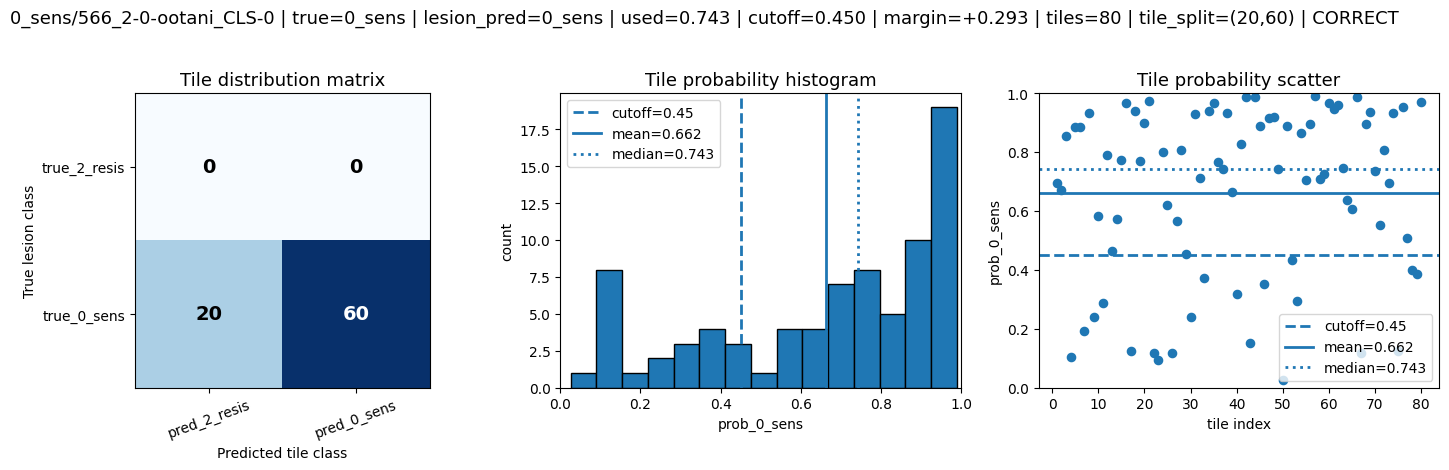

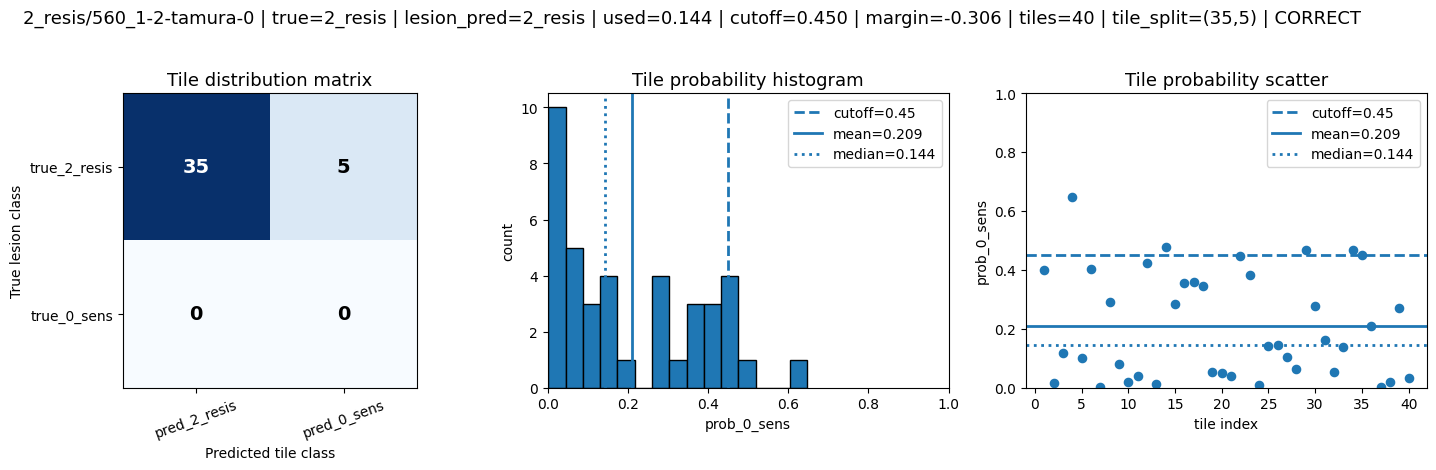

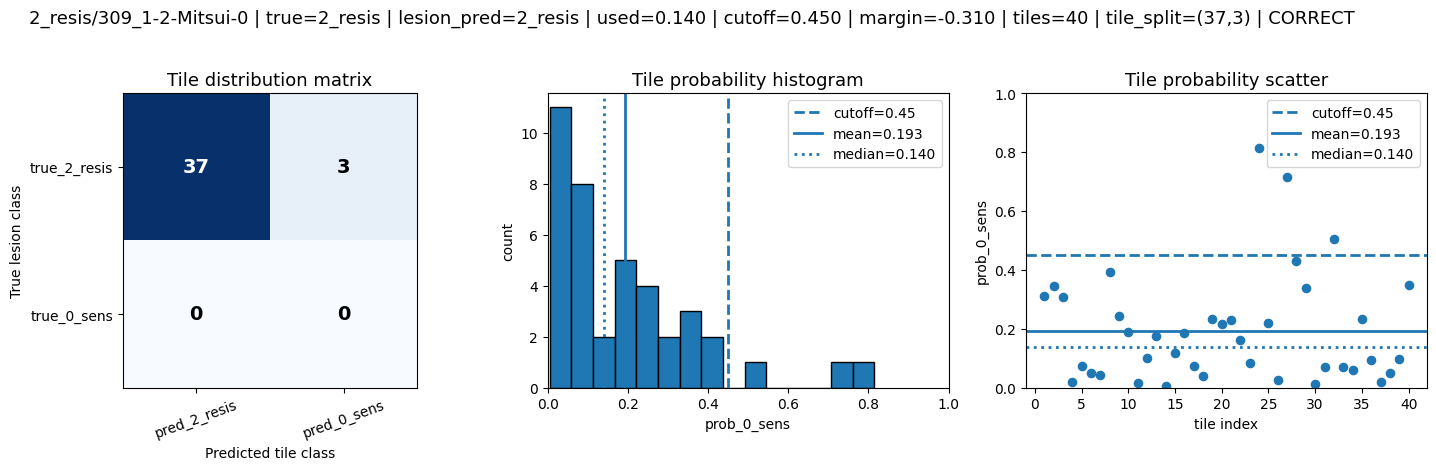

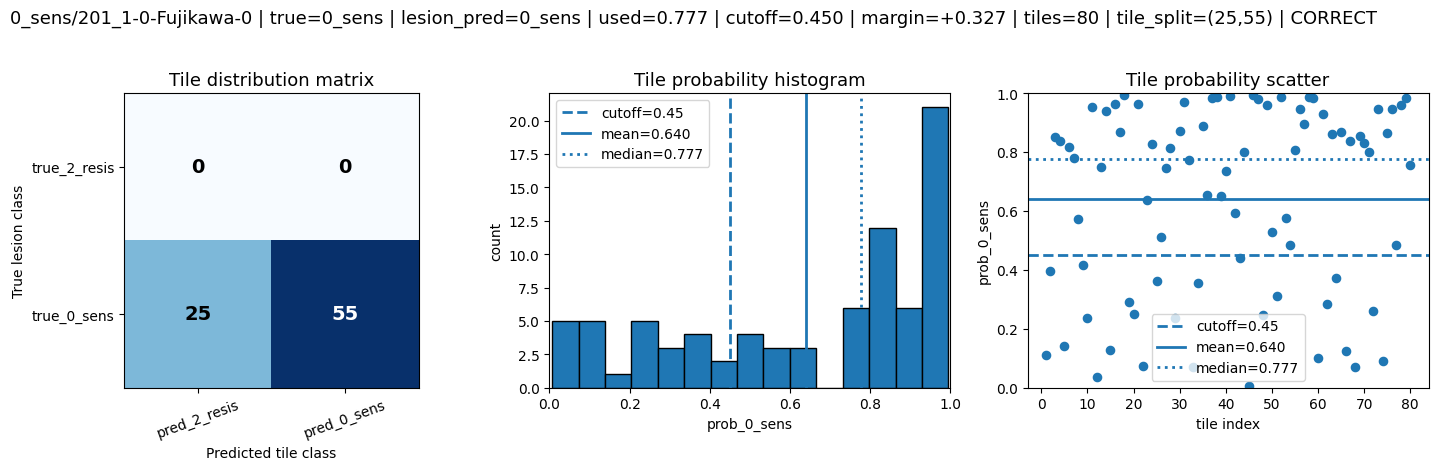

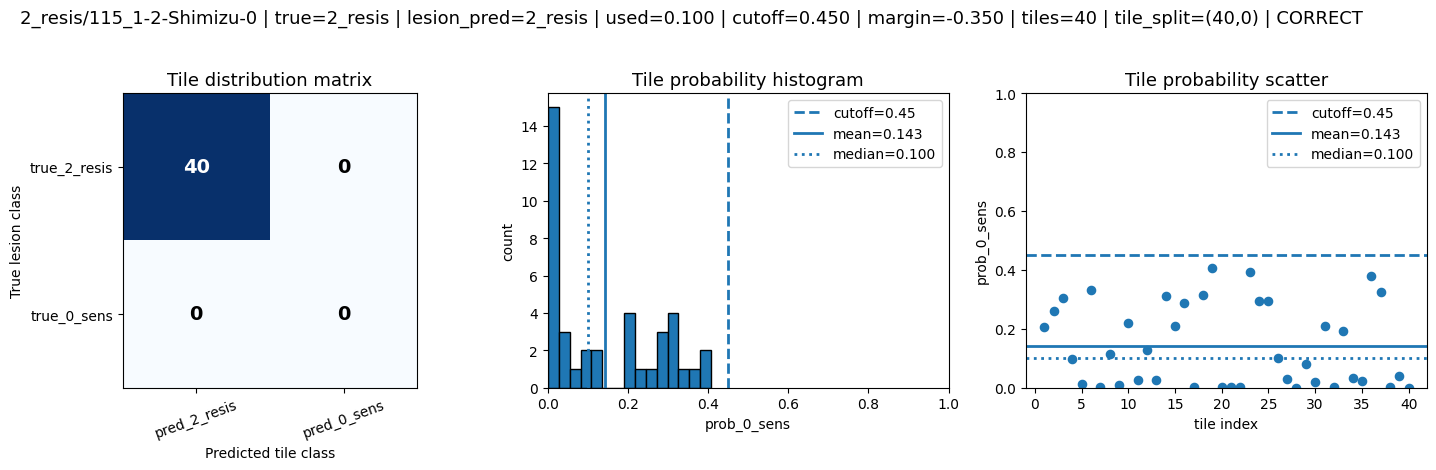

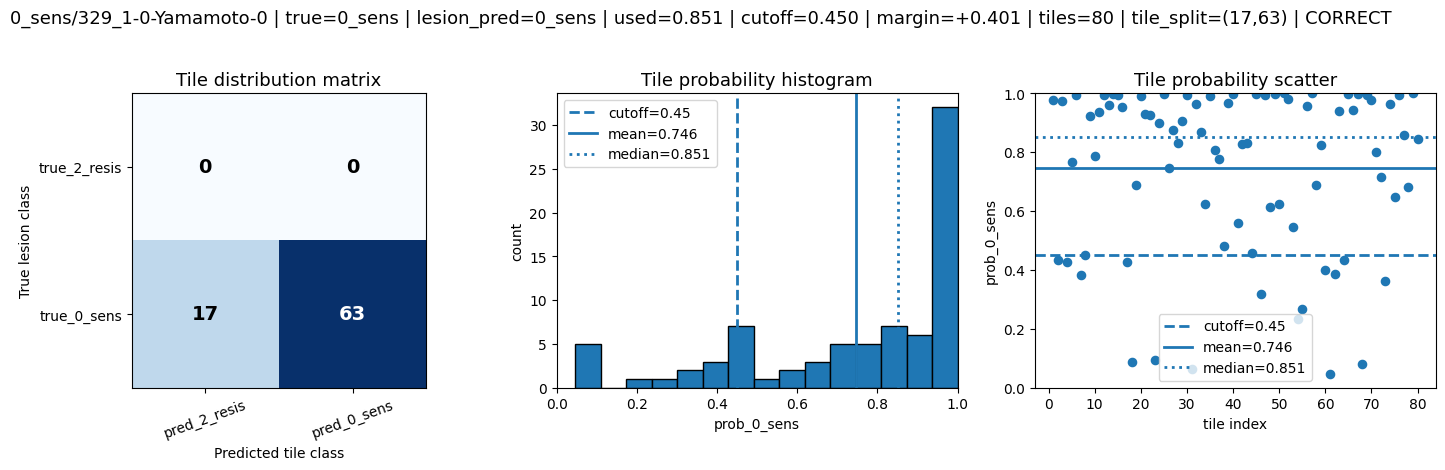

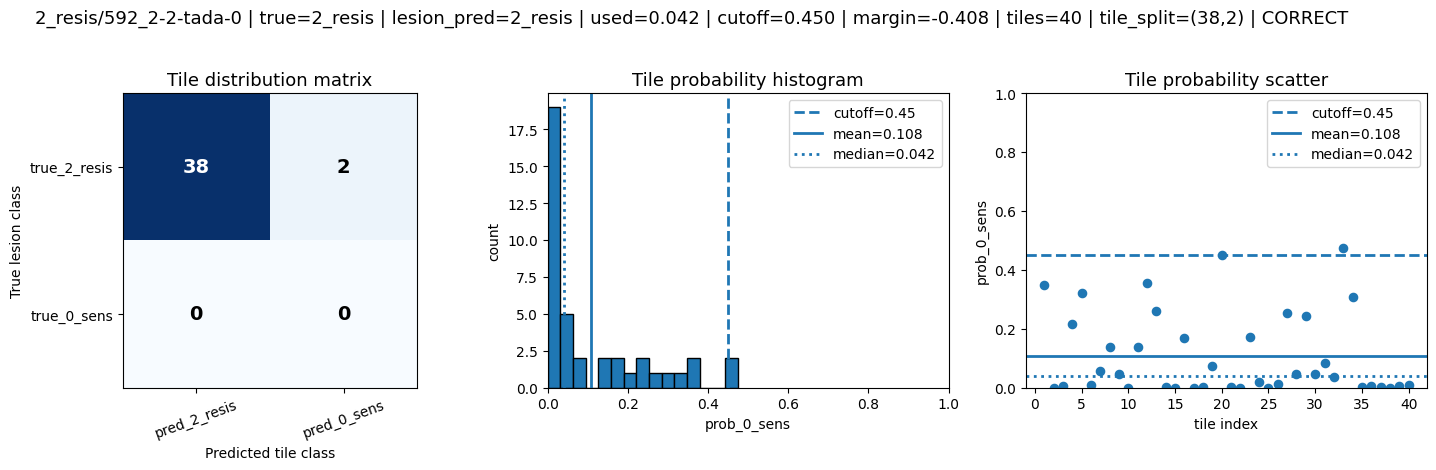

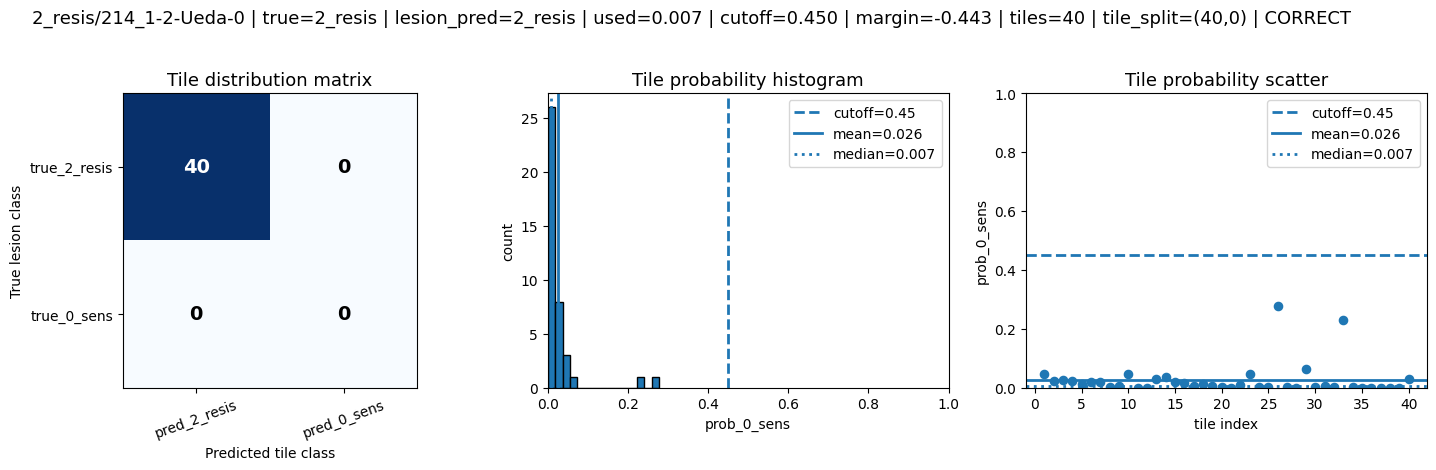

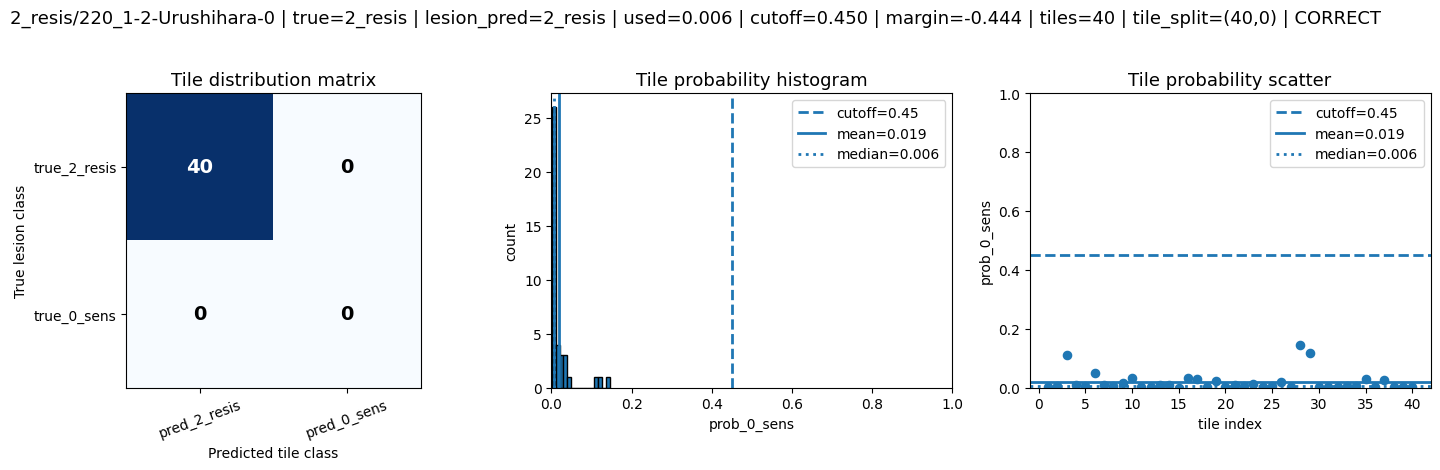

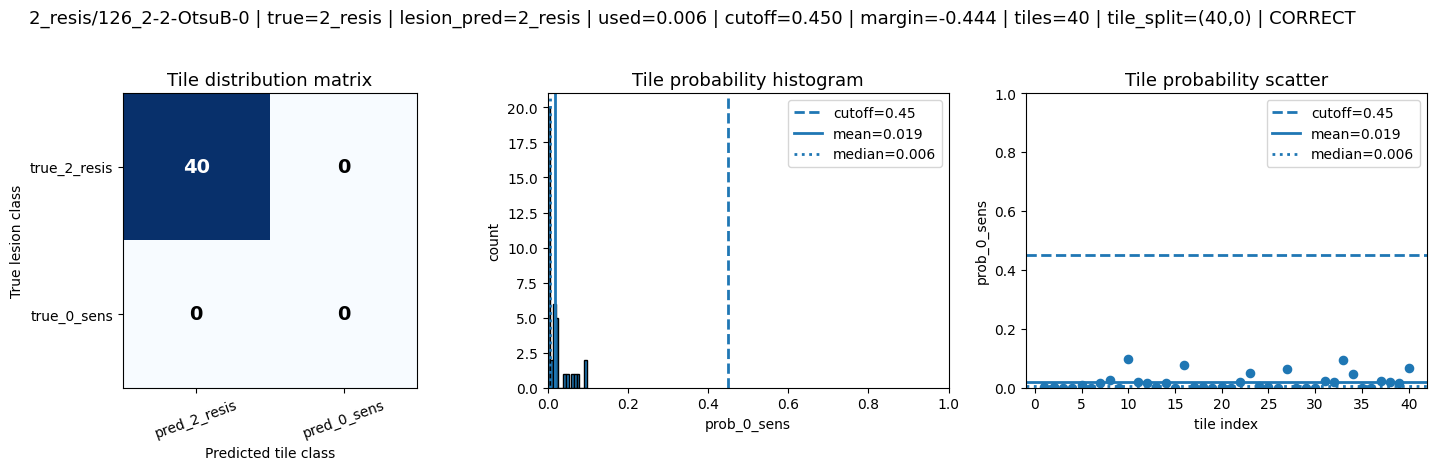

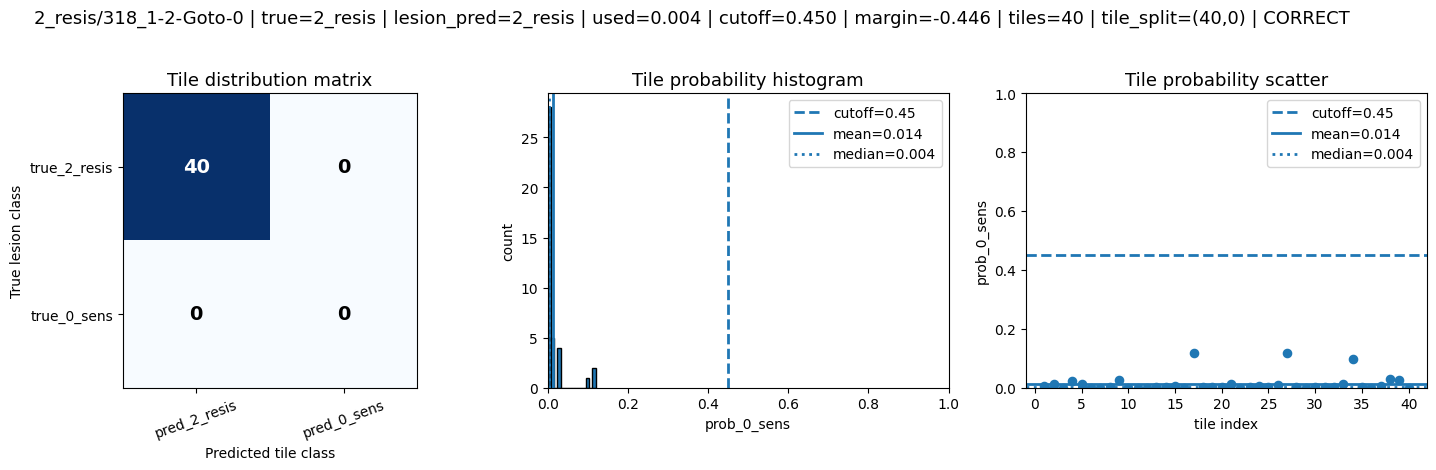

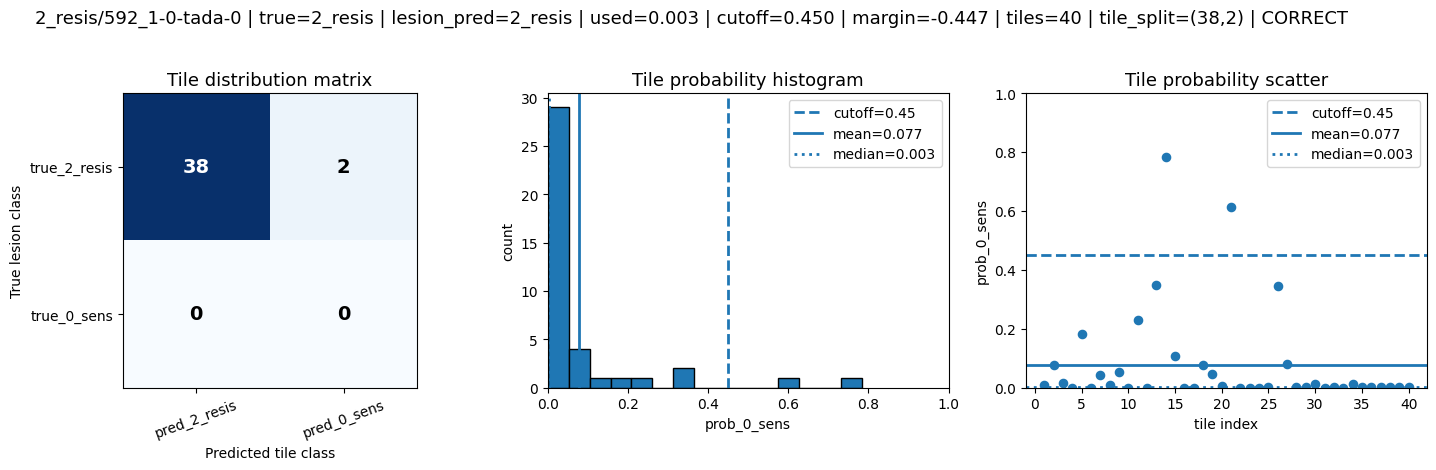

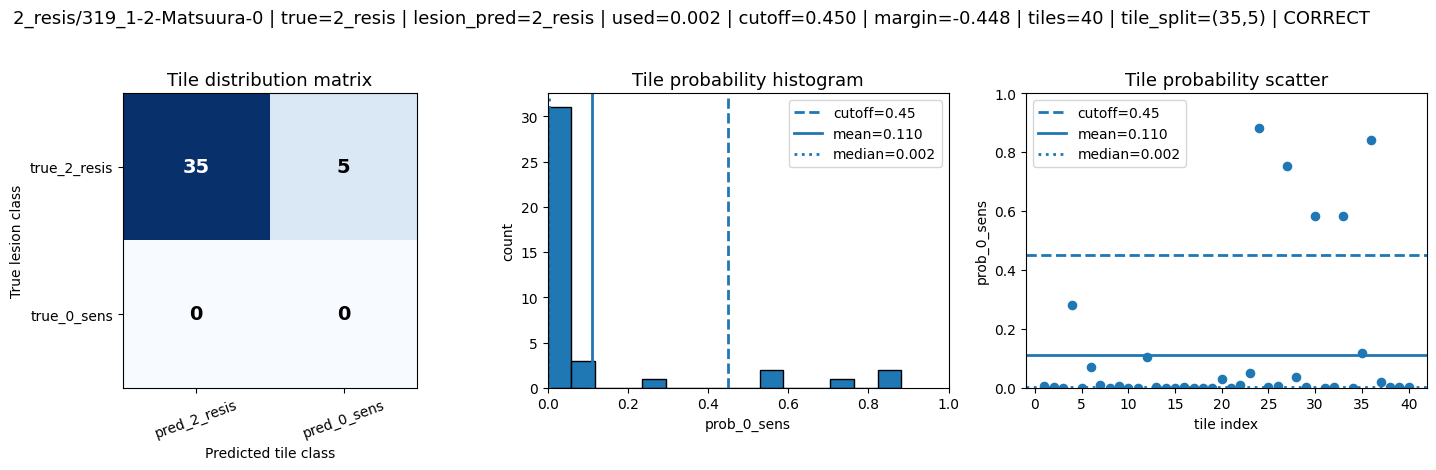

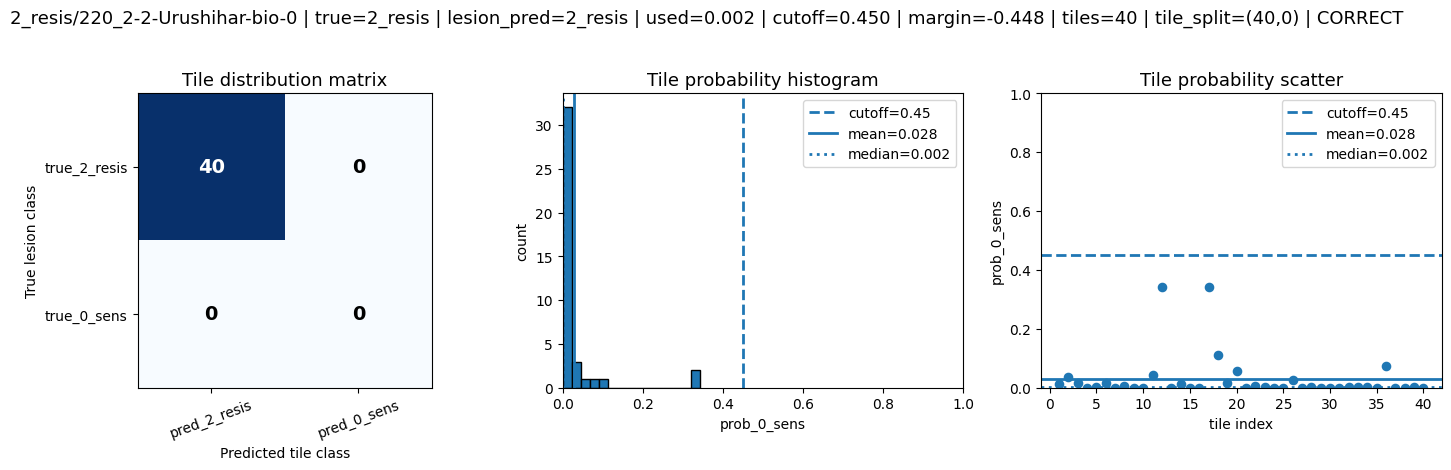

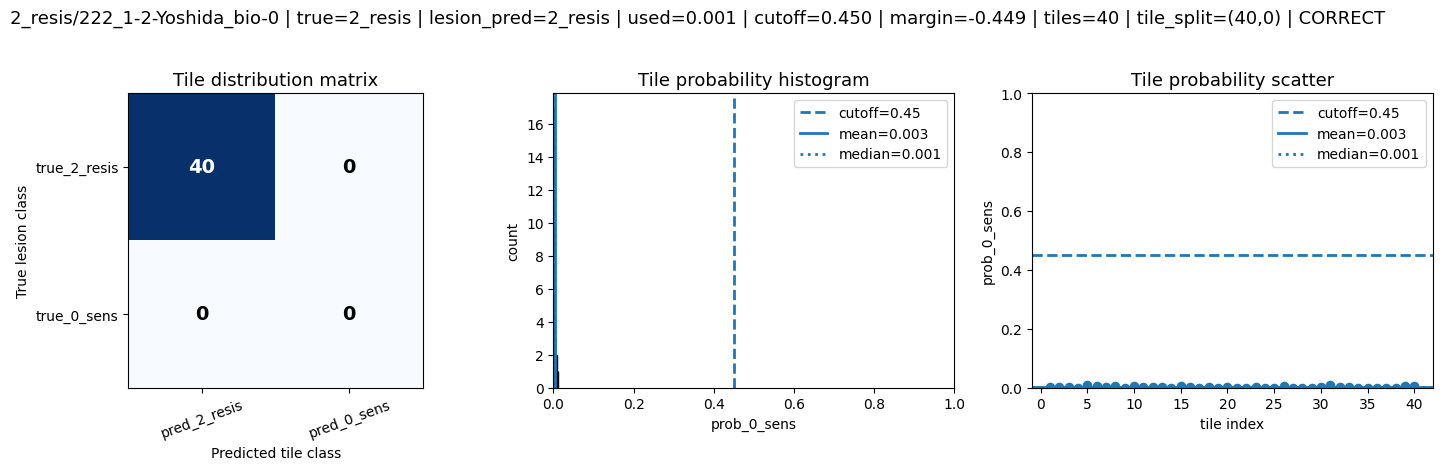

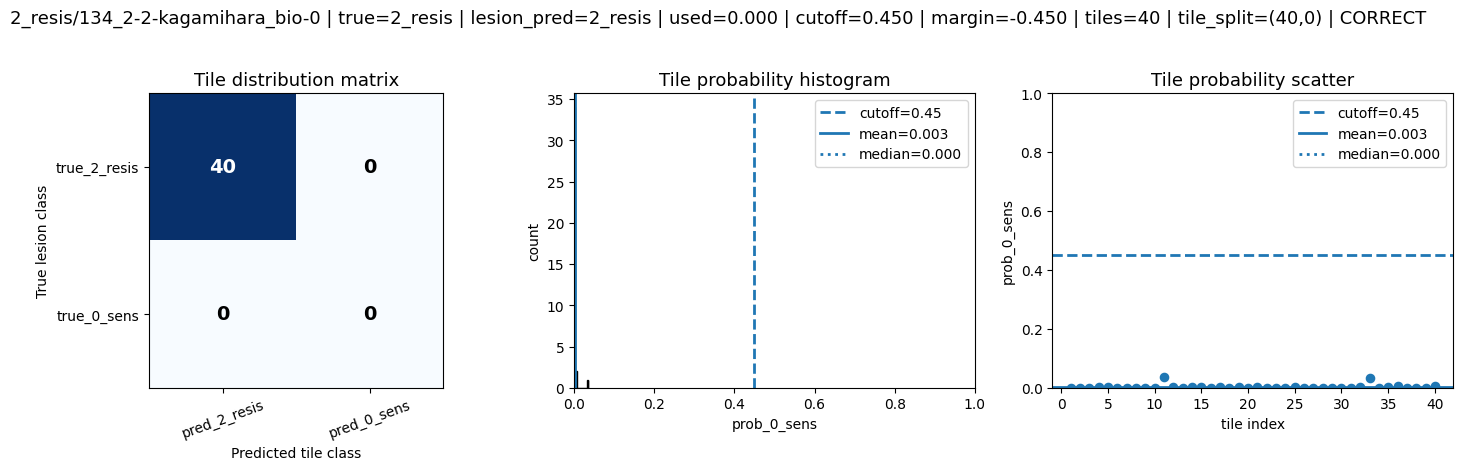

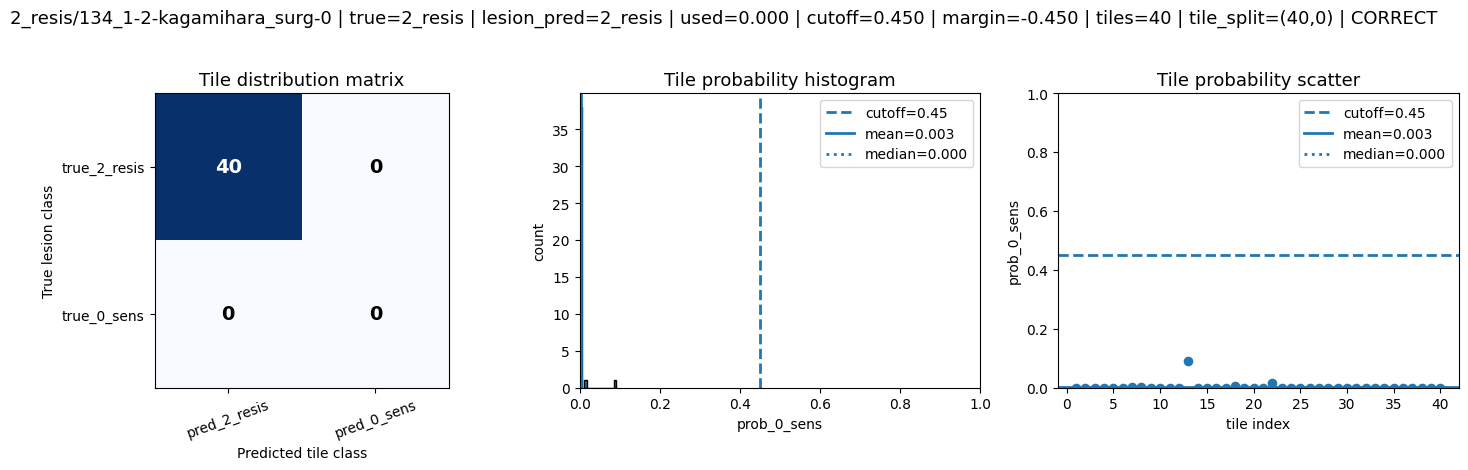

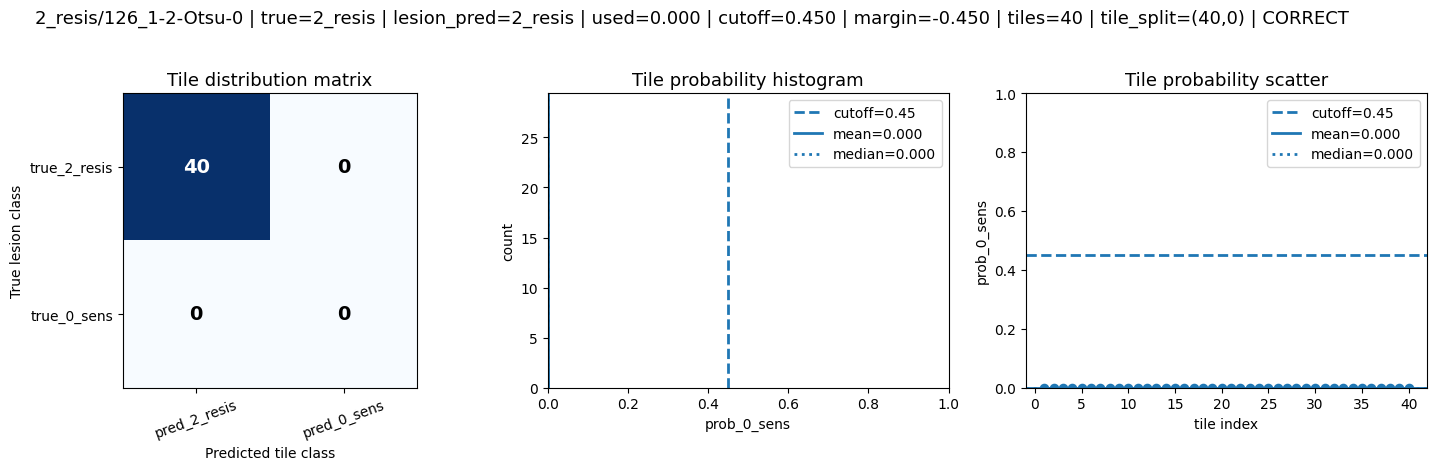

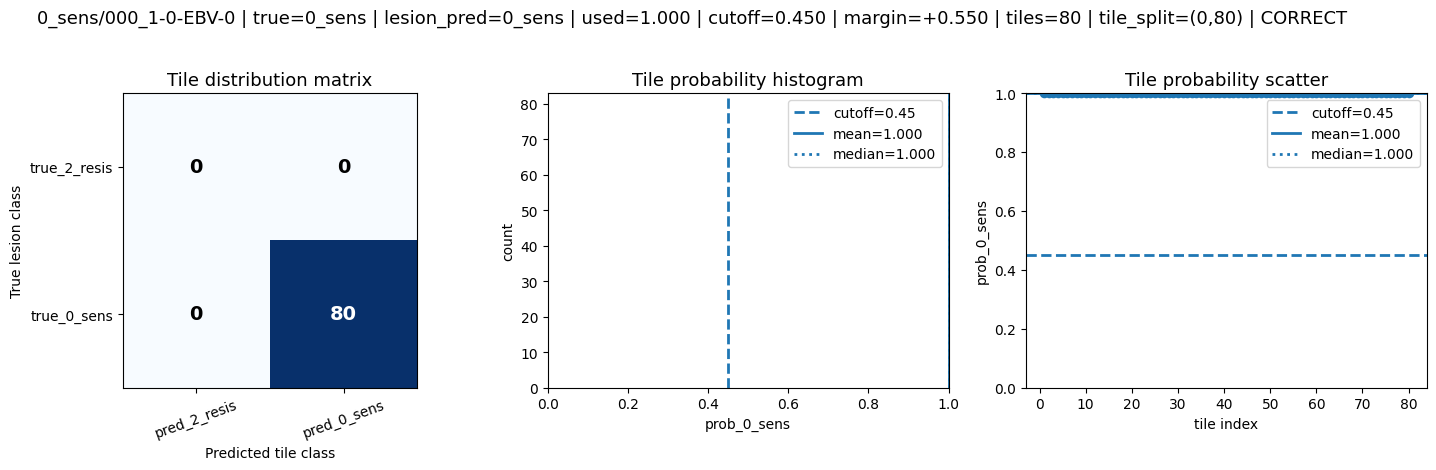


===== saved =====
excel   : /home/tatsushi/デスクトップ/cls_avg_result/eva02_large_patch14_560.mim_in22k_ft_in22k2026_hakuho-100seed-0.8weight/lesion_detail_view/lesion_detail_summary.xlsx
fig dir : /home/tatsushi/デスクトップ/cls_avg_result/eva02_large_patch14_560.mim_in22k_ft_in22k2026_hakuho-100seed-0.8weight/lesion_detail_view
===== found sheets =====
['summary', 'external_samples', 'single_tile', 'single_case_mean', 'single_case_median', 'ens_tile', 'ens_case_mean', 'ens_case_median', 'ensemble_members']

===== Wilson CI summary =====
       model_level  n_cases Accuracy [95% CI, Wilson] Recall_0_sens [95% CI, Wilson] Specificity_0_sens [95% CI, Wilson]  F1_0_sens (point estimate)
  single_case_mean       23       0.870 [0.679–0.955]            1.000 [0.610–1.000]                 0.824 [0.590–0.938]                    0.800000
single_case_median       23       0.913 [0.732–0.976]            1.000 [0.610–1.000]                 0.882 [0.657–0.967]                    0.857143
     ens_case_mean

,root,class_name,subfolder,case_id,n_images,true_label,true_class,mean_prob_0_sens,median_prob_0_sens,min_prob_0_sens,...,pred_label,pred_class,is_correct,n_tiles,n_pred_2_resis,n_pred_0_sens,ratio_pred_2_resis,ratio_pred_0_sens,tile_matrix_str,abs_margin
0,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,592_1-0-tada-0,2_resis/592_1-0-tada-0,40,0,2_resis,3.775100e-01,3.129021e-01,7.818156e-04,...,1,0_sens,0,40,18,22,0.4500,0.5500,"[[18, 22], [0, 0]]",0.062902
1,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,309_1-2-Mitsui-0,2_resis/309_1-2-Mitsui-0,40,0,2_resis,4.213304e-01,4.046180e-01,1.776529e-03,...,1,0_sens,0,40,17,23,0.4250,0.5750,"[[17, 23], [0, 0]]",0.154618
2,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,220_1-2-Urushihara-0,2_resis/220_1-2-Urushihara-0,40,0,2_resis,1.707801e-01,1.590353e-01,8.837841e-03,...,0,2_resis,1,40,31,9,0.7750,0.2250,"[[31, 9], [0, 0]]",0.090965
3,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,309_1-2-Mitsui_bio-0,2_resis/309_1-2-Mitsui_bio-0,40,0,2_resis,2.206113e-01,8.048012e-02,2.423657e-08,...,0,2_resis,1,40,25,15,0.6250,0.3750,"[[25, 15], [0, 0]]",0.169520
4,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,592_2-2-tada-0,2_resis/592_2-2-tada-0,40,0,2_resis,1.597661e-01,5.096114e-02,4.780777e-04,...,0,2_resis,1,40,30,10,0.7500,0.2500,"[[30, 10], [0, 0]]",0.199039
5,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,440_1-2-Yotsui-0,2_resis/440_1-2-Yotsui-0,40,0,2_resis,9.541934e-02,2.828113e-02,3.615683e-05,...,0,2_resis,1,40,35,5,0.8750,0.1250,"[[35, 5], [0, 0]]",0.221719
6,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,560_1-2-tamura-0,2_resis/560_1-2-tamura-0,40,0,2_resis,1.534440e-01,1.464821e-02,4.079091e-05,...,0,2_resis,1,40,31,9,0.7750,0.2250,"[[31, 9], [0, 0]]",0.235352
7,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,214_1-2-Ueda-0,2_resis/214_1-2-Ueda-0,40,0,2_resis,9.260532e-02,1.242058e-02,2.541675e-05,...,0,2_resis,1,40,35,5,0.8750,0.1250,"[[35, 5], [0, 0]]",0.237579
8,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,318_1-2-Goto-0,2_resis/318_1-2-Goto-0,40,0,2_resis,2.254337e-02,2.582809e-03,1.300922e-04,...,0,2_resis,1,40,40,0,1.0000,0.0000,"[[40, 0], [0, 0]]",0.247417
9,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,220_2-2-Urushihar-bio-0,2_resis/220_2-2-Urushihar-bio-0,40,0,2_resis,1.462463e-02,1.376511e-03,1.009976e-06,...,0,2_resis,1,40,40,0,1.0000,0.0000,"[[40, 0], [0, 0]]",0.248623



===== tile distribution summary =====


,case_id,true_class,pred_class,n_tiles,n_pred_2_resis,n_pred_0_sens,used_prob_0_sens,cutoff,margin_from_cutoff,tile_matrix_str
0,2_resis/592_1-0-tada-0,2_resis,0_sens,40,18,22,3.129021e-01,0.25,0.062902,"[[18, 22], [0, 0]]"
1,2_resis/309_1-2-Mitsui-0,2_resis,0_sens,40,17,23,4.046180e-01,0.25,0.154618,"[[17, 23], [0, 0]]"
2,2_resis/220_1-2-Urushihara-0,2_resis,2_resis,40,31,9,1.590353e-01,0.25,-0.090965,"[[31, 9], [0, 0]]"
3,2_resis/309_1-2-Mitsui_bio-0,2_resis,2_resis,40,25,15,8.048012e-02,0.25,-0.169520,"[[25, 15], [0, 0]]"
4,2_resis/592_2-2-tada-0,2_resis,2_resis,40,30,10,5.096114e-02,0.25,-0.199039,"[[30, 10], [0, 0]]"
5,2_resis/440_1-2-Yotsui-0,2_resis,2_resis,40,35,5,2.828113e-02,0.25,-0.221719,"[[35, 5], [0, 0]]"
6,2_resis/560_1-2-tamura-0,2_resis,2_resis,40,31,9,1.464821e-02,0.25,-0.235352,"[[31, 9], [0, 0]]"
7,2_resis/214_1-2-Ueda-0,2_resis,2_resis,40,35,5,1.242058e-02,0.25,-0.237579,"[[35, 5], [0, 0]]"
8,2_resis/318_1-2-Goto-0,2_resis,2_resis,40,40,0,2.582809e-03,0.25,-0.247417,"[[40, 0], [0, 0]]"
9,2_resis/220_2-2-Urushihar-bio-0,2_resis,2_resis,40,40,0,1.376511e-03,0.25,-0.248623,"[[40, 0], [0, 0]]"



===== lesion-level confusion matrix =====


,pred_2_resis,pred_0_sens
true_2_resis,15,2
true_0_sens,0,6


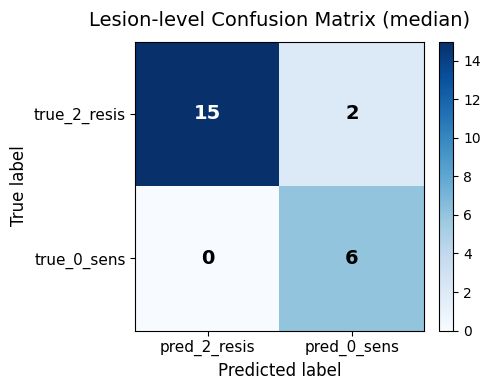

Lesion-level accuracy = 0.9130

===== classification report =====
              precision    recall  f1-score   support

     2_resis     1.0000    0.8824    0.9375        17
      0_sens     0.7500    1.0000    0.8571         6

    accuracy                         0.9130        23
   macro avg     0.8750    0.9412    0.8973        23
weighted avg     0.9348    0.9130    0.9165        23


===== wrong lesions =====


,root,class_name,subfolder,case_id,n_images,true_label,true_class,mean_prob_0_sens,median_prob_0_sens,min_prob_0_sens,...,pred_label,pred_class,is_correct,n_tiles,n_pred_2_resis,n_pred_0_sens,ratio_pred_2_resis,ratio_pred_0_sens,tile_matrix_str,abs_margin
0,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,592_1-0-tada-0,2_resis/592_1-0-tada-0,40,0,2_resis,0.37751,0.312902,0.000782,...,1,0_sens,0,40,18,22,0.450,0.550,"[[18, 22], [0, 0]]",0.062902
1,/home/tatsushi/デスクトップ/sensitivity_data7/image-...,2_resis,309_1-2-Mitsui-0,2_resis/309_1-2-Mitsui-0,40,0,2_resis,0.42133,0.404618,0.001777,...,1,0_sens,0,40,17,23,0.425,0.575,"[[17, 23], [0, 0]]",0.154618



===== borderline lesions =====


,case_id,true_class,pred_class,n_tiles,n_pred_2_resis,n_pred_0_sens,used_prob_0_sens,cutoff,margin_from_cutoff,tile_matrix_str
0,2_resis/592_1-0-tada-0,2_resis,0_sens,40,18,22,3.129021e-01,0.25,0.062902,"[[18, 22], [0, 0]]"
2,2_resis/220_1-2-Urushihara-0,2_resis,2_resis,40,31,9,1.590353e-01,0.25,-0.090965,"[[31, 9], [0, 0]]"
1,2_resis/309_1-2-Mitsui-0,2_resis,0_sens,40,17,23,4.046180e-01,0.25,0.154618,"[[17, 23], [0, 0]]"
3,2_resis/309_1-2-Mitsui_bio-0,2_resis,2_resis,40,25,15,8.048012e-02,0.25,-0.169520,"[[25, 15], [0, 0]]"
4,2_resis/592_2-2-tada-0,2_resis,2_resis,40,30,10,5.096114e-02,0.25,-0.199039,"[[30, 10], [0, 0]]"
5,2_resis/440_1-2-Yotsui-0,2_resis,2_resis,40,35,5,2.828113e-02,0.25,-0.221719,"[[35, 5], [0, 0]]"
6,2_resis/560_1-2-tamura-0,2_resis,2_resis,40,31,9,1.464821e-02,0.25,-0.235352,"[[31, 9], [0, 0]]"
7,2_resis/214_1-2-Ueda-0,2_resis,2_resis,40,35,5,1.242058e-02,0.25,-0.237579,"[[35, 5], [0, 0]]"
8,2_resis/318_1-2-Goto-0,2_resis,2_resis,40,40,0,2.582809e-03,0.25,-0.247417,"[[40, 0], [0, 0]]"
9,2_resis/220_2-2-Urushihar-bio-0,2_resis,2_resis,40,40,0,1.376511e-03,0.25,-0.248623,"[[40, 0], [0, 0]]"



===== auto display lesions: up to 23 =====


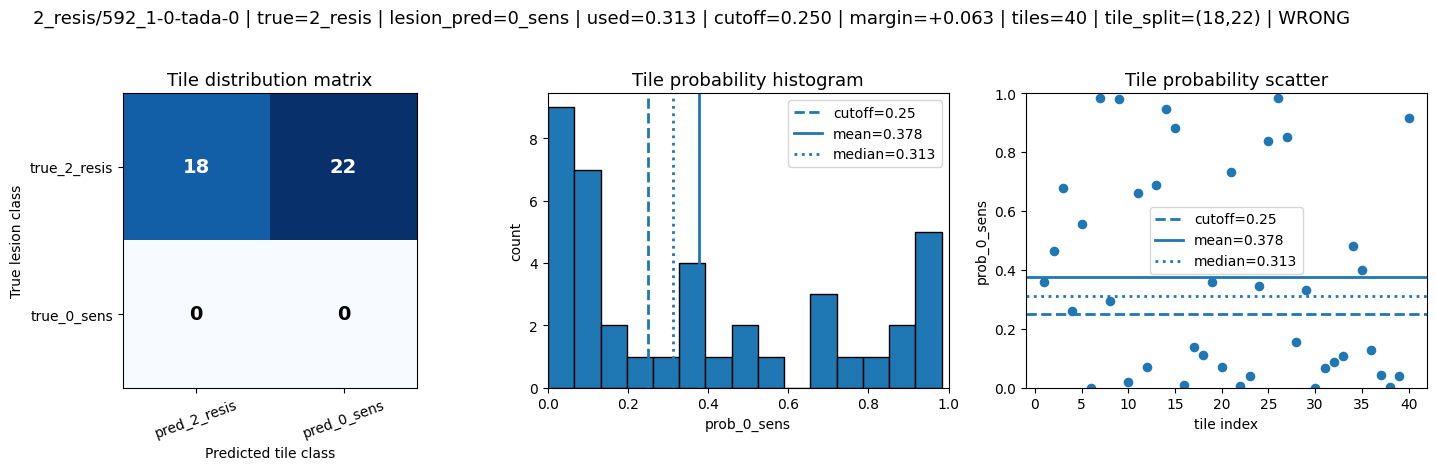

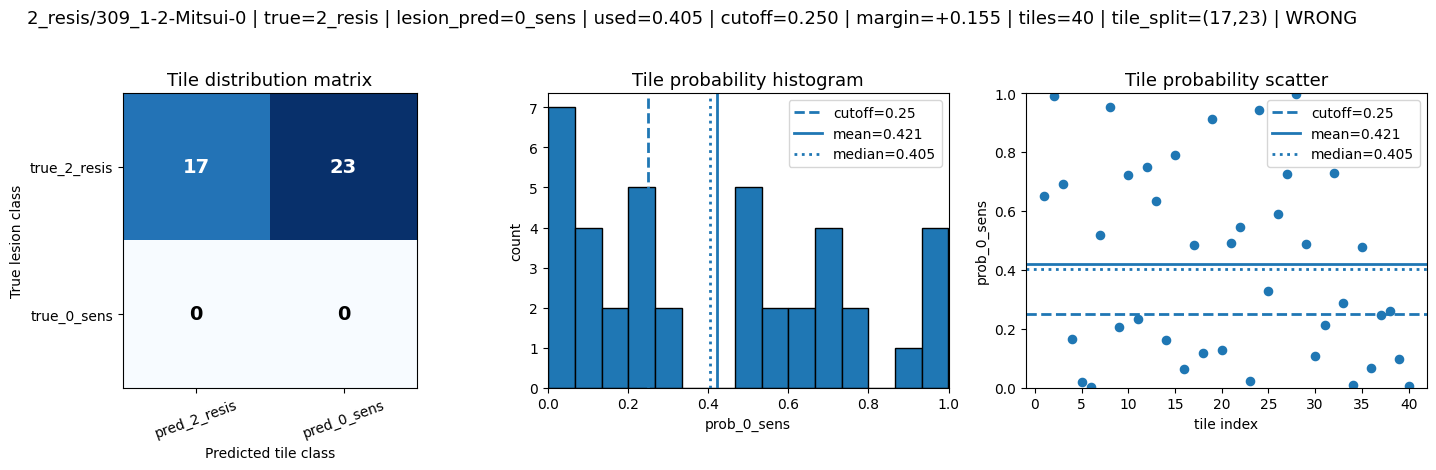

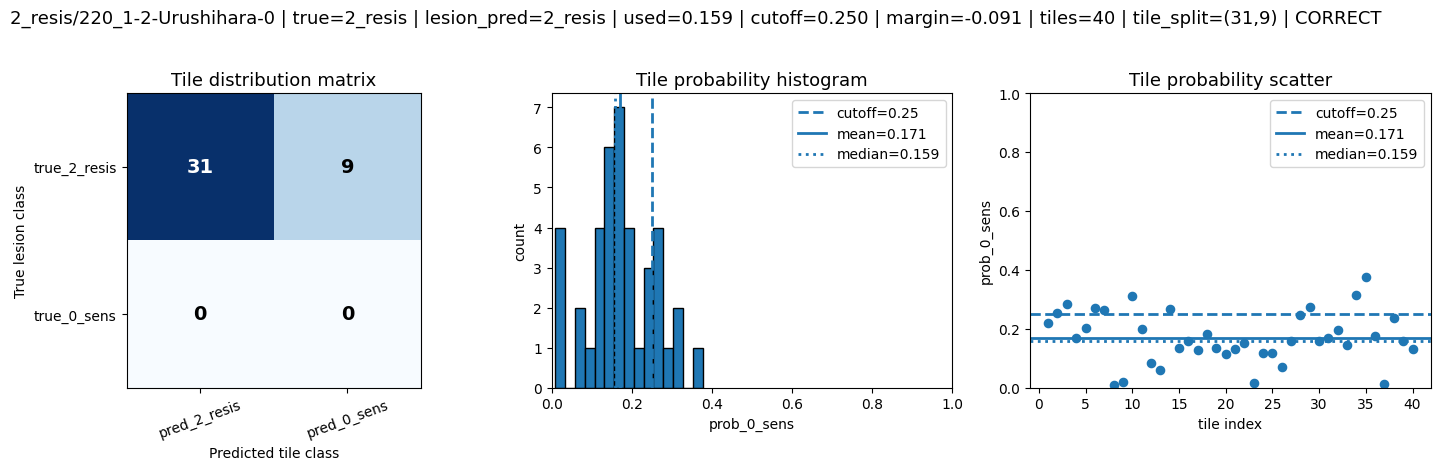

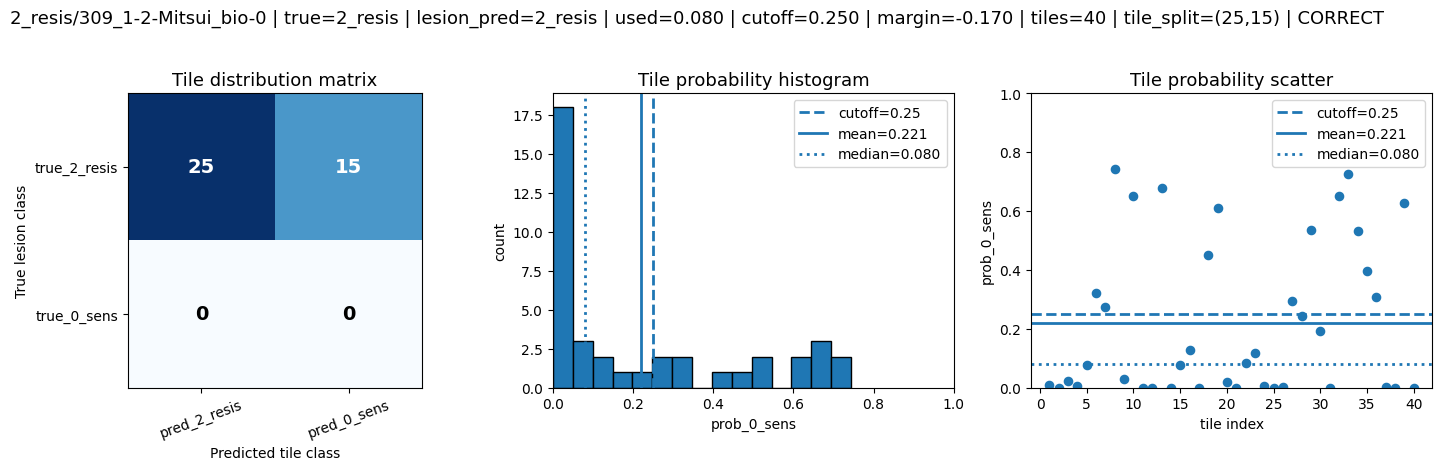

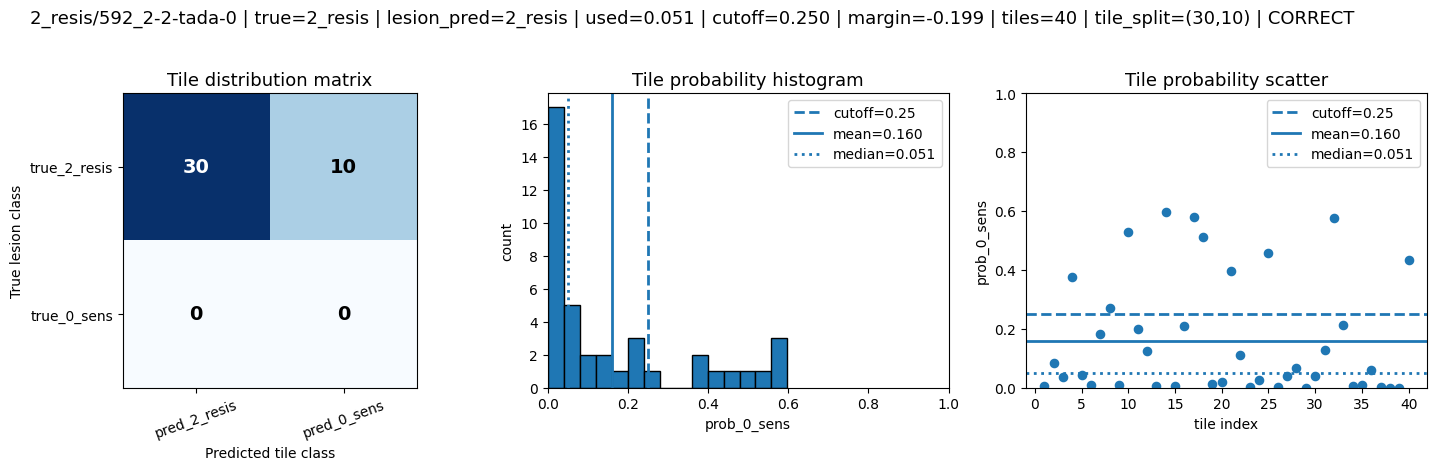

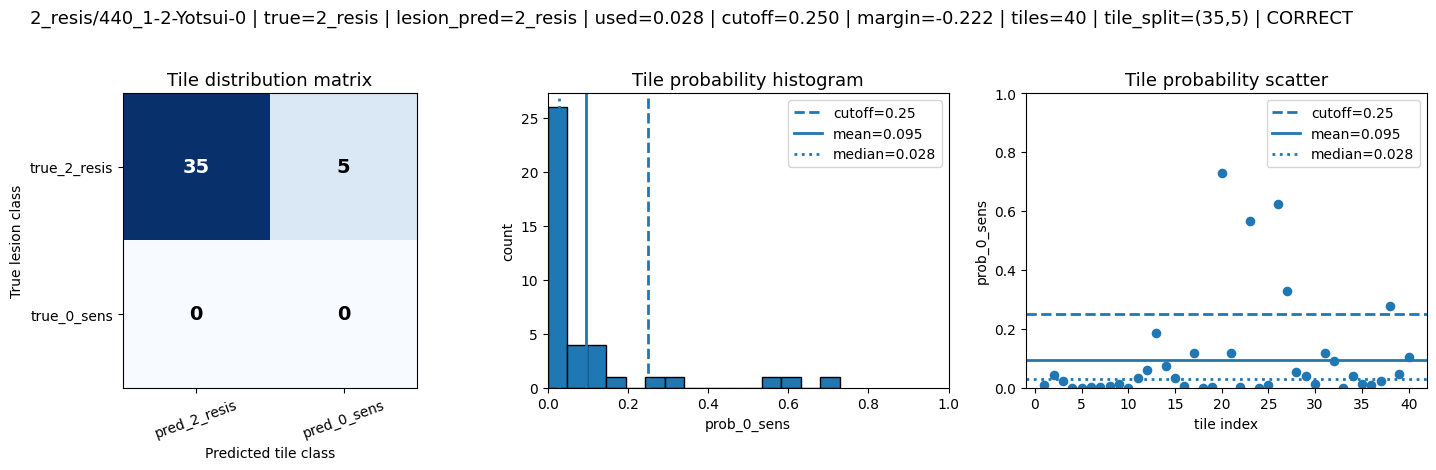

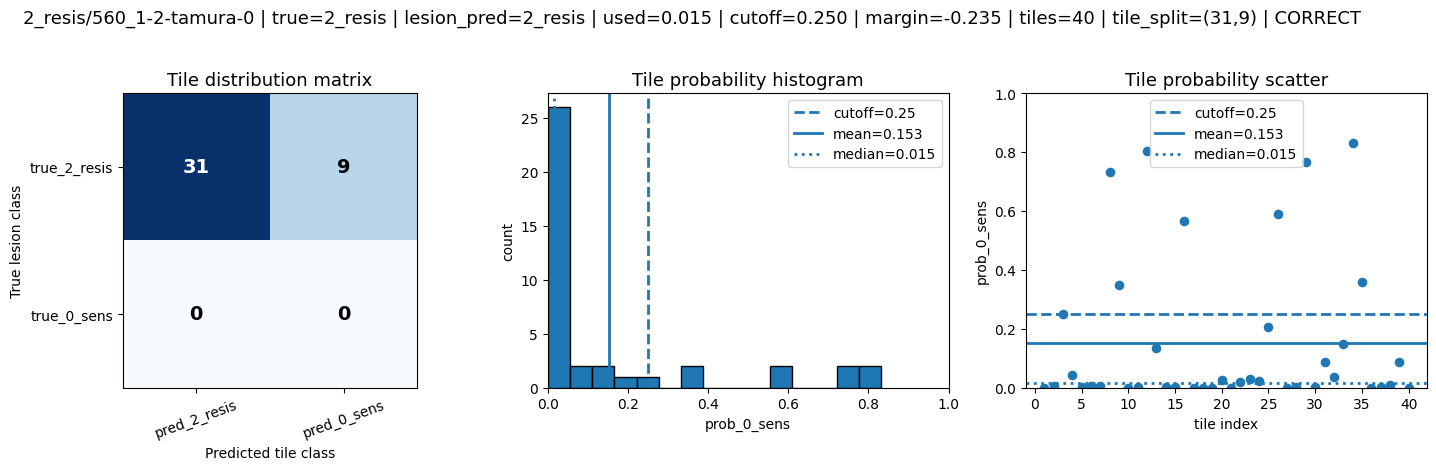

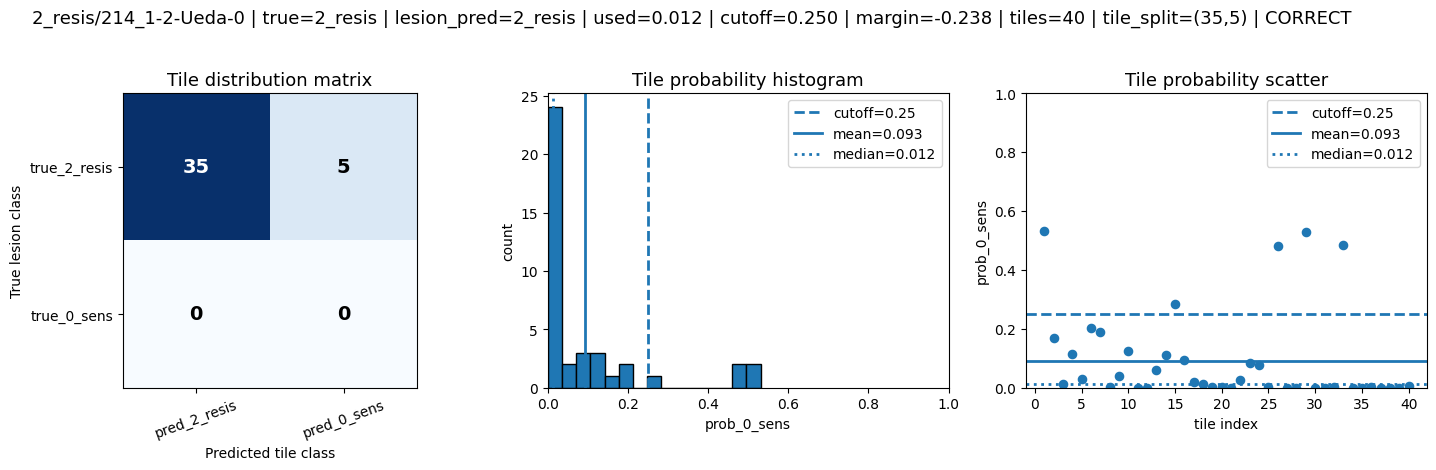

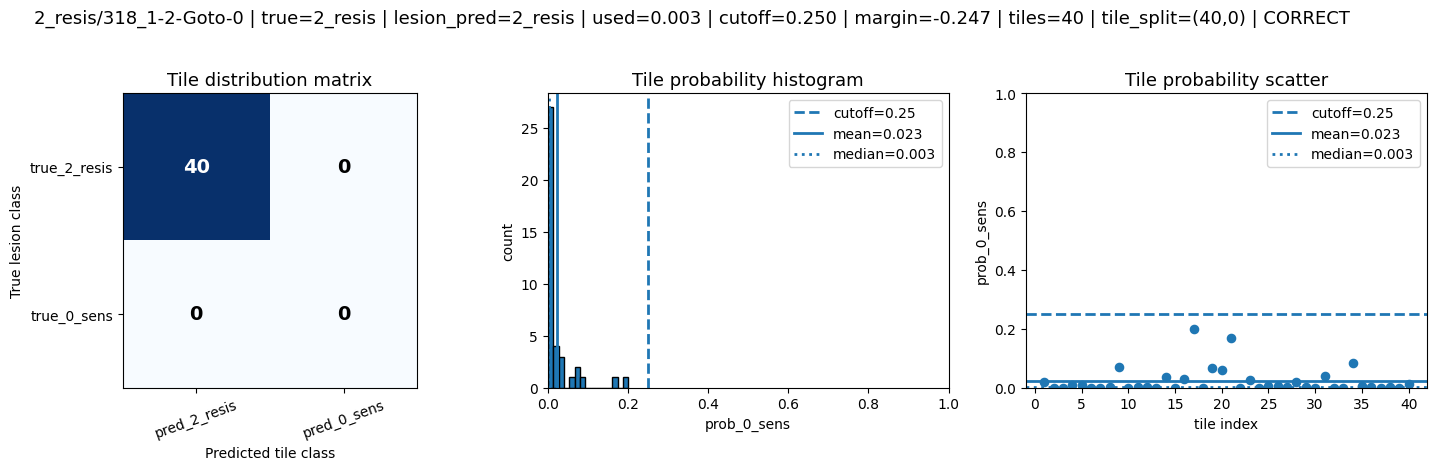

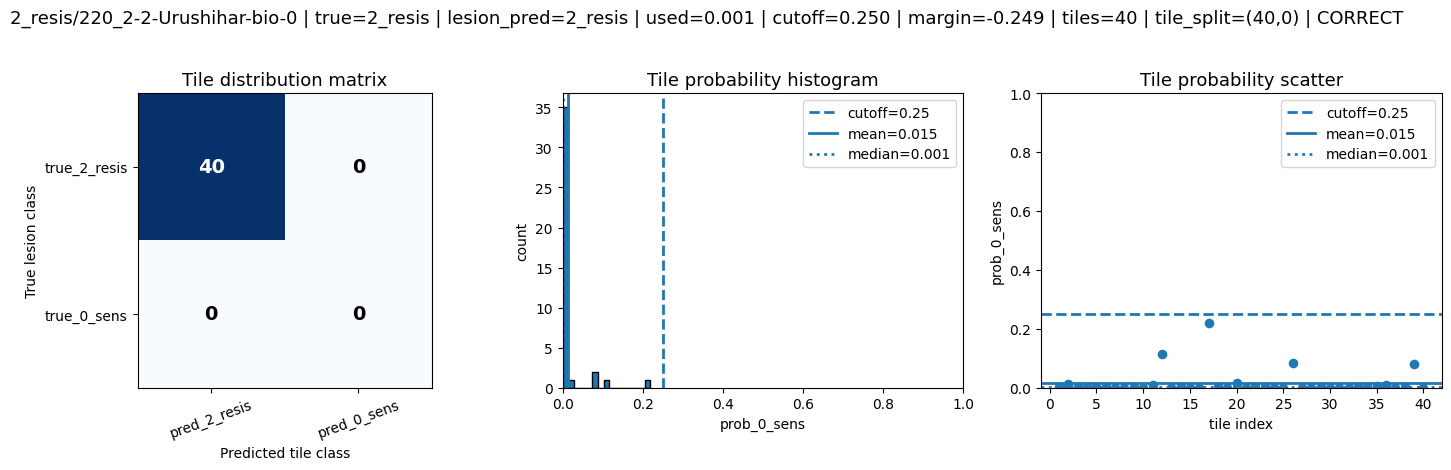

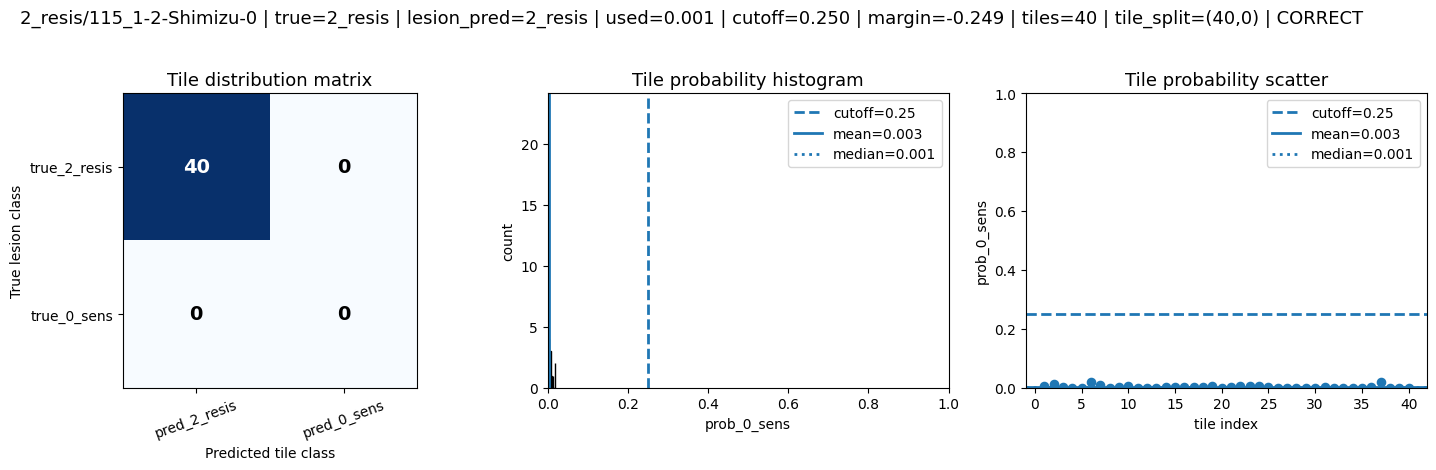

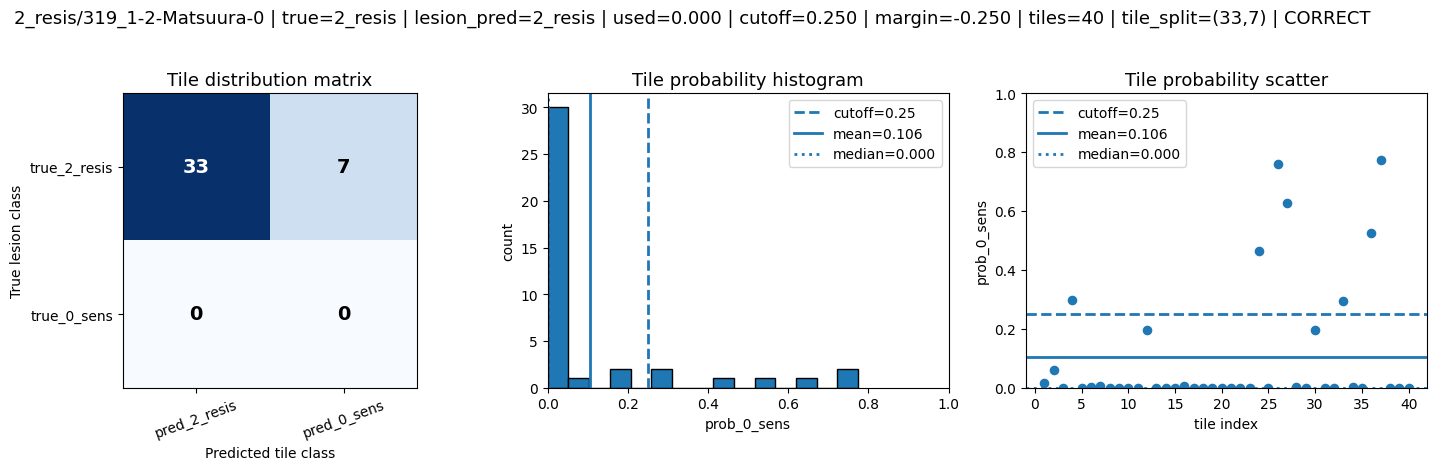

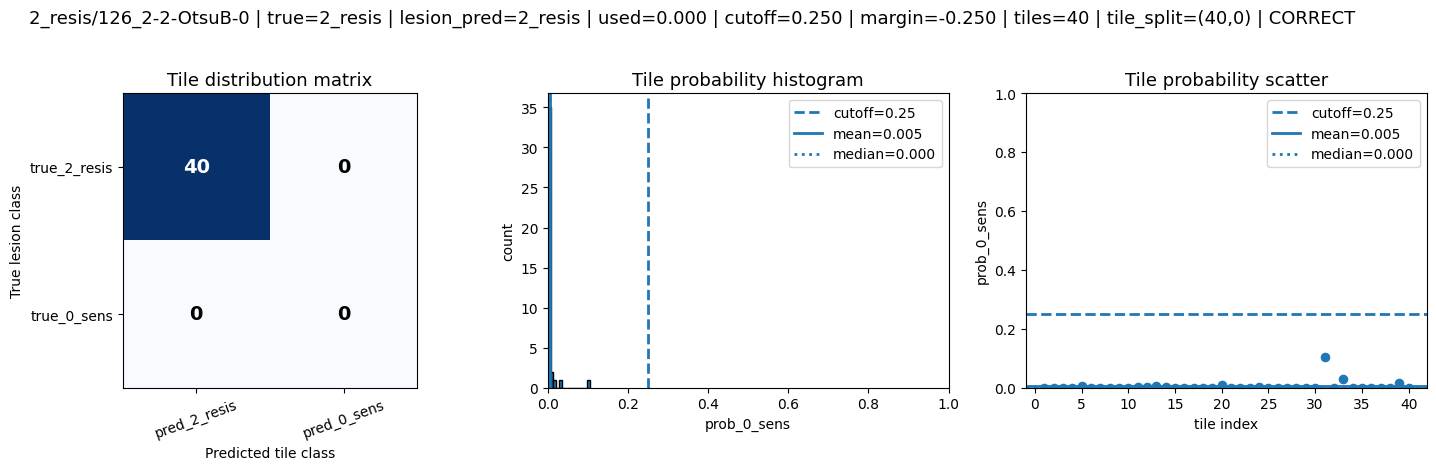

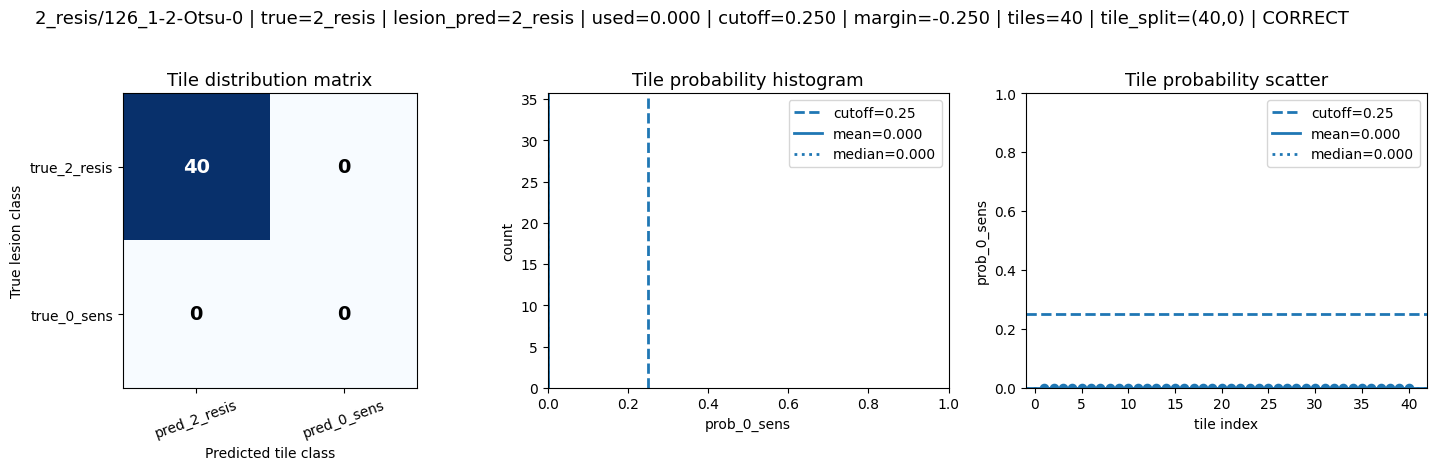

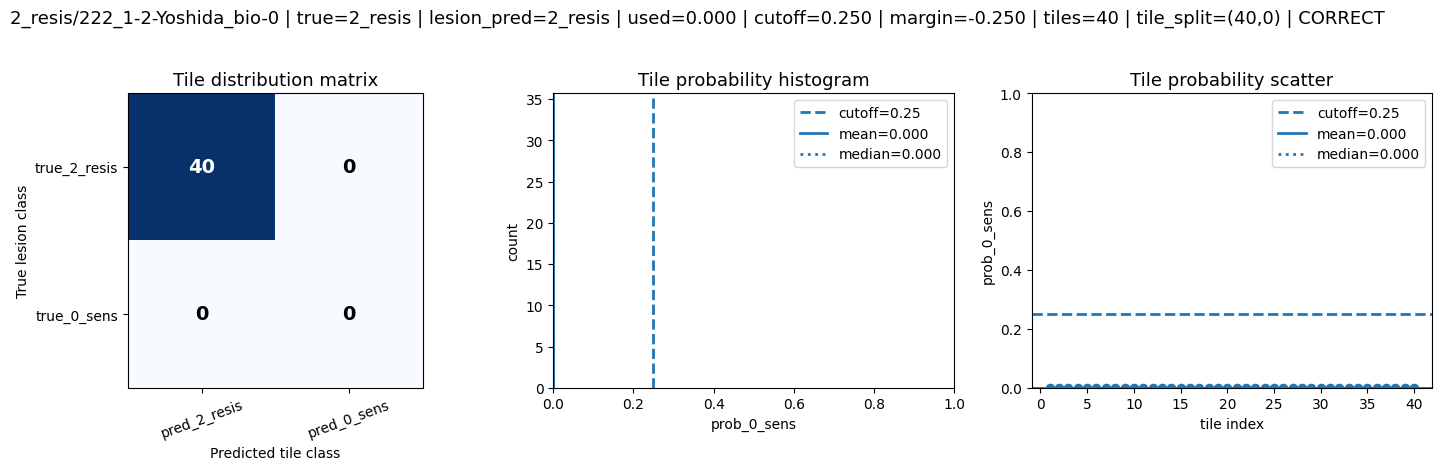

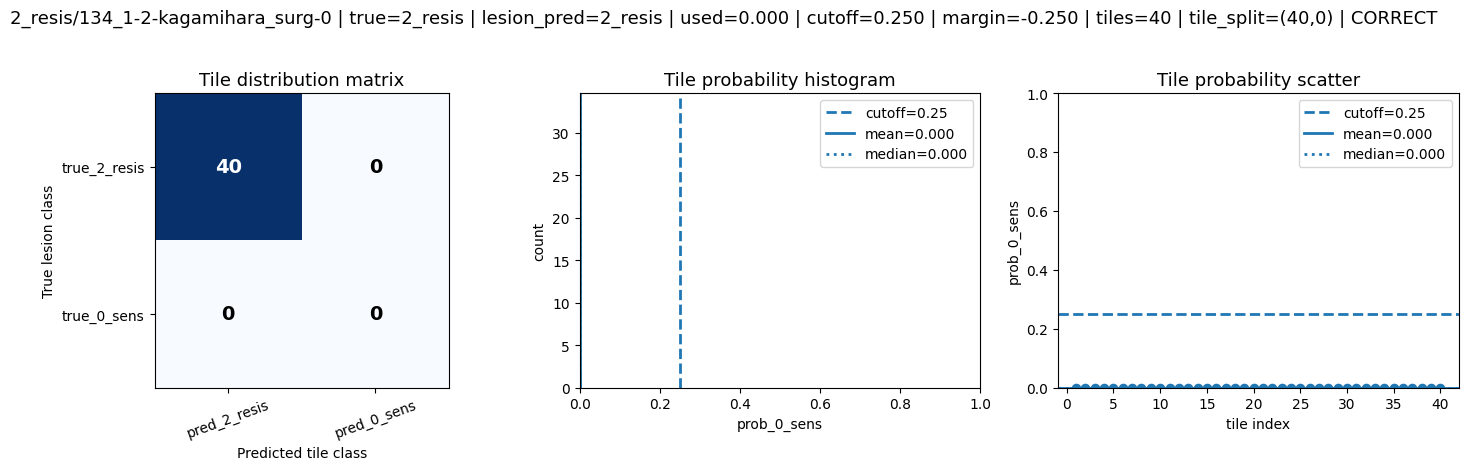

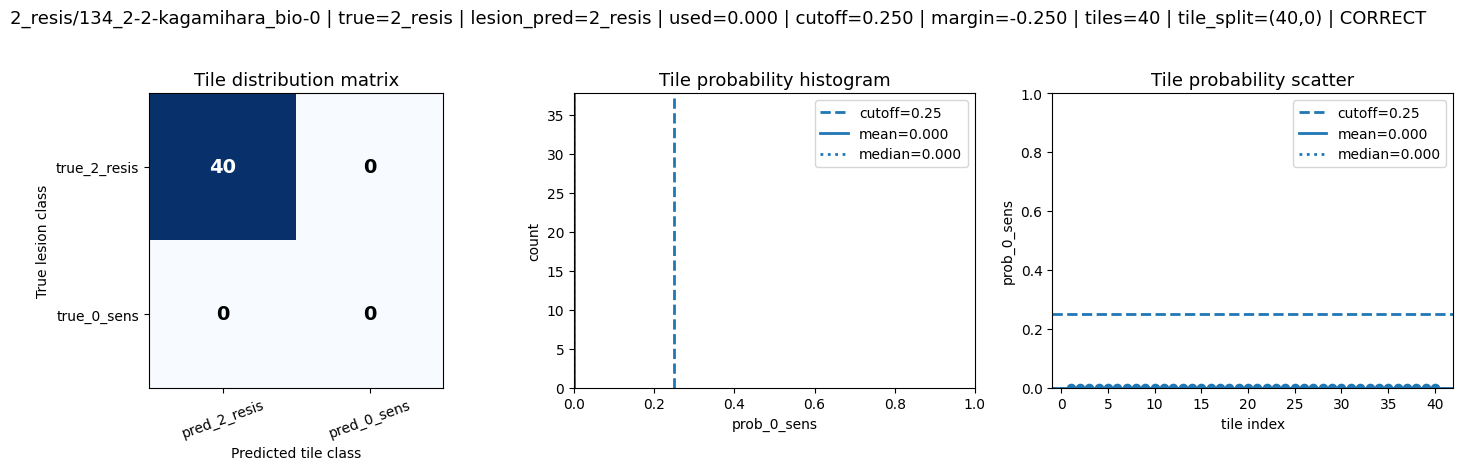

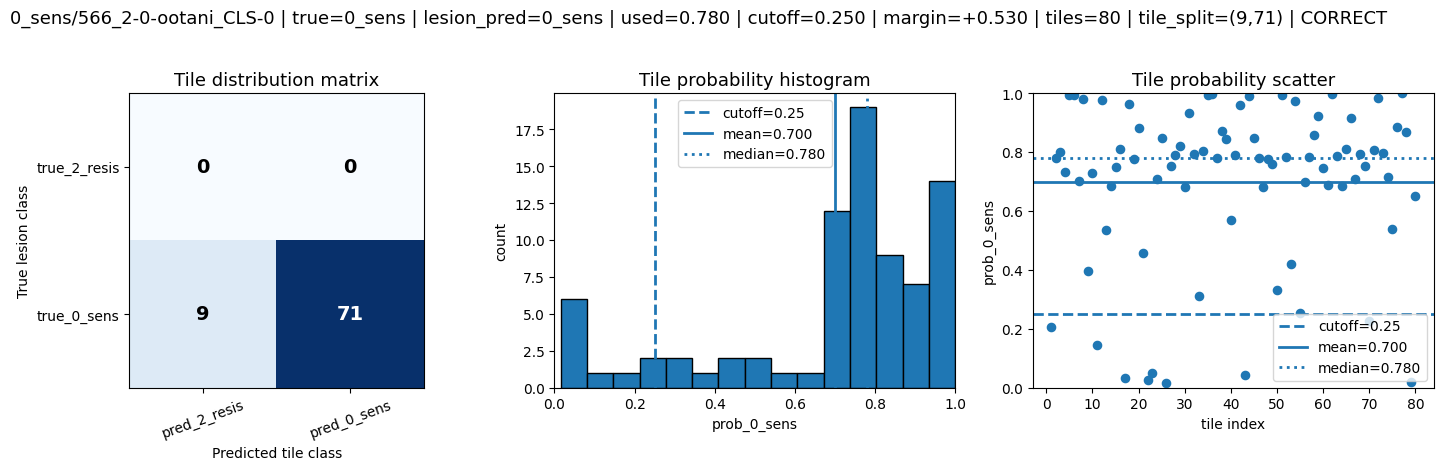

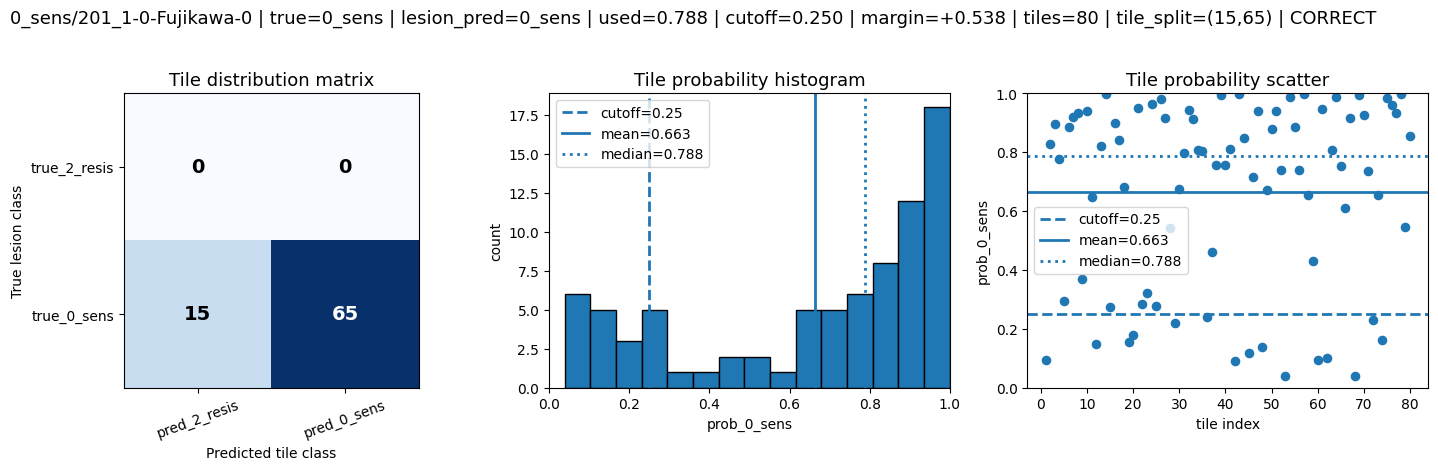

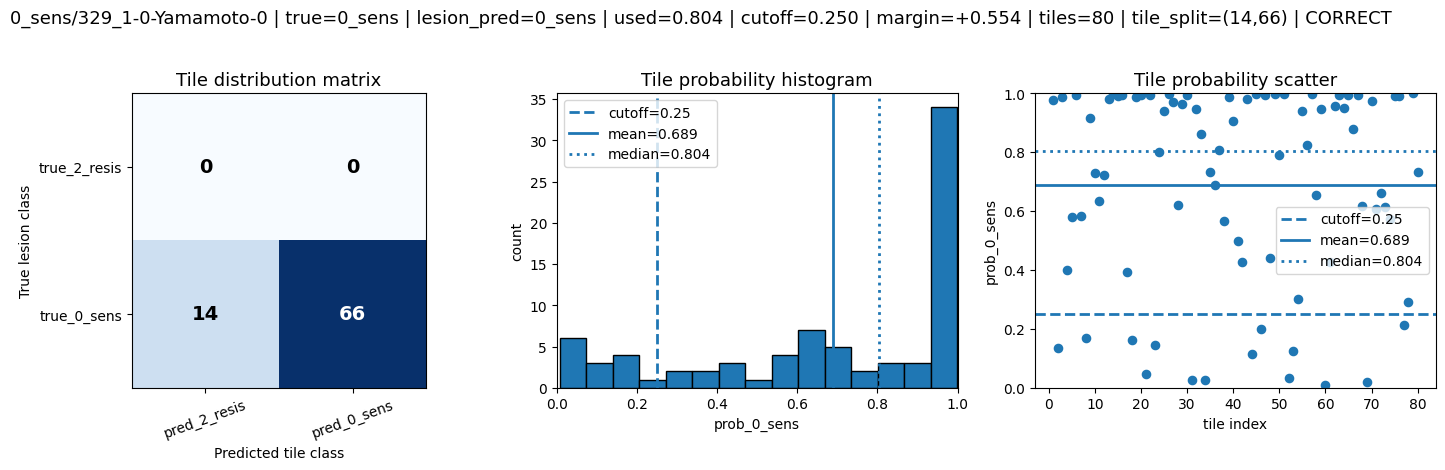

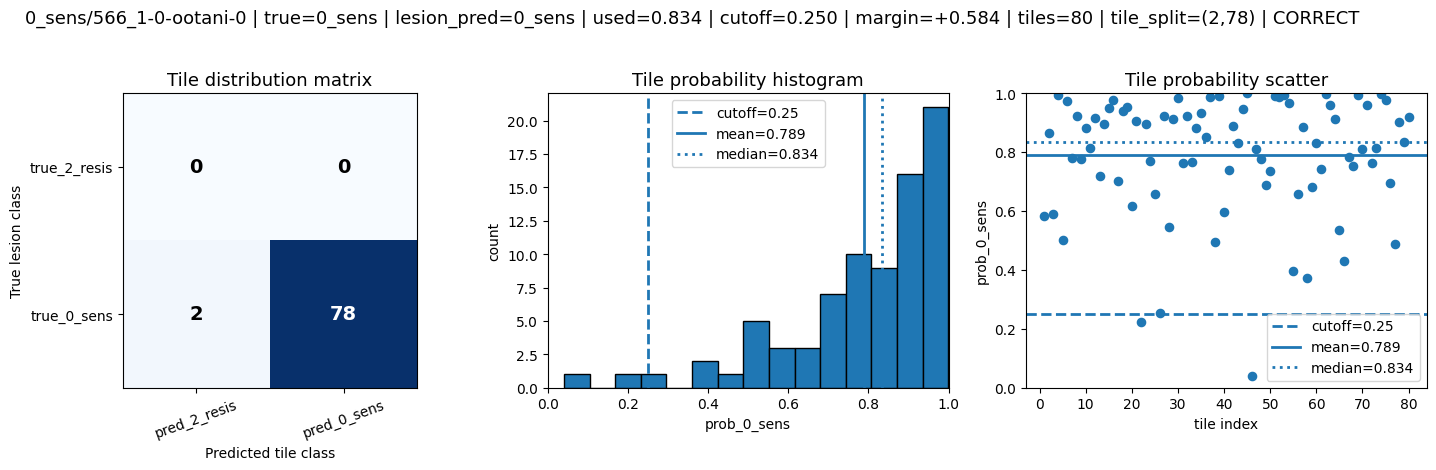

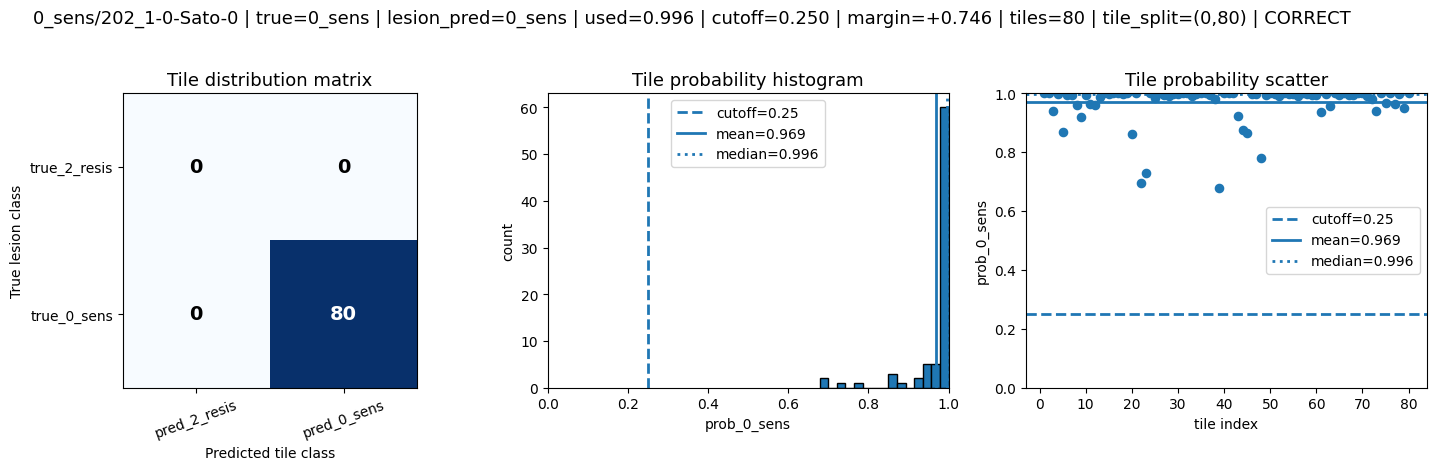

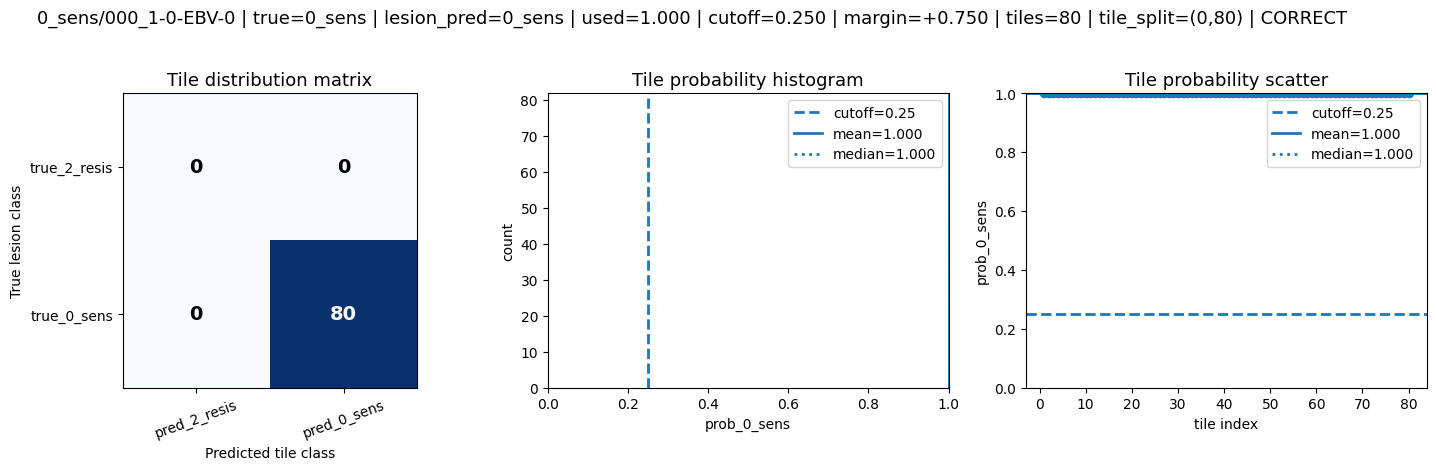


===== saved =====
excel   : /home/tatsushi/デスクトップ/cls_avg_result/vit_large_patch16_560.augreg_in21k_ft_in1k2026_hakuho-100seed-0.8weight/lesion_detail_view/lesion_detail_summary.xlsx
fig dir : /home/tatsushi/デスクトップ/cls_avg_result/vit_large_patch16_560.augreg_in21k_ft_in1k2026_hakuho-100seed-0.8weight/lesion_detail_view
===== found sheets =====
['summary', 'external_samples', 'single_tile', 'single_case_mean', 'single_case_median', 'ens_tile', 'ens_case_mean', 'ens_case_median', 'ensemble_members']

===== Wilson CI summary =====
       model_level  n_cases Accuracy [95% CI, Wilson] Recall_0_sens [95% CI, Wilson] Specificity_0_sens [95% CI, Wilson]  F1_0_sens (point estimate)
  single_case_mean       23       1.000 [0.857–1.000]            1.000 [0.610–1.000]                 1.000 [0.816–1.000]                    1.000000
single_case_median       23       0.957 [0.790–0.992]            0.833 [0.436–0.970]                 1.000 [0.816–1.000]                    0.909091
     ens_case_mean

In [2]:

    # エポック数
epoch_num = 40

    # 使用モデル

for i in range(2):
    #i = 0
    use_models = [
        #"caformer_b36.sail_in22k_ft_in1k_384",
        #"eva02_large_patch14_448.mim_in22k_ft_in22k",
        #"eva02_large_patch14_616.mim_in22k_ft_in22k_in1k",
        "eva02_large_patch14_560.mim_in22k_ft_in22k",
        #"eva02_large_patch14_616.mim_in22k_ft_in22k",
        #"eva02_large_patch14_384.mim_in22k_ft_in22k",
        #"eva02_large_patch14_448.mim_m38m_ft_in22k_in1k",
        #"vit_large_patch16_384.augreg_in21k_ft_in1k",
        #"vit_large_patch16_616.augreg_in21k_ft_in1k",
        #"vit_large_patch16_624.augreg_in21k_ft_in1k",
        "vit_large_patch16_560.augreg_in21k_ft_in1k",
        #"vit_intern300m_patch14_448.ogvl_2pt5",
        #"convnextv2_large.fcmae_ft_in22k_in1k_384",
        #"swinv2_large_window12to24_192to384.ms_in22k_ft_in1k", 
        #"eva02_large_patch14_518.mim_in22k_ft_in22k",
        #"eva02_large_patch14_504.mim_in22k_ft_in22k"
                       
        
    ]
    use_model = use_models[i]
    DIM_num = [1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024]   #[768,1024, 1024, 1024, 1024,1024,1024,1536,1536]
    DIM = DIM_num[i]
    cls_avg = "image"
    folder_name = use_models[i]+"2026_hakuho-100seed-0.8weight"
        




    ## このコードでは、epoch選択とtop5 seed選択はval_loss最小、cutoffは従来通りF1最大です。
    # _3-2-hepatoid を 0_sens -> class 100%, 2_resis -> external 100%
    # 5seed アンサンブル
    # 0_sens を陽性(class=1)として統一
    # best_epoch は val_loss 最小で決定
    # cutoff は従来通り validation set 上の f1_0_sens 最大で決定

    import os
    import random
    from pathlib import Path
    from collections import defaultdict
    import shutil

    import numpy as np
    import pandas as pd
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, Dataset
    from sklearn.metrics import (
        recall_score,
        f1_score,
        accuracy_score,
        confusion_matrix,
        precision_score,
    )

    # =========================
    # ハイパーパラメータ
    # =========================
    BATCH_SIZE = 32
    INPUT_DIM = DIM
    NUM_EPOCHS = 20
    PATIENCE = 5
    TOP_K_ENSEMBLE = 5

    train_roots = [
        (f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/mucosa/labeled", 1.0),
        (f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/mucosa/unlabeled", 0.8),
        (f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/mucosa/detekita", 1.0),
        (f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/mucosa/unknown", 0.8),
        (f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/mucosa/irregular", 0.8),
        (f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/mucosa/2026_hokuho",0.8),
        (f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/002_classes", 0.4),
        (f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/2026_classes", 0.4),
        (f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/web_jpg", 0.6),
        (f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/web_99", 0.6),
    ]

    val_roots = [
        f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/mucosa/sub_external",
        #f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/2026_classes",
        
    ]

    OUT_XLSX = f"/home/tatsushi/デスクトップ/cls_avg_result/{folder_name}/{use_model}/Vit_fixed_val_classes_top5_ensemble_0sens_positive.xlsx"
    MODEL_DIR = Path(f"/home/tatsushi/デスクトップ/cls_avg_result/{folder_name}/{use_model}/Vit_fixed_val_classes_models_0sens_positive")

    BEST_OVERALL_MODEL = MODEL_DIR / "best_overall_model.pth"
    ENSEMBLE_INFO_PATH = MODEL_DIR / "top5_ensemble_info.pth"

    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    Path(OUT_XLSX).parent.mkdir(parents=True, exist_ok=True)


    # =========================
    # 乱数固定
    # =========================
    def set_global_seed(seed: int = 42) -> None:
        os.environ["PYTHONHASHSEED"] = str(seed)
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

        random.seed(seed)
        np.random.seed(seed)

        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        torch.use_deterministic_algorithms(False)


    def seed_worker(worker_id: int, seed: int) -> None:
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
        torch.manual_seed(worker_seed)


    # =========================
    # サンプル収集
    # label_mapping:
    #   2_resis -> 0
    #   0_sens  -> 1
    # =========================
    def collect_samples_from_roots(root_dirs):
        label_mapping = {"2_resis": 0, "0_sens": 1}
        samples = []

        if isinstance(root_dirs, (str, Path)):
            root_dirs = [(root_dirs, 1.0)]

        for root_item in root_dirs:
            if isinstance(root_item, dict):
                root_dir = root_item["path"]
                root_weight = float(root_item.get("weight", 1.0))
            elif isinstance(root_item, (tuple, list)):
                root_dir = root_item[0]
                root_weight = float(root_item[1]) if len(root_item) > 1 else 1.0
            else:
                root_dir = root_item
                root_weight = 1.0

            root_dir = Path(root_dir)
            if not root_dir.exists():
                continue

            for cls_name, label in label_mapping.items():
                class_dir = root_dir / cls_name
                if not class_dir.exists():
                    continue

                for sub_dir in class_dir.iterdir():
                    if not sub_dir.is_dir():
                        continue

                    case_id = f"{cls_name}/{sub_dir.name}"

                    for pt_path in sub_dir.rglob("*.pt"):
                        samples.append({
                            "path": str(pt_path),
                            "label": label,
                            "class_name": cls_name,
                            "subfolder": sub_dir.name,
                            "case_id": case_id,
                            "root": str(root_dir),
                            "sample_weight": root_weight,
                        })

        return samples


    def get_case_ids(samples):
        return set(s["case_id"] for s in samples)


    # =========================
    # Dataset
    # =========================
    class FeatureDataset(Dataset):
        def __init__(self, samples, return_weight: bool = False):
            self.samples = samples
            self.return_weight = return_weight

        def __len__(self):
            return len(self.samples)

        def __getitem__(self, idx):
            item = self.samples[idx]
            feat = torch.load(item["path"]).float().squeeze(0)
            label = item["label"]

            if self.return_weight:
                weight = torch.tensor(item.get("sample_weight", 1.0), dtype=torch.float32)
                return feat, label, weight

            return feat, label


    # =========================
    # モデル
    # =========================
    class MLPClassifier(nn.Module):
        def __init__(self, in_dim: int, hidden_dim: int = 256, num_classes: int = 2):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, num_classes),
            )

        def forward(self, x):
            return self.net(x)


    # =========================
    # 学習
    # best_epoch = val_loss 最小
    # early stopping も val_loss 基準
    # =========================
    def train_and_evaluate(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        num_epochs=40,
        patience=5,
    ):
        best_wts = None
        best_epoch = 0
        best_val_acc = 0.0
        best_val_loss = float("inf")
        patience_cnt = 0

        history = []

        for epoch in range(1, num_epochs + 1):

            # ---- train
            model.train()
            train_loss_sum = 0.0
            train_weight_sum = 0.0
            train_corr = 0
            train_total = 0

            for feats, labels, weights in train_loader:
                feats = feats.to(device).squeeze(1)
                labels = labels.to(device)
                weights = weights.to(device)

                optimizer.zero_grad()

                out = model(feats)
                sample_losses = criterion(out, labels)
                loss = (sample_losses * weights).sum() / weights.sum().clamp_min(1e-8)
                preds = out.argmax(1)

                loss.backward()
                optimizer.step()

                train_loss_sum += (sample_losses.detach() * weights).sum().item()
                train_weight_sum += weights.sum().item()
                train_corr += (preds == labels).sum().item()
                train_total += feats.size(0)

            train_loss = train_loss_sum / train_weight_sum
            train_acc = train_corr / train_total

            # ---- val
            model.eval()
            val_loss_sum = 0.0
            val_corr = 0
            val_total = 0

            with torch.no_grad():
                for feats, labels in val_loader:
                    feats = feats.to(device).squeeze(1)
                    labels = labels.to(device)

                    out = model(feats)
                    sample_losses = criterion(out, labels)
                    preds = out.argmax(1)

                    val_loss_sum += sample_losses.sum().item()
                    val_corr += (preds == labels).sum().item()
                    val_total += feats.size(0)

            val_loss = val_loss_sum / val_total
            val_acc = val_corr / val_total

            history.append({
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
            })

            # =========================
            # best epoch = minimum val_loss
            # =========================
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                best_epoch = epoch
                patience_cnt = 0

                best_wts = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }
            else:
                patience_cnt += 1

            if patience_cnt >= patience:
                break

        if best_wts is not None:
            model.load_state_dict(best_wts)

        return model, best_epoch, best_val_acc, best_val_loss, history


    # =========================
    # 単一モデルの予測収集
    # class=1 = 0_sens の確率
    # =========================
    def collect_preds_from_loader(model, loader, device):
        y_true_all = []
        y_proba_all = []

        model.eval()

        with torch.no_grad():
            for feats, labels in loader:
                feats = feats.to(device).squeeze(1)

                out = model(feats)
                proba = torch.softmax(out, dim=1)[:, 1]

                y_true_all.extend(labels.numpy().tolist())
                y_proba_all.extend(proba.cpu().numpy().tolist())

        return np.array(y_true_all), np.array(y_proba_all)


    # =========================
    # 指標計算
    # 0_sens を陽性(class=1)として統一
    # =========================
    def calc_binary_metrics_0sens_positive(y_true, y_pred):
        acc = accuracy_score(y_true, y_pred)

        recall_0sens = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        precision_0sens = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1_0sens = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        specificity_0sens = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        return {
            "accuracy": acc,
            "recall_0_sens": recall_0sens,
            "specificity_0_sens": specificity_0sens,
            "precision_0_sens": precision_0sens,
            "f1_0_sens": f1_0sens,
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }


    # =========================
    # cutoff探索
    # score は 0_sens の F1
    # =========================
    def get_metrics_with_best_cutoff(y_true, y_proba):
        best_thr = 0.5
        best_score = -1.0
        best_metrics = None

        for thr in np.arange(0.2, 0.81, 0.05):
            y_pred = (y_proba >= thr).astype(int)

            metrics = calc_binary_metrics_0sens_positive(y_true, y_pred)
            score = metrics["f1_0_sens"]

            if score > best_score:
                best_score = score
                best_thr = thr
                best_metrics = metrics

        return (
            best_thr,
            best_metrics["accuracy"],
            best_metrics["recall_0_sens"],
            best_metrics["specificity_0_sens"],
            best_metrics["f1_0_sens"],
            best_score,
            best_metrics["precision_0_sens"],
            best_metrics["tn"],
            best_metrics["fp"],
            best_metrics["fn"],
            best_metrics["tp"],
        )


    # =========================
    # アンサンブル用
    # 複数モデルの 0_sens 確率を平均
    # =========================
    def collect_ensemble_preds_from_loader(models, loader, device):
        y_true_all = []
        y_proba_all = []

        for m in models:
            m.eval()

        with torch.no_grad():
            for feats, labels in loader:
                feats = feats.to(device).squeeze(1)

                prob_list = []

                for model in models:
                    out = model(feats)
                    proba = torch.softmax(out, dim=1)[:, 1]
                    prob_list.append(proba.unsqueeze(1))

                prob_stack = torch.cat(prob_list, dim=1)
                mean_prob = prob_stack.mean(dim=1)

                y_true_all.extend(labels.numpy().tolist())
                y_proba_all.extend(mean_prob.cpu().numpy().tolist())

        return np.array(y_true_all), np.array(y_proba_all)


    # =========================
    # main
    # =========================
    def main():
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # ---- val固定データ収集
        val_samples = collect_samples_from_roots(val_roots)
        val_case_ids = get_case_ids(val_samples)

        # ---- train候補収集
        train_samples_all = collect_samples_from_roots(train_roots)
        train_case_ids_all = get_case_ids(train_samples_all)

        # ---- train と val の重複caseを除外
        overlap_case_ids = train_case_ids_all & val_case_ids
        filtered_train_samples = [
            s for s in train_samples_all
            if s["case_id"] not in overlap_case_ids
        ]

        print(f"val .pt files          : {len(val_samples)}")
        print(f"val case_ids           : {len(val_case_ids)}")
        print(f"train candidate .pt    : {len(train_samples_all)}")
        print(f"train candidate cases  : {len(train_case_ids_all)}")
        print(f"overlap case_ids       : {len(overlap_case_ids)}")
        print(f"filtered train .pt     : {len(filtered_train_samples)}")
        print(f"filtered train case_ids: {len(get_case_ids(filtered_train_samples))}")

        if len(filtered_train_samples) == 0:
            raise ValueError("filtered_train_samples が 0 件です。")

        if len(val_samples) == 0:
            raise ValueError("val_samples が 0 件です。")

        train_ds = FeatureDataset(filtered_train_samples, return_weight=True)
        val_ds = FeatureDataset(val_samples)

        results = []
        all_histories = []

        overall_best_score = -1.0
        overall_best_seed = None
        overall_best_model_path = None

        val_loader = DataLoader(
            val_ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
        )

        # =========================
        # 単一 seed 学習
        # =========================
        for seed in range(1, epoch_num + 1):
            set_global_seed(seed)

            def worker_init_fn(worker_id):
                seed_worker(worker_id, seed)

            g_train = torch.Generator()
            g_train.manual_seed(seed)

            train_loader = DataLoader(
                train_ds,
                batch_size=BATCH_SIZE,
                shuffle=True,
                num_workers=0,
                worker_init_fn=worker_init_fn,
                generator=g_train,
            )

            model = MLPClassifier(in_dim=INPUT_DIM).to(device)

            criterion = nn.CrossEntropyLoss(reduction="none")
            optimizer = optim.Adam(model.parameters(), lr=0.001)

            model, best_epoch, best_val_acc, best_val_loss, history = train_and_evaluate(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                criterion=criterion,
                optimizer=optimizer,
                device=device,
                num_epochs=NUM_EPOCHS,
                patience=PATIENCE,
            )

            # ---- best model loaded 後に cutoff探索
            y_true_val, y_proba_val = collect_preds_from_loader(model, val_loader, device)

            (
                best_thr,
                best_acc,
                best_recall_0sens,
                best_spec_0sens,
                best_f1_0sens,
                best_score,
                best_precision_0sens,
                tn,
                fp,
                fn,
                tp,
            ) = get_metrics_with_best_cutoff(y_true_val, y_proba_val)

            # ---- 各seedのbest model保存
            model_path = MODEL_DIR / f"seed_{seed:03d}_best_model.pth"

            torch.save({
                "seed": seed,
                "model_state_dict": model.state_dict(),
                "input_dim": INPUT_DIM,
                "best_epoch": best_epoch,
                "best_val_acc": best_val_acc,
                "best_val_loss": best_val_loss,
                "best_cutoff": best_thr,
                "best_score": best_score,
                "metric_name": "f1_0_sens_for_cutoff",
                "best_epoch_selection": "minimum_val_loss",
                "positive_class": "0_sens",
                "label_mapping": {"2_resis": 0, "0_sens": 1},
                "train_roots": train_roots,
                "train_root_weights": {str(Path(root)): float(weight) for root, weight in train_roots},
                "val_roots": val_roots,
            }, model_path)

            results.append({
                "SEED": seed,
                "best_epoch": best_epoch,
                "best_val_acc_epoch": best_val_acc,
                "best_val_loss_epoch": best_val_loss,
                "best_cutoff": best_thr,
                "val_acc_at_best_cutoff": best_acc,
                "val_recall_0_sens": best_recall_0sens,
                "val_specificity_0_sens": best_spec_0sens,
                "val_precision_0_sens": best_precision_0sens,
                "val_f1_0_sens": best_f1_0sens,
                "val_score": best_score,
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp,
                "model_path": str(model_path),
                "train_pts": len(filtered_train_samples),
                "val_pts": len(val_samples),
                "train_case_ids": len(get_case_ids(filtered_train_samples)),
                "val_case_ids": len(val_case_ids),
            })

            for h in history:
                all_histories.append({
                    "SEED": seed,
                    **h,
                })

            print(
                f"SEED {seed:3d}: "
                f"best_epoch={best_epoch:2d}, "
                f"best_val_loss(epoch)={best_val_loss:.4f}, "
                f"best_val_acc(epoch)={best_val_acc:.4f}, "
                f"best_cutoff={best_thr:.2f}, "
                f"val_acc={best_acc:.4f}, "
                f"recall_0_sens={best_recall_0sens:.4f}, "
                f"specificity_0_sens={best_spec_0sens:.4f}, "
                f"precision_0_sens={best_precision_0sens:.4f}, "
                f"f1_0_sens={best_f1_0sens:.4f}, "
                f"score={best_score:.4f}"
            )

            # 単独ベストモデルは従来通り val_score = f1_0_sens 最大で選ぶ
            if best_score > overall_best_score:
                overall_best_score = best_score
                overall_best_seed = seed
                overall_best_model_path = model_path

        # ---- 最良単独モデルをコピー
        if overall_best_model_path is not None:
            shutil.copy2(overall_best_model_path, BEST_OVERALL_MODEL)

        # =========================
        # 上位5 seed アンサンブル
        # =========================
        df_results = (
            pd.DataFrame(results)
            .sort_values("best_val_loss_epoch", ascending=True)
            .reset_index(drop=True)
        )

        topk_df = df_results.head(TOP_K_ENSEMBLE).copy()

        topk_seeds = topk_df["SEED"].tolist()
        topk_model_paths = topk_df["model_path"].tolist()

        print("\n===== Top5 seeds for ensemble =====")
        print(topk_df[[
            "SEED",
            "best_epoch",
            "best_cutoff",
            "best_val_loss_epoch",
            "best_val_acc_epoch",
            "val_recall_0_sens",
            "val_specificity_0_sens",
            "val_f1_0_sens",
            "val_score",
        ]].to_string(index=False))

        ensemble_models = []

        for _, row in topk_df.iterrows():
            ckpt = torch.load(row["model_path"], map_location="cpu", weights_only=False)

            model = MLPClassifier(in_dim=ckpt["input_dim"]).to(device)
            model.load_state_dict(ckpt["model_state_dict"])
            model.eval()

            ensemble_models.append(model)

        # ---- 平均確率で val 予測
        y_true_ens, y_proba_ens = collect_ensemble_preds_from_loader(
            ensemble_models,
            val_loader,
            device,
        )

        (
            ens_thr,
            ens_acc,
            ens_recall_0sens,
            ens_spec_0sens,
            ens_f1_0sens,
            ens_score,
            ens_precision_0sens,
            ens_tn,
            ens_fp,
            ens_fn,
            ens_tp,
        ) = get_metrics_with_best_cutoff(y_true_ens, y_proba_ens)

        ensemble_row = {
            "ensemble_name": f"top{TOP_K_ENSEMBLE}_mean_prob",
            "topk_seeds": ",".join(map(str, topk_seeds)),
            "topk_model_paths": " | ".join(topk_model_paths),
            "ensemble_best_cutoff": ens_thr,
            "val_acc_at_best_cutoff": ens_acc,
            "val_recall_0_sens": ens_recall_0sens,
            "val_specificity_0_sens": ens_spec_0sens,
            "val_precision_0_sens": ens_precision_0sens,
            "val_f1_0_sens": ens_f1_0sens,
            "val_score": ens_score,
            "tn": ens_tn,
            "fp": ens_fp,
            "fn": ens_fn,
            "tp": ens_tp,
            "n_models": len(ensemble_models),
            "train_pts": len(filtered_train_samples),
            "val_pts": len(val_samples),
            "train_case_ids": len(get_case_ids(filtered_train_samples)),
            "val_case_ids": len(val_case_ids),
        }

        print("\n===== Top5 ensemble result on VAL =====")
        print(
            f"topk_seeds={topk_seeds}, "
            f"best_cutoff={ens_thr:.2f}, "
            f"val_acc={ens_acc:.4f}, "
            f"recall_0_sens={ens_recall_0sens:.4f}, "
            f"specificity_0_sens={ens_spec_0sens:.4f}, "
            f"precision_0_sens={ens_precision_0sens:.4f}, "
            f"f1_0_sens={ens_f1_0sens:.4f}, "
            f"score={ens_score:.4f}"
        )

        # ---- アンサンブル情報保存
        torch.save({
            "ensemble_name": f"top{TOP_K_ENSEMBLE}_mean_prob",
            "topk_seeds": topk_seeds,
            "topk_model_paths": topk_model_paths,
            "ensemble_best_cutoff": ens_thr,
            "val_score": ens_score,
            "metric_name": "topk_seed_selection_by_minimum_val_loss",
            "cutoff_metric_name": "f1_0_sens_for_cutoff",
            "best_epoch_selection": "minimum_val_loss",
            "positive_class": "0_sens",
            "label_mapping": {"2_resis": 0, "0_sens": 1},
            "train_roots": train_roots,
            "train_root_weights": {str(Path(root)): float(weight) for root, weight in train_roots},
            "val_roots": val_roots,
        }, ENSEMBLE_INFO_PATH)

        # ---- Excel出力
        df_history = pd.DataFrame(all_histories)
        df_ensemble = pd.DataFrame([ensemble_row])

        with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
            df_results.to_excel(writer, sheet_name="summary", index=False)
            df_history.to_excel(writer, sheet_name="history", index=False)
            df_ensemble.to_excel(writer, sheet_name="ensemble_top5", index=False)
            topk_df.to_excel(writer, sheet_name="top5_members", index=False)

        print("\n===== 全体ベスト（単独） =====")
        print(f"best seed        : {overall_best_seed}")
        print(f"best val score   : {overall_best_score:.4f}")
        print(f"best model path  : {BEST_OVERALL_MODEL}")
        print(f"ensemble info    : {ENSEMBLE_INFO_PATH}")
        print(f"excel path       : {OUT_XLSX}")


    if __name__ == "__main__":
        main()

    ##########################################################################################################################
    ##########################################################################################################################

    #!/usr/bin/env python3
    # -*- coding: utf-8 -*-

    """
    固定valで決めた
    - best_overall_model.pth
    - top5_ensemble_info.pth
    を使って、完全隔離 external データを評価するコード

    学習コードに完全準拠:
    - MLPClassifier(in_dim=1024, hidden_dim=256, num_classes=2)
    - class=1 が 0_sens の確率
    - label mapping:
        2_resis -> 0
        0_sens  -> 1

    評価内容:
    - tile-level
    - case-level mean
    - case-level median

    評価指標は 0_sens を陽性(class=1)として統一:
    - recall_0_sens
    - specificity_0_sens
    - precision_0_sens
    - f1_0_sens

    保存:
    - Excel
    - CSV
    """

    import os
    from pathlib import Path

    import numpy as np
    import pandas as pd
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    from sklearn.metrics import (
        accuracy_score,
        recall_score,
        f1_score,
        confusion_matrix,
        precision_score,
    )


    # =========================
    # 設定
    # =========================
    EXTERNAL_ROOT = Path(
        f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/mucosa/external",
        #f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/mucosa/2026_hokuho",
    )
    MODEL_DIR = Path(f"/home/tatsushi/デスクトップ/cls_avg_result/{folder_name}/{use_model}/Vit_fixed_val_classes_models_0sens_positive") 
    BEST_MODEL_PATH = MODEL_DIR / "best_overall_model.pth"
    ENSEMBLE_INFO_PATH = MODEL_DIR / "top5_ensemble_info.pth"

    OUT_DIR = Path(f"/home/tatsushi/デスクトップ/cls_avg_result/{folder_name}/{use_model}/external_eval")
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    OUT_XLSX = OUT_DIR / "sub_external_eval_result_0sens_positive.xlsx"
    OUT_CSV = OUT_DIR / "sub_external_eval_summary_0sens_positive.csv"

    INPUT_DIM = DIM
    BATCH_SIZE = 32
    NUM_WORKERS = 0

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


    # =========================
    # label mapping
    # =========================
    LABEL_MAPPING = {
        "2_resis": 0,
        "0_sens": 1,
    }


    # =========================
    # torch.load helper
    # =========================
    def torch_load_safe(path, map_location="cpu"):
        return torch.load(path, map_location=map_location, weights_only=False)


    # =========================
    # external サンプル収集
    # 学習コードに合わせる:
    # case_id = "class/subfolder"
    # =========================
    def collect_samples_from_root(root_dir):
        samples = []
        root_dir = Path(root_dir)

        if not root_dir.exists():
            raise FileNotFoundError(f"external root not found: {root_dir}")

        for cls_name, label in LABEL_MAPPING.items():
            class_dir = root_dir / cls_name
            if not class_dir.exists():
                print(f"[WARNING] class folder not found: {class_dir}")
                continue

            for sub_dir in class_dir.iterdir():
                if not sub_dir.is_dir():
                    continue

                case_id = f"{cls_name}/{sub_dir.name}"

                for pt_path in sub_dir.rglob("*.pt"):
                    samples.append({
                        "path": str(pt_path),
                        "label": label,
                        "class_name": cls_name,
                        "subfolder": sub_dir.name,
                        "case_id": case_id,
                        "root": str(root_dir),
                    })

        return samples


    def get_case_ids(samples):
        return set(s["case_id"] for s in samples)


    # =========================
    # Dataset
    # =========================
    class FeatureDataset(Dataset):
        def __init__(self, samples):
            self.samples = samples

        def __len__(self):
            return len(self.samples)

        def __getitem__(self, idx):
            item = self.samples[idx]
            feat = torch_load_safe(item["path"], map_location="cpu").float().squeeze(0)
            label = item["label"]
            case_id = item["case_id"]
            path = item["path"]
            class_name = item["class_name"]
            subfolder = item["subfolder"]
            return feat, label, case_id, path, class_name, subfolder


    # =========================
    # モデル
    # 学習コードと同一
    # =========================
    class MLPClassifier(nn.Module):
        def __init__(self, in_dim: int, hidden_dim: int = 256, num_classes: int = 2):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, num_classes)
            )

        def forward(self, x):
            return self.net(x)


    # =========================
    # 単独モデル予測
    # class=1 = 0_sens の確率
    # =========================
    @torch.no_grad()
    def collect_preds_from_loader(model, loader, device):
        rows = []

        model.eval()
        for feats, labels, case_ids, paths, class_names, subfolders in loader:
            feats = feats.to(device).squeeze(1)

            out = model(feats)
            proba_1 = torch.softmax(out, dim=1)[:, 1]   # class=1 = 0_sens

            pred_prob = proba_1.cpu().numpy()

            for i in range(len(labels)):
                rows.append({
                    "path": paths[i],
                    "case_id": case_ids[i],
                    "class_name": class_names[i],
                    "subfolder": subfolders[i],
                    "label": int(labels[i].item()),
                    "prob_1_0sens": float(pred_prob[i]),
                })

        return pd.DataFrame(rows)


    # =========================
    # ensemble 予測
    # class=1 = 0_sens の確率を平均
    # =========================
    @torch.no_grad()
    def collect_ensemble_preds_from_loader(models, loader, device):
        rows = []

        for m in models:
            m.eval()

        for feats, labels, case_ids, paths, class_names, subfolders in loader:
            feats = feats.to(device).squeeze(1)

            prob_list = []
            for model in models:
                out = model(feats)
                proba = torch.softmax(out, dim=1)[:, 1]   # class=1 = 0_sens
                prob_list.append(proba.unsqueeze(1))

            prob_stack = torch.cat(prob_list, dim=1)      # [B, n_models]
            mean_prob = prob_stack.mean(dim=1).cpu().numpy()

            for i in range(len(labels)):
                rows.append({
                    "path": paths[i],
                    "case_id": case_ids[i],
                    "class_name": class_names[i],
                    "subfolder": subfolders[i],
                    "label": int(labels[i].item()),
                    "prob_1_0sens": float(mean_prob[i]),
                })

        return pd.DataFrame(rows)


    # =========================
    # cutoff 適用
    # y_pred = 1 -> 0_sens
    # y_pred = 0 -> 2_resis
    # =========================
    def apply_cutoff(df_pred, cutoff):
        df = df_pred.copy()
        df["pred"] = (df["prob_1_0sens"] >= cutoff).astype(int)
        return df


    # =========================
    # metrics
    # 0_sens を陽性(class=1)として統一
    # =========================
    def calc_metrics(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)

        acc = accuracy_score(y_true, y_pred)

        # 0_sens を陽性(class=1)として計算
        recall_0_sens = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        precision_0_sens = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1_0_sens = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

        # confusion matrix: rows=true [0,1], cols=pred [0,1]
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        # 0_sens に対する specificity = TN / (TN + FP)
        specificity_0_sens = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        return {
            "acc": acc,
            "recall_0_sens": recall_0_sens,
            "specificity_0_sens": specificity_0_sens,
            "precision_0_sens": precision_0_sens,
            "f1_0_sens": f1_0_sens,
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }


    # =========================
    # case-level 集約
    # prob_1_0sens を mean / median
    # =========================
    def aggregate_case_level(df_pred, cutoff=0.5, method="mean"):
        rows = []

        for case_id, g in df_pred.groupby("case_id"):
            label = int(g["label"].iloc[0])

            if method == "mean":
                prob = float(g["prob_1_0sens"].mean())
            elif method == "median":
                prob = float(g["prob_1_0sens"].median())
            else:
                raise ValueError("method must be 'mean' or 'median'")

            pred = int(prob >= cutoff)

            rows.append({
                "case_id": case_id,
                "class_name": g["class_name"].iloc[0],
                "subfolder": g["subfolder"].iloc[0],
                "label": label,
                "prob_1_0sens": prob,
                "pred": pred,
                "n_tiles": len(g),
            })

        return pd.DataFrame(rows)


    # =========================
    # model load
    # =========================
    def load_single_best_model(best_model_path, device):
        ckpt = torch_load_safe(best_model_path, map_location="cpu")

        model = MLPClassifier(in_dim=ckpt["input_dim"]).to(device)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        info = {
            "seed": ckpt.get("seed"),
            "best_epoch": ckpt.get("best_epoch"),
            "best_val_acc": ckpt.get("best_val_acc"),
            "best_val_loss": ckpt.get("best_val_loss"),
            "best_cutoff": ckpt.get("best_cutoff", 0.5),
            "best_score": ckpt.get("best_score"),
            "metric_name": ckpt.get("metric_name", "f1_0_sens"),
            "positive_class": ckpt.get("positive_class", "0_sens"),
            "model_path": str(best_model_path),
        }
        return model, info


    def load_ensemble_models(ensemble_info_path, device):
        info = torch_load_safe(ensemble_info_path, map_location="cpu")

        topk_seeds = info["topk_seeds"]
        topk_model_paths = info["topk_model_paths"]
        ensemble_best_cutoff = info["ensemble_best_cutoff"]

        models = []
        members = []

        for model_path in topk_model_paths:
            ckpt = torch_load_safe(model_path, map_location="cpu")
            model = MLPClassifier(in_dim=ckpt["input_dim"]).to(device)
            model.load_state_dict(ckpt["model_state_dict"])
            model.eval()
            models.append(model)

            members.append({
                "seed": ckpt.get("seed"),
                "best_epoch": ckpt.get("best_epoch"),
                "best_cutoff": ckpt.get("best_cutoff"),
                "best_score": ckpt.get("best_score"),
                "metric_name": ckpt.get("metric_name", "f1_0_sens"),
                "positive_class": ckpt.get("positive_class", "0_sens"),
                "model_path": str(model_path),
            })

        ens_info = {
            "topk_seeds": topk_seeds,
            "topk_model_paths": topk_model_paths,
            "ensemble_best_cutoff": ensemble_best_cutoff,
            "metric_name": info.get("metric_name", "f1_0_sens"),
            "positive_class": info.get("positive_class", "0_sens"),
            "members": members,
        }
        return models, ens_info


    # =========================
    # summary 行追加
    # =========================
    def add_summary_row(summary_rows, model_name, level_name, cutoff, metrics):
        summary_rows.append({
            "model": model_name,
            "level": level_name,
            "cutoff": cutoff,
            "acc": metrics["acc"],
            "recall_0_sens": metrics["recall_0_sens"],
            "specificity_0_sens": metrics["specificity_0_sens"],
            "precision_0_sens": metrics["precision_0_sens"],
            "f1_0_sens": metrics["f1_0_sens"],
            "tn": metrics["tn"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
            "tp": metrics["tp"],
        })


    # =========================
    # main
    # =========================
    def main():
        print("===== collect external samples =====")
        ext_samples = collect_samples_from_root(EXTERNAL_ROOT)

        if len(ext_samples) == 0:
            raise ValueError("external samples が 0 件です。フォルダ構造を確認してください。")

        print(f"external .pt files : {len(ext_samples)}")
        print(f"external case_ids  : {len(get_case_ids(ext_samples))}")

        df_ext_info = pd.DataFrame(ext_samples)
        if len(df_ext_info) > 0:
            print("\n[class count]")
            print(df_ext_info["class_name"].value_counts().to_string())
            print("\n[label count]")
            print(df_ext_info["label"].value_counts().sort_index().to_string())

        ext_ds = FeatureDataset(ext_samples)
        ext_loader = DataLoader(
            ext_ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS
        )

        summary_rows = []

        # -------------------------------------------------
        # 単独ベストモデル
        # -------------------------------------------------
        print("\n===== single best model =====")
        single_model, single_info = load_single_best_model(BEST_MODEL_PATH, DEVICE)
        print(single_info)

        df_single_tile = collect_preds_from_loader(single_model, ext_loader, DEVICE)
        df_single_tile = apply_cutoff(df_single_tile, single_info["best_cutoff"])

        single_tile_metrics = calc_metrics(df_single_tile["label"], df_single_tile["pred"])
        print("\n[single best] TILE-level")
        print(single_tile_metrics)

        df_single_case_mean = aggregate_case_level(
            df_single_tile,
            cutoff=single_info["best_cutoff"],
            method="mean"
        )
        single_case_mean_metrics = calc_metrics(
            df_single_case_mean["label"],
            df_single_case_mean["pred"]
        )
        print("\n[single best] CASE-level mean")
        print(single_case_mean_metrics)

        df_single_case_median = aggregate_case_level(
            df_single_tile,
            cutoff=single_info["best_cutoff"],
            method="median"
        )
        single_case_median_metrics = calc_metrics(
            df_single_case_median["label"],
            df_single_case_median["pred"]
        )
        print("\n[single best] CASE-level median")
        print(single_case_median_metrics)

        add_summary_row(summary_rows, "single_best", "tile", single_info["best_cutoff"], single_tile_metrics)
        add_summary_row(summary_rows, "single_best", "case_mean", single_info["best_cutoff"], single_case_mean_metrics)
        add_summary_row(summary_rows, "single_best", "case_median", single_info["best_cutoff"], single_case_median_metrics)

        # -------------------------------------------------
        # Top5 ensemble
        # -------------------------------------------------
        print("\n===== top5 ensemble =====")
        ens_models, ens_info = load_ensemble_models(ENSEMBLE_INFO_PATH, DEVICE)
        print({
            "topk_seeds": ens_info["topk_seeds"],
            "ensemble_best_cutoff": ens_info["ensemble_best_cutoff"],
            "metric_name": ens_info["metric_name"],
            "positive_class": ens_info["positive_class"],
        })

        df_ens_tile = collect_ensemble_preds_from_loader(ens_models, ext_loader, DEVICE)
        df_ens_tile = apply_cutoff(df_ens_tile, ens_info["ensemble_best_cutoff"])

        ens_tile_metrics = calc_metrics(df_ens_tile["label"], df_ens_tile["pred"])
        print("\n[ensemble] TILE-level")
        print(ens_tile_metrics)

        df_ens_case_mean = aggregate_case_level(
            df_ens_tile,
            cutoff=ens_info["ensemble_best_cutoff"],
            method="mean"
        )
        ens_case_mean_metrics = calc_metrics(
            df_ens_case_mean["label"],
            df_ens_case_mean["pred"]
        )
        print("\n[ensemble] CASE-level mean")
        print(ens_case_mean_metrics)

        df_ens_case_median = aggregate_case_level(
            df_ens_tile,
            cutoff=ens_info["ensemble_best_cutoff"],
            method="median"
        )
        ens_case_median_metrics = calc_metrics(
            df_ens_case_median["label"],
            df_ens_case_median["pred"]
        )
        print("\n[ensemble] CASE-level median")
        print(ens_case_median_metrics)

        add_summary_row(summary_rows, "top5_ensemble", "tile", ens_info["ensemble_best_cutoff"], ens_tile_metrics)
        add_summary_row(summary_rows, "top5_ensemble", "case_mean", ens_info["ensemble_best_cutoff"], ens_case_mean_metrics)
        add_summary_row(summary_rows, "top5_ensemble", "case_median", ens_info["ensemble_best_cutoff"], ens_case_median_metrics)

        # -------------------------------------------------
        # 保存
        # -------------------------------------------------
        df_summary = pd.DataFrame(summary_rows)
        df_ensemble_members = pd.DataFrame(ens_info["members"])

        with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
            df_summary.to_excel(writer, sheet_name="summary", index=False)

            df_ext_info.to_excel(writer, sheet_name="external_samples", index=False)

            df_single_tile.to_excel(writer, sheet_name="single_tile", index=False)
            df_single_case_mean.to_excel(writer, sheet_name="single_case_mean", index=False)
            df_single_case_median.to_excel(writer, sheet_name="single_case_median", index=False)

            df_ens_tile.to_excel(writer, sheet_name="ens_tile", index=False)
            df_ens_case_mean.to_excel(writer, sheet_name="ens_case_mean", index=False)
            df_ens_case_median.to_excel(writer, sheet_name="ens_case_median", index=False)

            df_ensemble_members.to_excel(writer, sheet_name="ensemble_members", index=False)

        df_summary.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

        print("\n===== saved =====")
        print(f"excel : {OUT_XLSX}")
        print(f"csv   : {OUT_CSV}")


    if __name__ == "__main__":
        main()
    ############################################################################################################################
    ############################################################################################################################
    # =========================================================
    # Jupyter Notebook 1セル版フルコード
    # 保存済み top5 ensemble モデルを読み込み、
    # image_feature/0_sens/lesion1/image1.pt
    # のような構造の特徴量フォルダを評価して、
    #
    # 1) lesion最終判定の一覧
    # 2) lesionごとのタイル分布行列 [[a,b],[c,d]]
    # 3) 全lesionの最終判定混同行列
    # 4) 各lesionの詳細可視化
    #    - タイル分布行列
    #    - 確率ヒストグラム
    #    - 確率散布図
    #
    # をNotebook上で表示する
    # =========================================================

    import os
    from pathlib import Path

    import numpy as np
    import pandas as pd
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader

    from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

    import matplotlib.pyplot as plt
    from IPython.display import display

    # =========================================================
    # 設定
    # =========================================================
    EVAL_ROOTS = [
        # 必要なら追加
        f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/mucosa/external",
        #f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/mucosa/2026_hokuho",
        #f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature/{use_model}/2026_classes",
        #f"/home/tatsushi/デスクトップ/胃癌取り扱い規約trimming/{cls_avg}-feature/{use_model}"
    ]

    ENSEMBLE_INFO_PATH = f"/home/tatsushi/デスクトップ/cls_avg_result/{folder_name}/{use_model}/Vit_fixed_val_classes_models_0sens_positive/top5_ensemble_info.pth"

    OUT_DIR = Path(f"/home/tatsushi/デスクトップ/cls_avg_result/{folder_name}/lesion_detail_view")
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    OUT_XLSX = OUT_DIR / "lesion_detail_summary.xlsx"

    BATCH_SIZE = 64

    # lesion最終判定の集約方法: "mean" or "median"
    LESION_AGG = "median"   ###############################################################

    # 保存済みcutoffを使うか
    USE_SAVED_CUTOFF = True
    MANUAL_CUTOFF = 0.50

    # Notebookで自動表示する最大症例数
    DISPLAY_MAX_LESIONS = 50

    # 自動表示順
    # "wrong_first" : 誤判定優先→cutoff近傍順
    # "border_first": cutoff近傍順
    DISPLAY_ORDER = "wrong_first"

    # 特定症例だけ表示したい場合は case_id を入れる
    # 例: "0_sens/lesion1"
    TARGET_CASE_ID = None


    # =========================================================
    # モデル
    # =========================================================
    class MLPClassifier(nn.Module):
        def __init__(self, in_dim: int, hidden_dim: int = 256, num_classes: int = 2):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, num_classes)
            )

        def forward(self, x):
            return self.net(x)


    # =========================================================
    # データ収集
    # =========================================================
    def collect_samples_from_roots(root_dirs):
        label_mapping = {"2_resis": 0, "0_sens": 1}
        samples = []

        if isinstance(root_dirs, (str, Path)):
            root_dirs = [root_dirs]

        for root_dir in root_dirs:
            root_dir = Path(root_dir)
            if not root_dir.exists():
                print(f"[warning] root not found: {root_dir}")
                continue

            for cls_name, label in label_mapping.items():
                class_dir = root_dir / cls_name
                if not class_dir.exists():
                    continue

                for sub_dir in class_dir.iterdir():
                    if not sub_dir.is_dir():
                        continue

                    case_id = f"{cls_name}/{sub_dir.name}"

                    for pt_path in sub_dir.rglob("*.pt"):
                        samples.append({
                            "path": str(pt_path),
                            "label": label,
                            "class_name": cls_name,
                            "subfolder": sub_dir.name,
                            "case_id": case_id,
                            "root": str(root_dir),
                        })

        return samples


    # =========================================================
    # Dataset
    # =========================================================
    class FeatureDatasetWithMeta(Dataset):
        def __init__(self, samples):
            self.samples = samples

        def __len__(self):
            return len(self.samples)

        def __getitem__(self, idx):
            item = self.samples[idx]
            feat = torch.load(item["path"], map_location="cpu")
            if isinstance(feat, np.ndarray):
                feat = torch.from_numpy(feat)
            feat = feat.float().squeeze(0)

            return {
                "feat": feat,
                "label": item["label"],
                "class_name": item["class_name"],
                "subfolder": item["subfolder"],
                "case_id": item["case_id"],
                "path": item["path"],
                "root": item["root"],
            }


    # =========================================================
    # ensemble読み込み
    # =========================================================
    def load_ensemble_models(ensemble_info_path, device):
        info = torch.load(ensemble_info_path, map_location="cpu", weights_only=False)

        model_paths = info["topk_model_paths"]
        cutoff = info.get("ensemble_best_cutoff", 0.5)

        models = []
        for model_path in model_paths:
            ckpt = torch.load(model_path, map_location="cpu", weights_only=False)
            in_dim = ckpt["input_dim"]

            model = MLPClassifier(in_dim=in_dim).to(device)
            model.load_state_dict(ckpt["model_state_dict"])
            model.eval()
            models.append(model)

        return models, cutoff, info


    # =========================================================
    # 画像ごとの予測
    # class=1 の確率 = 0_sens の確率
    # =========================================================
    def predict_with_ensemble(models, loader, device):
        rows = []

        for m in models:
            m.eval()

        with torch.no_grad():
            for batch in loader:
                feats = batch["feat"].to(device)

                if feats.ndim == 3 and feats.shape[1] == 1:
                    feats = feats.squeeze(1)

                prob_list = []
                for model in models:
                    out = model(feats)
                    proba = torch.softmax(out, dim=1)[:, 1]   # 0_sens の確率
                    prob_list.append(proba.unsqueeze(1))

                prob_stack = torch.cat(prob_list, dim=1)
                mean_prob = prob_stack.mean(dim=1).cpu().numpy()
                labels = batch["label"].cpu().numpy()

                for i in range(len(labels)):
                    rows.append({
                        "path": batch["path"][i],
                        "root": batch["root"][i],
                        "class_name": batch["class_name"][i],
                        "subfolder": batch["subfolder"][i],
                        "case_id": batch["case_id"][i],
                        "true_label": int(labels[i]),
                        "prob_0_sens": float(mean_prob[i]),
                    })

        return pd.DataFrame(rows)


    # =========================================================
    # lesion単位集約
    # mean/median で lesion最終判定
    # =========================================================
    def aggregate_by_lesion(df_img, cutoff=0.5, agg_method="mean"):
        rows = []

        for case_id, g in df_img.groupby("case_id"):
            true_vals = g["true_label"].unique()
            if len(true_vals) != 1:
                raise ValueError(f"同一 lesion 内で true_label が複数あります: {case_id}")

            true_label = int(true_vals[0])
            probs = g["prob_0_sens"].values

            mean_prob = float(np.mean(probs))
            median_prob = float(np.median(probs))
            min_prob = float(np.min(probs))
            max_prob = float(np.max(probs))
            std_prob = float(np.std(probs))

            if agg_method == "mean":
                used_prob = mean_prob
            elif agg_method == "median":
                used_prob = median_prob
            else:
                raise ValueError("agg_method は 'mean' または 'median'")

            pred_label = int(used_prob >= cutoff)

            rows.append({
                "root": g["root"].iloc[0],
                "class_name": g["class_name"].iloc[0],
                "subfolder": g["subfolder"].iloc[0],
                "case_id": case_id,
                "n_images": len(g),
                "true_label": true_label,
                "true_class": "0_sens" if true_label == 1 else "2_resis",
                "mean_prob_0_sens": mean_prob,
                "median_prob_0_sens": median_prob,
                "min_prob_0_sens": min_prob,
                "max_prob_0_sens": max_prob,
                "std_prob_0_sens": std_prob,
                "used_prob_0_sens": used_prob,
                "cutoff": cutoff,
                "margin_from_cutoff": used_prob - cutoff,
                "pred_label": pred_label,
                "pred_class": "0_sens" if pred_label == 1 else "2_resis",
                "is_correct": int(pred_label == true_label),
            })

        df_lesion = pd.DataFrame(rows)
        return df_lesion


    # =========================================================
    # lesionごとのタイル分布表
    # 真値行だけに枚数が入る 2x2 表
    # 例: [[15,25],[0,0]]
    # =========================================================
    def make_tile_distribution_table_for_each_lesion(df_img, cutoff=0.5):
        rows = []
        tile_matrix_dict = {}

        for case_id, g in df_img.groupby("case_id"):
            true_labels = g["true_label"].unique()
            if len(true_labels) != 1:
                raise ValueError(f"同一 lesion 内で true_label が複数あります: {case_id}")

            true_label = int(true_labels[0])
            true_class = "0_sens" if true_label == 1 else "2_resis"

            tile_pred = (g["prob_0_sens"].values >= cutoff).astype(int)

            n_pred_2_resis = int((tile_pred == 0).sum())
            n_pred_0_sens = int((tile_pred == 1).sum())
            n_tiles = len(g)

            mat = np.zeros((2, 2), dtype=int)
            mat[true_label, 0] = n_pred_2_resis
            mat[true_label, 1] = n_pred_0_sens

            tile_matrix_dict[case_id] = mat

            rows.append({
                "root": g["root"].iloc[0],
                "class_name": g["class_name"].iloc[0],
                "subfolder": g["subfolder"].iloc[0],
                "case_id": case_id,
                "true_label": true_label,
                "true_class": true_class,
                "n_tiles": n_tiles,
                "n_pred_2_resis": n_pred_2_resis,
                "n_pred_0_sens": n_pred_0_sens,
                "ratio_pred_2_resis": n_pred_2_resis / n_tiles if n_tiles > 0 else np.nan,
                "ratio_pred_0_sens": n_pred_0_sens / n_tiles if n_tiles > 0 else np.nan,
                "tile_matrix_str": str(mat.tolist()),
            })

        df_tile_dist = pd.DataFrame(rows)
        return df_tile_dist, tile_matrix_dict


    # =========================================================
    # 全体のlesion最終判定混同行列
    # =========================================================
    def make_confusion_df(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        return pd.DataFrame(
            cm,
            index=["true_2_resis", "true_0_sens"],
            columns=["pred_2_resis", "pred_0_sens"]
        )


    # =========================================================
    # 見やすい混同行列描画
    # =========================================================
    def plot_confusion_matrix_pretty(cm_df, title="Confusion Matrix", figsize=(5, 4), save_path=None):
        fig, ax = plt.subplots(figsize=figsize)

        data = cm_df.values
        im = ax.imshow(data, cmap="Blues")

        ax.set_xticks(np.arange(len(cm_df.columns)))
        ax.set_yticks(np.arange(len(cm_df.index)))
        ax.set_xticklabels(cm_df.columns, fontsize=11)
        ax.set_yticklabels(cm_df.index, fontsize=11)

        ax.set_xlabel("Predicted label", fontsize=12)
        ax.set_ylabel("True label", fontsize=12)
        ax.set_title(title, fontsize=14, pad=12)

        max_val = data.max() if data.size > 0 else 1
        threshold = max_val / 2 if max_val > 0 else 0.5

        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                ax.text(
                    j, i, f"{data[i, j]}",
                    ha="center", va="center",
                    color="white" if data[i, j] > threshold else "black",
                    fontsize=14, fontweight="bold"
                )

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()

        if save_path is not None:
            fig.savefig(save_path, dpi=180, bbox_inches="tight")

        plt.show()
        plt.close(fig)


    # =========================================================
    # 各lesionのタイル分布行列だけ表示
    # =========================================================
    def plot_tile_distribution_matrix(case_id, tile_matrix, title_suffix="", save_path=None):
        df_cm = pd.DataFrame(
            tile_matrix,
            index=["true_2_resis", "true_0_sens"],
            columns=["pred_2_resis", "pred_0_sens"]
        )

        fig, ax = plt.subplots(figsize=(5, 4))
        im = ax.imshow(df_cm.values, cmap="Blues")

        ax.set_xticks(np.arange(2))
        ax.set_yticks(np.arange(2))
        ax.set_xticklabels(df_cm.columns, fontsize=11)
        ax.set_yticklabels(df_cm.index, fontsize=11)

        ax.set_xlabel("Predicted tile class", fontsize=12)
        ax.set_ylabel("True lesion class", fontsize=12)
        ax.set_title(f"{case_id}{title_suffix}", fontsize=13)

        vmax = df_cm.values.max()
        thresh = vmax / 2 if vmax > 0 else 0.5

        for i in range(2):
            for j in range(2):
                val = df_cm.iloc[i, j]
                ax.text(
                    j, i, str(val),
                    ha="center", va="center",
                    color="white" if val > thresh else "black",
                    fontsize=14, fontweight="bold"
                )

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()

        if save_path is not None:
            fig.savefig(save_path, dpi=180, bbox_inches="tight")

        plt.show()
        plt.close(fig)


    # =========================================================
    # 1 lesion の詳細表示
    # 1) タイル分布行列
    # 2) ヒストグラム
    # 3) 散布図
    # =========================================================
    def plot_single_lesion_detail_with_tile_matrix(df_img, df_lesion, case_id, cutoff=0.5, save_dir=None):
        lesion_row = df_lesion[df_lesion["case_id"] == case_id]
        if len(lesion_row) == 0:
            print(f"case_id not found: {case_id}")
            return

        lesion_row = lesion_row.iloc[0]
        g = df_img[df_img["case_id"] == case_id].copy()

        true_label = int(lesion_row["true_label"])
        pred_label = int(lesion_row["pred_label"])
        true_class = lesion_row["true_class"]
        pred_class = lesion_row["pred_class"]

        mean_prob = lesion_row["mean_prob_0_sens"]
        median_prob = lesion_row["median_prob_0_sens"]
        used_prob = lesion_row["used_prob_0_sens"]
        margin = lesion_row["margin_from_cutoff"]

        probs = g["prob_0_sens"].values
        tile_pred = (probs >= cutoff).astype(int)

        n_pred_2_resis = int((tile_pred == 0).sum())
        n_pred_0_sens = int((tile_pred == 1).sum())

        tile_mat = np.zeros((2, 2), dtype=int)
        tile_mat[true_label, 0] = n_pred_2_resis
        tile_mat[true_label, 1] = n_pred_0_sens

        fig = plt.figure(figsize=(15, 4.5))

        # 1) タイル分布表
        ax1 = plt.subplot(1, 3, 1)
        im = ax1.imshow(tile_mat, cmap="Blues")

        row_labels = ["true_2_resis", "true_0_sens"]
        col_labels = ["pred_2_resis", "pred_0_sens"]

        ax1.set_xticks(np.arange(2))
        ax1.set_yticks(np.arange(2))
        ax1.set_xticklabels(col_labels, rotation=20)
        ax1.set_yticklabels(row_labels)
        ax1.set_title("Tile distribution matrix", fontsize=13)

        vmax = tile_mat.max()
        thresh = vmax / 2 if vmax > 0 else 0.5

        for i in range(2):
            for j in range(2):
                ax1.text(
                    j, i, str(tile_mat[i, j]),
                    ha="center", va="center",
                    color="white" if tile_mat[i, j] > thresh else "black",
                    fontsize=14, fontweight="bold"
                )

        ax1.set_xlabel("Predicted tile class")
        ax1.set_ylabel("True lesion class")

        # 2) ヒストグラム
        ax2 = plt.subplot(1, 3, 2)
        ax2.hist(probs, bins=15, edgecolor="black")
        ax2.axvline(cutoff, linestyle="--", linewidth=2, label=f"cutoff={cutoff:.2f}")
        ax2.axvline(mean_prob, linestyle="-", linewidth=2, label=f"mean={mean_prob:.3f}")
        ax2.axvline(median_prob, linestyle=":", linewidth=2, label=f"median={median_prob:.3f}")
        ax2.set_xlim(0, 1)
        ax2.set_title("Tile probability histogram", fontsize=13)
        ax2.set_xlabel("prob_0_sens")
        ax2.set_ylabel("count")
        ax2.legend()

        # 3) 散布図
        ax3 = plt.subplot(1, 3, 3)
        x = np.arange(1, len(probs) + 1)
        ax3.scatter(x, probs, s=35)
        ax3.axhline(cutoff, linestyle="--", linewidth=2, label=f"cutoff={cutoff:.2f}")
        ax3.axhline(mean_prob, linestyle="-", linewidth=2, label=f"mean={mean_prob:.3f}")
        ax3.axhline(median_prob, linestyle=":", linewidth=2, label=f"median={median_prob:.3f}")
        ax3.set_ylim(0, 1)
        ax3.set_title("Tile probability scatter", fontsize=13)
        ax3.set_xlabel("tile index")
        ax3.set_ylabel("prob_0_sens")
        ax3.legend()

        status = "CORRECT" if true_label == pred_label else "WRONG"
        fig.suptitle(
            f"{case_id} | true={true_class} | lesion_pred={pred_class} | "
            f"used={used_prob:.3f} | cutoff={cutoff:.3f} | margin={margin:+.3f} | "
            f"tiles={len(probs)} | tile_split=({n_pred_2_resis},{n_pred_0_sens}) | {status}",
            fontsize=13, y=1.03
        )

        plt.tight_layout()

        if save_dir is not None:
            save_dir = Path(save_dir)
            save_dir.mkdir(parents=True, exist_ok=True)
            safe_name = case_id.replace("/", "__")
            fig.savefig(save_dir / f"{safe_name}.png", dpi=180, bbox_inches="tight")

        plt.show()
        plt.close(fig)


    # =========================================================
    # 実行
    # =========================================================
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    ensemble_models, saved_cutoff, ensemble_info = load_ensemble_models(
        ENSEMBLE_INFO_PATH, device
    )

    cutoff = saved_cutoff if USE_SAVED_CUTOFF else MANUAL_CUTOFF

    print("===== ensemble loaded =====")
    print(f"n_models   : {len(ensemble_models)}")
    print(f"cutoff     : {cutoff:.4f}")
    print(f"LESION_AGG : {LESION_AGG}")

    samples = collect_samples_from_roots(EVAL_ROOTS)
    if len(samples) == 0:
        raise ValueError("評価対象の .pt が見つかりません。")

    print(f"n_pt_files : {len(samples)}")
    print(f"n_lesions  : {len(set(s['case_id'] for s in samples))}")

    ds = FeatureDatasetWithMeta(samples)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # 画像単位予測
    df_img = predict_with_ensemble(ensemble_models, loader, device)
    df_img["pred_label"] = (df_img["prob_0_sens"] >= cutoff).astype(int)
    df_img["true_class"] = df_img["true_label"].map({0: "2_resis", 1: "0_sens"})
    df_img["pred_class"] = df_img["pred_label"].map({0: "2_resis", 1: "0_sens"})

    # lesion単位集約
    df_lesion = aggregate_by_lesion(df_img, cutoff=cutoff, agg_method=LESION_AGG)

    # タイル分布表
    df_tile_dist, tile_matrix_dict = make_tile_distribution_table_for_each_lesion(
        df_img, cutoff=cutoff
    )

    # lesion単位summaryとtile分布表を結合
    df_summary = df_lesion.merge(
        df_tile_dist[
            ["case_id", "n_tiles", "n_pred_2_resis", "n_pred_0_sens",
            "ratio_pred_2_resis", "ratio_pred_0_sens", "tile_matrix_str"]
        ],
        on="case_id",
        how="left"
    )

    # 並び替え
    df_summary["abs_margin"] = df_summary["margin_from_cutoff"].abs()

    if DISPLAY_ORDER == "wrong_first":
        df_summary = df_summary.sort_values(
            ["is_correct", "abs_margin"],
            ascending=[True, True]
        ).reset_index(drop=True)
    elif DISPLAY_ORDER == "border_first":
        df_summary = df_summary.sort_values(
            ["abs_margin"],
            ascending=[True]
        ).reset_index(drop=True)

    print("\n===== lesion summary =====")
    display(df_summary.head(20))

    print("\n===== tile distribution summary =====")
    display(
        df_summary[
            [
                "case_id", "true_class", "pred_class", "n_tiles",
                "n_pred_2_resis", "n_pred_0_sens",
                "used_prob_0_sens", "cutoff", "margin_from_cutoff",
                "tile_matrix_str"
            ]
        ].head(20)
    )

    # 全体 lesion 最終判定の混同行列
    cm_lesion_df = make_confusion_df(df_summary["true_label"], df_summary["pred_label"])

    print("\n===== lesion-level confusion matrix =====")
    display(cm_lesion_df)

    plot_confusion_matrix_pretty(
        cm_lesion_df,
        title=f"Lesion-level Confusion Matrix ({LESION_AGG})",
        save_path=OUT_DIR / "lesion_level_confusion_matrix.png"
    )

    acc = accuracy_score(df_summary["true_label"], df_summary["pred_label"])
    print(f"Lesion-level accuracy = {acc:.4f}")

    print("\n===== classification report =====")
    print(classification_report(
        df_summary["true_label"],
        df_summary["pred_label"],
        target_names=["2_resis", "0_sens"],
        digits=4,
        zero_division=0
    ))

    # 誤判定一覧
    print("\n===== wrong lesions =====")
    display(df_summary[df_summary["is_correct"] == 0])

    # cutoff近傍一覧
    print("\n===== borderline lesions =====")
    display(
        df_summary.sort_values("abs_margin").head(20)[
            [
                "case_id", "true_class", "pred_class", "n_tiles",
                "n_pred_2_resis", "n_pred_0_sens",
                "used_prob_0_sens", "cutoff", "margin_from_cutoff",
                "tile_matrix_str"
            ]
        ]
    )

    # 特定症例の表示
    if TARGET_CASE_ID is not None:
        print(f"\n===== target lesion: {TARGET_CASE_ID} =====")
        if TARGET_CASE_ID in tile_matrix_dict:
            print("tile matrix:")
            print(tile_matrix_dict[TARGET_CASE_ID].tolist())
            plot_tile_distribution_matrix(
                TARGET_CASE_ID,
                tile_matrix_dict[TARGET_CASE_ID],
                title_suffix=" | tile distribution",
                save_path=OUT_DIR / f"{TARGET_CASE_ID.replace('/', '__')}_tile_matrix.png"
            )
            plot_single_lesion_detail_with_tile_matrix(
                df_img, df_summary, TARGET_CASE_ID, cutoff=cutoff, save_dir=OUT_DIR
            )
        else:
            print("case_id が見つかりません。")

    # 自動表示
    print(f"\n===== auto display lesions: up to {min(len(df_summary), DISPLAY_MAX_LESIONS)} =====")
    for i in range(min(len(df_summary), DISPLAY_MAX_LESIONS)):
        case_id = df_summary.iloc[i]["case_id"]
        plot_single_lesion_detail_with_tile_matrix(
            df_img, df_summary, case_id, cutoff=cutoff, save_dir=OUT_DIR
        )

    # Excel保存
    with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
        df_img.to_excel(writer, sheet_name="image_level_preds", index=False)
        df_lesion.to_excel(writer, sheet_name="lesion_level_summary", index=False)
        df_tile_dist.to_excel(writer, sheet_name="tile_distribution", index=False)
        df_summary.to_excel(writer, sheet_name="merged_summary", index=False)
        cm_lesion_df.to_excel(writer, sheet_name="lesion_confusion_matrix")

    print("\n===== saved =====")
    print(f"excel   : {OUT_XLSX}")
    print(f"fig dir : {OUT_DIR}")

    ##########################################################################################################################
    ##########################################################################################################################


    # 95% CI を wilson で求める方法
    # !/usr/bin/env python3
    # -*- coding: utf-8 -*-

    """
    external_eval_result.xlsx から
    case-level の Wilson / exact 95% CI を計算する完全コード

    対象シート:
    - single_case_mean
    - single_case_median
    - ens_case_mean
    - ens_case_median

    前提ラベル:
    - 0 = 2_resis
    - 1 = 0_sens

    評価指標:
    - Accuracy
    - Recall_0_sens
    - Specificity_0_sens
    - F1_0_sens (point estimate only)

    出力:
    - exact_wilson_ci_summary.xlsx
    - exact_wilson_ci_summary.csv
    """

    from pathlib import Path
    import numpy as np
    import pandas as pd
    from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix
    from statsmodels.stats.proportion import proportion_confint

    # =========================================================
    # 設定
    # =========================================================
    INPUT_XLSX = Path(f"/home/tatsushi/デスクトップ/cls_avg_result/{folder_name}/{use_model}/external_eval/sub_external_eval_result_0sens_positive.xlsx")
    OUT_DIR = INPUT_XLSX.parent

    OUT_XLSX = OUT_DIR / "exact_wilson_ci_summary_0sens_positive.xlsx"
    OUT_CSV = OUT_DIR / "exact_wilson_ci_summary_0sens_positive.csv"

    TARGET_SHEETS = [
        "single_case_mean",
        "single_case_median",
        "ens_case_mean",
        "ens_case_median",
    ]

    ALPHA = 0.05

    # =========================================================
    # 基本 metric
    # label:
    #   0 = 2_resis
    #   1 = 0_sens
    #
    # 0_sens を陽性(class=1)として評価
    # =========================================================
    def calc_metrics(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)

        acc = accuracy_score(y_true, y_pred)

        # 0_sens を陽性(class=1)
        recall_0_sens = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        precision_0_sens = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1_0_sens = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

        # confusion matrix: rows=true [0,1], cols=pred [0,1]
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        # specificity for 0_sens = TN / (TN + FP)
        specificity_0_sens = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        return {
            "acc": acc,
            "recall_0_sens": recall_0_sens,
            "specificity_0_sens": specificity_0_sens,
            "precision_0_sens": precision_0_sens,
            "f1_0_sens": f1_0_sens,
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }

    # =========================================================
    # 区間推定
    # =========================================================
    def get_binomial_ci(successes, n, alpha=0.05, method="wilson"):
        """
        method:
        - 'wilson'
        - 'beta'  # Clopper-Pearson exact
        """
        low, high = proportion_confint(count=successes, nobs=n, alpha=alpha, method=method)
        return float(low), float(high)

    def format_ci(point, low, high, digits=3):
        return f"{point:.{digits}f} [{low:.{digits}f}–{high:.{digits}f}]"

    # =========================================================
    # 1シート処理
    # =========================================================
    def process_case_sheet(df_case, sheet_name, alpha=0.05):
        required_cols = {"case_id", "label", "pred"}
        missing = required_cols - set(df_case.columns)
        if missing:
            raise ValueError(f"{sheet_name}: 必須列不足: {missing}")

        # 念のため case_id 重複処理
        if df_case["case_id"].duplicated().any():
            df_case = df_case.groupby("case_id", as_index=False).first()

        y_true = df_case["label"].astype(int).values
        y_pred = df_case["pred"].astype(int).values

        m = calc_metrics(y_true, y_pred)

        # ---------------------------------------------
        # Accuracy
        # ---------------------------------------------
        n_all = len(df_case)
        acc_success = int((y_true == y_pred).sum())

        acc_w_low, acc_w_high = get_binomial_ci(acc_success, n_all, alpha=alpha, method="wilson")
        acc_e_low, acc_e_high = get_binomial_ci(acc_success, n_all, alpha=alpha, method="beta")

        # ---------------------------------------------
        # Recall_0_sens = TP / (TP + FN)
        # positive class = 1 (0_sens)
        # ---------------------------------------------
        tp = m["tp"]
        fn = m["fn"]
        n_pos = tp + fn

        rec_w_low, rec_w_high = get_binomial_ci(tp, n_pos, alpha=alpha, method="wilson")
        rec_e_low, rec_e_high = get_binomial_ci(tp, n_pos, alpha=alpha, method="beta")

        # ---------------------------------------------
        # Specificity_0_sens = TN / (TN + FP)
        # negative class = 0 (2_resis)
        # ---------------------------------------------
        tn = m["tn"]
        fp = m["fp"]
        n_neg = tn + fp

        spec_w_low, spec_w_high = get_binomial_ci(tn, n_neg, alpha=alpha, method="wilson")
        spec_e_low, spec_e_high = get_binomial_ci(tn, n_neg, alpha=alpha, method="beta")

        # ---------------------------------------------
        # Precision_0_sens = TP / (TP + FP)
        # 参考として追加
        # ---------------------------------------------
        pred_pos = tp + fp
        if pred_pos > 0:
            prec_w_low, prec_w_high = get_binomial_ci(tp, pred_pos, alpha=alpha, method="wilson")
            prec_e_low, prec_e_high = get_binomial_ci(tp, pred_pos, alpha=alpha, method="beta")
        else:
            prec_w_low = prec_w_high = np.nan
            prec_e_low = prec_e_high = np.nan

        # ---------------------------------------------
        # F1_0_sens
        # F1 は二項比率ではないので Wilson/exact をそのまま適用できない
        # → 点推定のみ保持
        # ---------------------------------------------
        row = {
            "sheet_name": sheet_name,
            "n_cases": n_all,

            "acc": m["acc"],
            "acc_success": acc_success,
            "acc_total": n_all,
            "acc_wilson_low": acc_w_low,
            "acc_wilson_high": acc_w_high,
            "acc_exact_low": acc_e_low,
            "acc_exact_high": acc_e_high,
            "acc_wilson_text": format_ci(m["acc"], acc_w_low, acc_w_high),
            "acc_exact_text": format_ci(m["acc"], acc_e_low, acc_e_high),

            "recall_0_sens": m["recall_0_sens"],
            "recall_0_sens_success": tp,
            "recall_0_sens_total": n_pos,
            "recall_0_sens_wilson_low": rec_w_low,
            "recall_0_sens_wilson_high": rec_w_high,
            "recall_0_sens_exact_low": rec_e_low,
            "recall_0_sens_exact_high": rec_e_high,
            "recall_0_sens_wilson_text": format_ci(m["recall_0_sens"], rec_w_low, rec_w_high),
            "recall_0_sens_exact_text": format_ci(m["recall_0_sens"], rec_e_low, rec_e_high),

            "specificity_0_sens": m["specificity_0_sens"],
            "specificity_0_sens_success": tn,
            "specificity_0_sens_total": n_neg,
            "specificity_0_sens_wilson_low": spec_w_low,
            "specificity_0_sens_wilson_high": spec_w_high,
            "specificity_0_sens_exact_low": spec_e_low,
            "specificity_0_sens_exact_high": spec_e_high,
            "specificity_0_sens_wilson_text": format_ci(m["specificity_0_sens"], spec_w_low, spec_w_high),
            "specificity_0_sens_exact_text": format_ci(m["specificity_0_sens"], spec_e_low, spec_e_high),

            "precision_0_sens": m["precision_0_sens"],
            "precision_0_sens_success": tp,
            "precision_0_sens_total": pred_pos,
            "precision_0_sens_wilson_low": prec_w_low,
            "precision_0_sens_wilson_high": prec_w_high,
            "precision_0_sens_exact_low": prec_e_low,
            "precision_0_sens_exact_high": prec_e_high,
            "precision_0_sens_wilson_text": format_ci(m["precision_0_sens"], prec_w_low, prec_w_high) if pred_pos > 0 else np.nan,
            "precision_0_sens_exact_text": format_ci(m["precision_0_sens"], prec_e_low, prec_e_high) if pred_pos > 0 else np.nan,

            "f1_0_sens": m["f1_0_sens"],
            "f1_0_sens_note": "Use bootstrap CI for F1_0_sens",

            "tn": m["tn"],
            "fp": m["fp"],
            "fn": m["fn"],
            "tp": m["tp"],
        }

        return row

    # =========================================================
    # main
    # =========================================================
    def main():
        if not INPUT_XLSX.exists():
            raise FileNotFoundError(f"input xlsx not found: {INPUT_XLSX}")

        xls = pd.ExcelFile(INPUT_XLSX)
        print("===== found sheets =====")
        print(xls.sheet_names)

        summary_rows = []
        loaded_sheets = {}

        for sheet_name in TARGET_SHEETS:
            if sheet_name not in xls.sheet_names:
                print(f"[WARNING] sheet not found: {sheet_name}")
                continue

            df = pd.read_excel(INPUT_XLSX, sheet_name=sheet_name)
            loaded_sheets[sheet_name] = df

            row = process_case_sheet(df, sheet_name, alpha=ALPHA)
            summary_rows.append(row)

        if len(summary_rows) == 0:
            raise ValueError("対象シートが1つも読み込めませんでした。")

        df_summary = pd.DataFrame(summary_rows)

        # 論文向け簡略表（Wilson）
        df_paper_wilson = df_summary[
            [
                "sheet_name",
                "n_cases",
                "acc_wilson_text",
                "recall_0_sens_wilson_text",
                "specificity_0_sens_wilson_text",
                "f1_0_sens",
            ]
        ].copy()

        df_paper_wilson = df_paper_wilson.rename(columns={
            "sheet_name": "model_level",
            "acc_wilson_text": "Accuracy [95% CI, Wilson]",
            "recall_0_sens_wilson_text": "Recall_0_sens [95% CI, Wilson]",
            "specificity_0_sens_wilson_text": "Specificity_0_sens [95% CI, Wilson]",
            "f1_0_sens": "F1_0_sens (point estimate)",
        })

        # 論文向け簡略表（Exact）
        df_paper_exact = df_summary[
            [
                "sheet_name",
                "n_cases",
                "acc_exact_text",
                "recall_0_sens_exact_text",
                "specificity_0_sens_exact_text",
                "f1_0_sens",
            ]
        ].copy()

        df_paper_exact = df_paper_exact.rename(columns={
            "sheet_name": "model_level",
            "acc_exact_text": "Accuracy [95% CI, Exact]",
            "recall_0_sens_exact_text": "Recall_0_sens [95% CI, Exact]",
            "specificity_0_sens_exact_text": "Specificity_0_sens [95% CI, Exact]",
            "f1_0_sens": "F1_0_sens (point estimate)",
        })

        print("\n===== Wilson CI summary =====")
        print(df_paper_wilson.to_string(index=False))

        print("\n===== Exact CI summary =====")
        print(df_paper_exact.to_string(index=False))

        with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
            df_summary.to_excel(writer, sheet_name="raw_summary", index=False)
            df_paper_wilson.to_excel(writer, sheet_name="paper_wilson", index=False)
            df_paper_exact.to_excel(writer, sheet_name="paper_exact", index=False)

            for sheet_name, df in loaded_sheets.items():
                out_name = f"src_{sheet_name}"[:31]
                df.to_excel(writer, sheet_name=out_name, index=False)

        df_summary.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

        print("\n===== saved =====")
        print(f"excel : {OUT_XLSX}")
        print(f"csv   : {OUT_CSV}")

    if __name__ == "__main__":
        main()

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
固定valで決めた
- best_overall_model.pth
- top5_ensemble_info.pth
を使って、完全隔離 external データを評価するコード

学習コードに完全準拠:
- MLPClassifier(in_dim=1024, hidden_dim=256, num_classes=2)
- class=1 が 0_sens の確率
- label mapping:
    2_resis -> 0
    0_sens  -> 1

評価内容:
- tile-level
- case-level mean
- case-level median

評価指標は 0_sens を陽性(class=1)として統一:
- recall_0_sens
- specificity_0_sens
- precision_0_sens
- f1_0_sens

保存:
- Excel
- CSV
"""

import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_score,
)


# =========================
# 設定
# =========================


i = 0
use_models = [
        #"caformer_b36.sail_in22k_ft_in1k_384",
        #"eva02_large_patch14_448.mim_in22k_ft_in22k_in1k",
        #"eva02_large_patch14_616.mim_in22k_ft_in22k_in1k",
        #"eva02_large_patch14_560.mim_in22k_ft_in22k",
        #"eva02_large_patch14_616.mim_in22k_ft_in22k",
        "vit_large_patch16_384.augreg_in21k_ft_in1k",
        #"vit_large_patch16_560.augreg_in21k_ft_in1k",
        #"vit_large_patch16_624.augreg_in21k_ft_in1k",
        #"vit_large_patch16_672.augreg_in21k_ft_in1k",
        #"vit_intern300m_patch14_448.ogvl_2pt5",
        #"swinv2_large_window12to24_192to384.ms_in22k_ft_in1k", 
        #"eva02_large_patch14_518.mim_in22k_ft_in22k",
        #"eva02_large_patch14_504.mim_in22k_ft_in22k"
]
use_model = use_models[i]
DIM_num = [1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024]   #[768,1024, 1024, 1024, 1024,1024,1024,1536,1536]
DIM = DIM_num[i]
cls_avg = "image"
folder_name = use_models[i]+"8040-100seed-0.8weight-revival-some_resis"
        

EXTERNAL_ROOT = Path(
    f"/home/tatsushi/デスクトップ/sensitivity_data7/{cls_avg}-feature-40files/{use_model}/mucosa/external",
                    )
MODEL_DIR = Path(f"/home/tatsushi/デスクトップ/cls_avg_result/{folder_name}/{use_model}/Vit_fixed_val_classes_models_0sens_positive") 
BEST_MODEL_PATH = MODEL_DIR / "best_overall_model.pth"
ENSEMBLE_INFO_PATH = MODEL_DIR / "top5_ensemble_info.pth"

OUT_DIR = Path(f"/home/tatsushi/デスクトップ/cls_avg_result/{folder_name}/{use_model}/external_eval")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_XLSX = OUT_DIR / "sub_external_eval_result_0sens_positive.xlsx"
OUT_CSV = OUT_DIR / "sub_external_eval_summary_0sens_positive.csv"

INPUT_DIM = DIM
BATCH_SIZE = 32
NUM_WORKERS = 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================
# label mapping
# =========================
LABEL_MAPPING = {
    "2_resis": 0,
    "0_sens": 1,
}


# =========================
# torch.load helper
# =========================
def torch_load_safe(path, map_location="cpu"):
    return torch.load(path, map_location=map_location, weights_only=False)


# =========================
# external サンプル収集
# 学習コードに合わせる:
# case_id = "class/subfolder"
# =========================
def collect_samples_from_root(root_dir):
    samples = []
    root_dir = Path(root_dir)

    if not root_dir.exists():
        raise FileNotFoundError(f"external root not found: {root_dir}")

    for cls_name, label in LABEL_MAPPING.items():
        class_dir = root_dir / cls_name
        if not class_dir.exists():
            print(f"[WARNING] class folder not found: {class_dir}")
            continue

        for sub_dir in class_dir.iterdir():
            if not sub_dir.is_dir():
                continue

            case_id = f"{cls_name}/{sub_dir.name}"

            for pt_path in sub_dir.rglob("*.pt"):
                samples.append({
                    "path": str(pt_path),
                    "label": label,
                    "class_name": cls_name,
                    "subfolder": sub_dir.name,
                    "case_id": case_id,
                    "root": str(root_dir),
                })

    return samples


def get_case_ids(samples):
    return set(s["case_id"] for s in samples)


# =========================
# Dataset
# =========================
class FeatureDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        feat = torch_load_safe(item["path"], map_location="cpu").float().squeeze(0)
        label = item["label"]
        case_id = item["case_id"]
        path = item["path"]
        class_name = item["class_name"]
        subfolder = item["subfolder"]
        return feat, label, case_id, path, class_name, subfolder


# =========================
# モデル
# 学習コードと同一
# =========================
class MLPClassifier(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 256, num_classes: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# =========================
# 単独モデル予測
# class=1 = 0_sens の確率
# =========================
@torch.no_grad()
def collect_preds_from_loader(model, loader, device):
    rows = []

    model.eval()
    for feats, labels, case_ids, paths, class_names, subfolders in loader:
        feats = feats.to(device).squeeze(1)

        out = model(feats)
        proba_1 = torch.softmax(out, dim=1)[:, 1]   # class=1 = 0_sens

        pred_prob = proba_1.cpu().numpy()

        for i in range(len(labels)):
            rows.append({
                "path": paths[i],
                "case_id": case_ids[i],
                "class_name": class_names[i],
                "subfolder": subfolders[i],
                "label": int(labels[i].item()),
                "prob_1_0sens": float(pred_prob[i]),
            })

    return pd.DataFrame(rows)


# =========================
# ensemble 予測
# class=1 = 0_sens の確率を平均
# =========================
@torch.no_grad()
def collect_ensemble_preds_from_loader(models, loader, device):
    rows = []

    for m in models:
        m.eval()

    for feats, labels, case_ids, paths, class_names, subfolders in loader:
        feats = feats.to(device).squeeze(1)

        prob_list = []
        for model in models:
            out = model(feats)
            proba = torch.softmax(out, dim=1)[:, 1]   # class=1 = 0_sens
            prob_list.append(proba.unsqueeze(1))

        prob_stack = torch.cat(prob_list, dim=1)      # [B, n_models]
        mean_prob = prob_stack.mean(dim=1).cpu().numpy()

        for i in range(len(labels)):
            rows.append({
                "path": paths[i],
                "case_id": case_ids[i],
                "class_name": class_names[i],
                "subfolder": subfolders[i],
                "label": int(labels[i].item()),
                "prob_1_0sens": float(mean_prob[i]),
            })

    return pd.DataFrame(rows)


# =========================
# cutoff 適用
# y_pred = 1 -> 0_sens
# y_pred = 0 -> 2_resis
# =========================
def apply_cutoff(df_pred, cutoff):
    df = df_pred.copy()
    df["pred"] = (df["prob_1_0sens"] >= cutoff).astype(int)
    return df


# =========================
# metrics
# 0_sens を陽性(class=1)として統一
# =========================
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    acc = accuracy_score(y_true, y_pred)

    # 0_sens を陽性(class=1)として計算
    recall_0_sens = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    precision_0_sens = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_0_sens = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    # confusion matrix: rows=true [0,1], cols=pred [0,1]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # 0_sens に対する specificity = TN / (TN + FP)
    specificity_0_sens = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "acc": acc,
        "recall_0_sens": recall_0_sens,
        "specificity_0_sens": specificity_0_sens,
        "precision_0_sens": precision_0_sens,
        "f1_0_sens": f1_0_sens,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


# =========================
# case-level 集約
# prob_1_0sens を mean / median
# =========================
def aggregate_case_level(df_pred, cutoff=0.5, method="mean"):
    rows = []

    for case_id, g in df_pred.groupby("case_id"):
        label = int(g["label"].iloc[0])

        if method == "mean":
            prob = float(g["prob_1_0sens"].mean())
        elif method == "median":
            prob = float(g["prob_1_0sens"].median())
        else:
            raise ValueError("method must be 'mean' or 'median'")

        pred = int(prob >= cutoff)

        rows.append({
            "case_id": case_id,
            "class_name": g["class_name"].iloc[0],
            "subfolder": g["subfolder"].iloc[0],
            "label": label,
            "prob_1_0sens": prob,
            "pred": pred,
            "n_tiles": len(g),
        })

    return pd.DataFrame(rows)


# =========================
# model load
# =========================
def load_single_best_model(best_model_path, device):
    ckpt = torch_load_safe(best_model_path, map_location="cpu")

    model = MLPClassifier(in_dim=ckpt["input_dim"]).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    info = {
        "seed": ckpt.get("seed"),
        "best_epoch": ckpt.get("best_epoch"),
        "best_val_acc": ckpt.get("best_val_acc"),
        "best_val_loss": ckpt.get("best_val_loss"),
        "best_cutoff": ckpt.get("best_cutoff", 0.5),
        "best_score": ckpt.get("best_score"),
        "metric_name": ckpt.get("metric_name", "f1_0_sens"),
        "positive_class": ckpt.get("positive_class", "0_sens"),
        "model_path": str(best_model_path),
    }
    return model, info


def load_ensemble_models(ensemble_info_path, device):
    info = torch_load_safe(ensemble_info_path, map_location="cpu")

    topk_seeds = info["topk_seeds"]
    topk_model_paths = info["topk_model_paths"]
    ensemble_best_cutoff = info["ensemble_best_cutoff"]

    models = []
    members = []

    for model_path in topk_model_paths:
        ckpt = torch_load_safe(model_path, map_location="cpu")
        model = MLPClassifier(in_dim=ckpt["input_dim"]).to(device)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        models.append(model)

        members.append({
            "seed": ckpt.get("seed"),
            "best_epoch": ckpt.get("best_epoch"),
            "best_cutoff": ckpt.get("best_cutoff"),
            "best_score": ckpt.get("best_score"),
            "metric_name": ckpt.get("metric_name", "f1_0_sens"),
            "positive_class": ckpt.get("positive_class", "0_sens"),
            "model_path": str(model_path),
        })

    ens_info = {
        "topk_seeds": topk_seeds,
        "topk_model_paths": topk_model_paths,
        "ensemble_best_cutoff": ensemble_best_cutoff,
        "metric_name": info.get("metric_name", "f1_0_sens"),
        "positive_class": info.get("positive_class", "0_sens"),
        "members": members,
    }
    return models, ens_info


# =========================
# summary 行追加
# =========================
def add_summary_row(summary_rows, model_name, level_name, cutoff, metrics):
    summary_rows.append({
        "model": model_name,
        "level": level_name,
        "cutoff": cutoff,
        "acc": metrics["acc"],
        "recall_0_sens": metrics["recall_0_sens"],
        "specificity_0_sens": metrics["specificity_0_sens"],
        "precision_0_sens": metrics["precision_0_sens"],
        "f1_0_sens": metrics["f1_0_sens"],
        "tn": metrics["tn"],
        "fp": metrics["fp"],
        "fn": metrics["fn"],
        "tp": metrics["tp"],
    })


# =========================
# main
# =========================
def main():
    print("===== collect external samples =====")
    ext_samples = collect_samples_from_root(EXTERNAL_ROOT)

    if len(ext_samples) == 0:
        raise ValueError("external samples が 0 件です。フォルダ構造を確認してください。")

    print(f"external .pt files : {len(ext_samples)}")
    print(f"external case_ids  : {len(get_case_ids(ext_samples))}")

    df_ext_info = pd.DataFrame(ext_samples)
    if len(df_ext_info) > 0:
        print("\n[class count]")
        print(df_ext_info["class_name"].value_counts().to_string())
        print("\n[label count]")
        print(df_ext_info["label"].value_counts().sort_index().to_string())

    ext_ds = FeatureDataset(ext_samples)
    ext_loader = DataLoader(
        ext_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    summary_rows = []

    # -------------------------------------------------
    # 単独ベストモデル
    # -------------------------------------------------
    print("\n===== single best model =====")
    single_model, single_info = load_single_best_model(BEST_MODEL_PATH, DEVICE)
    print(single_info)

    df_single_tile = collect_preds_from_loader(single_model, ext_loader, DEVICE)
    df_single_tile = apply_cutoff(df_single_tile, single_info["best_cutoff"])

    single_tile_metrics = calc_metrics(df_single_tile["label"], df_single_tile["pred"])
    print("\n[single best] TILE-level")
    print(single_tile_metrics)

    df_single_case_mean = aggregate_case_level(
        df_single_tile,
        cutoff=single_info["best_cutoff"],
        method="mean"
    )
    single_case_mean_metrics = calc_metrics(
        df_single_case_mean["label"],
        df_single_case_mean["pred"]
    )
    print("\n[single best] CASE-level mean")
    print(single_case_mean_metrics)

    df_single_case_median = aggregate_case_level(
        df_single_tile,
        cutoff=single_info["best_cutoff"],
        method="median"
    )
    single_case_median_metrics = calc_metrics(
        df_single_case_median["label"],
        df_single_case_median["pred"]
    )
    print("\n[single best] CASE-level median")
    print(single_case_median_metrics)

    add_summary_row(summary_rows, "single_best", "tile", single_info["best_cutoff"], single_tile_metrics)
    add_summary_row(summary_rows, "single_best", "case_mean", single_info["best_cutoff"], single_case_mean_metrics)
    add_summary_row(summary_rows, "single_best", "case_median", single_info["best_cutoff"], single_case_median_metrics)

    # -------------------------------------------------
    # Top5 ensemble
    # -------------------------------------------------
    print("\n===== top5 ensemble =====")
    ens_models, ens_info = load_ensemble_models(ENSEMBLE_INFO_PATH, DEVICE)
    print({
        "topk_seeds": ens_info["topk_seeds"],
        "ensemble_best_cutoff": ens_info["ensemble_best_cutoff"],
        "metric_name": ens_info["metric_name"],
        "positive_class": ens_info["positive_class"],
    })

    df_ens_tile = collect_ensemble_preds_from_loader(ens_models, ext_loader, DEVICE)
    df_ens_tile = apply_cutoff(df_ens_tile, ens_info["ensemble_best_cutoff"])

    ens_tile_metrics = calc_metrics(df_ens_tile["label"], df_ens_tile["pred"])
    print("\n[ensemble] TILE-level")
    print(ens_tile_metrics)

    df_ens_case_mean = aggregate_case_level(
        df_ens_tile,
        cutoff=ens_info["ensemble_best_cutoff"],
        method="mean"
    )
    ens_case_mean_metrics = calc_metrics(
        df_ens_case_mean["label"],
        df_ens_case_mean["pred"]
    )
    print("\n[ensemble] CASE-level mean")
    print(ens_case_mean_metrics)

    df_ens_case_median = aggregate_case_level(
        df_ens_tile,
        cutoff=ens_info["ensemble_best_cutoff"],
        method="median"
    )
    ens_case_median_metrics = calc_metrics(
        df_ens_case_median["label"],
        df_ens_case_median["pred"]
    )
    print("\n[ensemble] CASE-level median")
    print(ens_case_median_metrics)

    add_summary_row(summary_rows, "top5_ensemble", "tile", ens_info["ensemble_best_cutoff"], ens_tile_metrics)
    add_summary_row(summary_rows, "top5_ensemble", "case_mean", ens_info["ensemble_best_cutoff"], ens_case_mean_metrics)
    add_summary_row(summary_rows, "top5_ensemble", "case_median", ens_info["ensemble_best_cutoff"], ens_case_median_metrics)

    # -------------------------------------------------
    # 保存
    # -------------------------------------------------
    df_summary = pd.DataFrame(summary_rows)
    df_ensemble_members = pd.DataFrame(ens_info["members"])

    with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
        df_summary.to_excel(writer, sheet_name="summary", index=False)

        df_ext_info.to_excel(writer, sheet_name="external_samples", index=False)

        df_single_tile.to_excel(writer, sheet_name="single_tile", index=False)
        df_single_case_mean.to_excel(writer, sheet_name="single_case_mean", index=False)
        df_single_case_median.to_excel(writer, sheet_name="single_case_median", index=False)


        df_ens_tile.to_excel(writer, sheet_name="ens_tile", index=False)
        df_ens_case_mean.to_excel(writer, sheet_name="ens_case_mean", index=False)
        df_ens_case_median.to_excel(writer, sheet_name="ens_case_median", index=False)

        df_ensemble_members.to_excel(writer, sheet_name="ensemble_members", index=False)

    df_summary.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

    print("\n===== saved =====")
    print(f"excel : {OUT_XLSX}")
    print(f"csv   : {OUT_CSV}")


if __name__ == "__main__":
    main()

===== collect external samples =====
external .pt files : 1160
external case_ids  : 23

[class count]
class_name
2_resis    680
0_sens     480

[label count]
label
0    680
1    480

===== single best model =====
{'seed': 86, 'best_epoch': 1, 'best_val_acc': 0.9416666666666667, 'best_val_loss': 0.19722612160646047, 'best_cutoff': np.float64(0.35), 'best_score': 0.9453781512605042, 'metric_name': 'f1_0_sens_for_cutoff', 'positive_class': '0_sens', 'model_path': '/home/tatsushi/デスクトップ/cls_avg_result/vit_large_patch16_616.augreg_in21k_ft_in1k8040-100seed-0.8weight-revival-some_resis/vit_large_patch16_616.augreg_in21k_ft_in1k/Vit_fixed_val_classes_models_0sens_positive/best_overall_model.pth'}

[single best] TILE-level
{'acc': 0.871551724137931, 'recall_0_sens': 0.89375, 'specificity_0_sens': np.float64(0.8558823529411764), 'precision_0_sens': 0.8140417457305503, 'f1_0_sens': 0.8520357497517378, 'tn': 582, 'fp': 98, 'fn': 51, 'tp': 429}

[single best] CASE-level mean
{'acc': 0.913043478260